# Quickview Notebook

Welcome! This IPython notebook provides a quick look at short segments of data from the <a href='https://gwosc.org/'>Gravitational Wave Open Science Center</a>

* Set the GPS time (t0) and detector in the first cell
* Click "Run All" in the cell menu at the top
* Your plots will appear below

v0.10; December 2024

## Set Parameters

* [GPS time](https://gwosc.org/gps) of the data of interest ([Learn more](https://www.google.com/search?q=What+is+gps+time))
* Detector could be H1 (LIGO Hanford), L1 (LIGO Livingston), or V1 (Virgo)

In [2]:
# -- Set a GPS time:
t0 = 1126259462.4    # -- GW150914

#-- Choose detector as H1, L1, or V1
detector = 'L1'

You might try some of these examples times in the H1 detector:
<pre>
t0 = 1126259462.4    # -- GW150914
t0 = 1187008882.4    # -- GW170817
t0 = 933200215       # -- Loud hardware injection
t0 = 1132401286.33   # -- Koi Fish Glitch
</pre>

### Import some packages

In [6]:

import matplotlib.pyplot as plt
%config InlineBackend.figure_format = 'retina'
import numpy as np
try:
    from gwpy.timeseries import TimeSeries
except:
    ! pip install -q "gwpy==3.0.9"
    ! pip install -q "matplotlib==3.7.3"
    ! pip install -q "astropy==6.1.4"
    from gwpy.timeseries import TimeSeries  

# -- Turn on interactive plotting
plt.ion()


### Query and download data

In [7]:
center = int(t0)  #-- Round GPS time to nearest second
# strain = TimeSeries.fetch_open_data(detector, center-16, center+16)
# pickle_me_this("GW150914_strain_L1", strain)

In [1]:
import pickle

def unpickle_me_this(filename: str, absolute_path=False):
    if absolute_path:
        file = open(filename, 'rb')
    else:
        file = open(filename, 'rb')
    data = pickle.load(file)
    file.close()
    return data

def pickle_me_this(filename: str, data_to_pickle: object):
    path = filename + ".pickle"
    file = open(path, 'wb')
    pickle.dump(data_to_pickle, file)
    file.close()

strain = unpickle_me_this("../data/data_pickle_or_hdf5/GW150914_strain.pickle")


### Plot the raw time-series data

Text(0, 0.5, 'Strain $h(t)$')

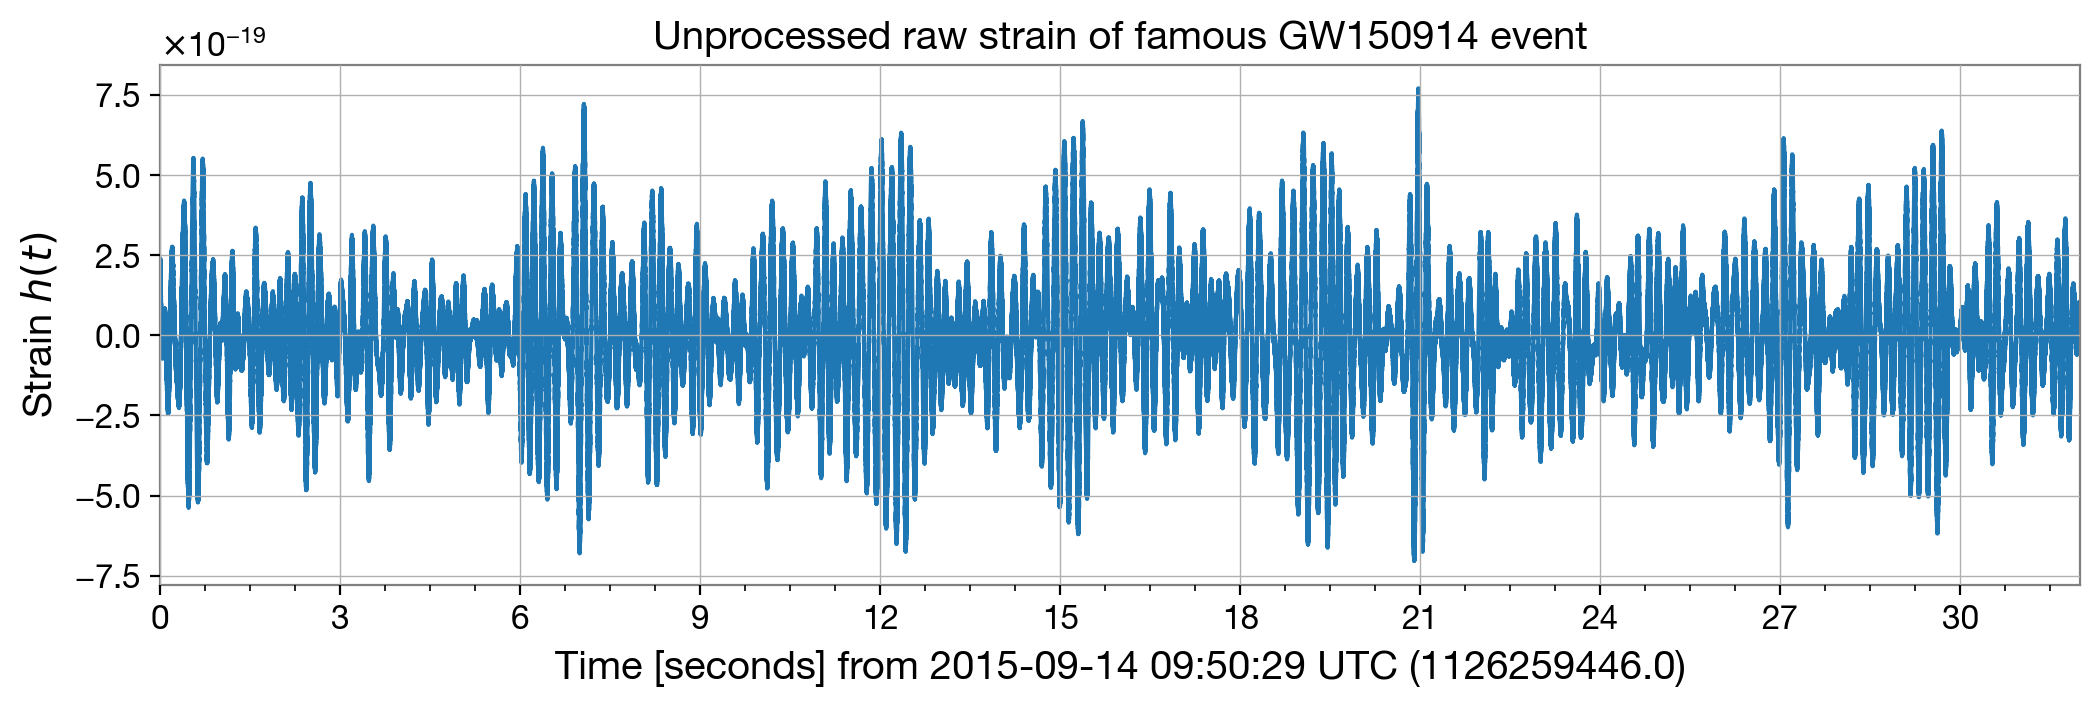

In [6]:
fig1 = strain.plot()
plt.title("Unprocessed raw strain of famous GW150914 event")
plt.ylabel("Strain $h(t)$")



Text(0, 0.5, 'Strain')

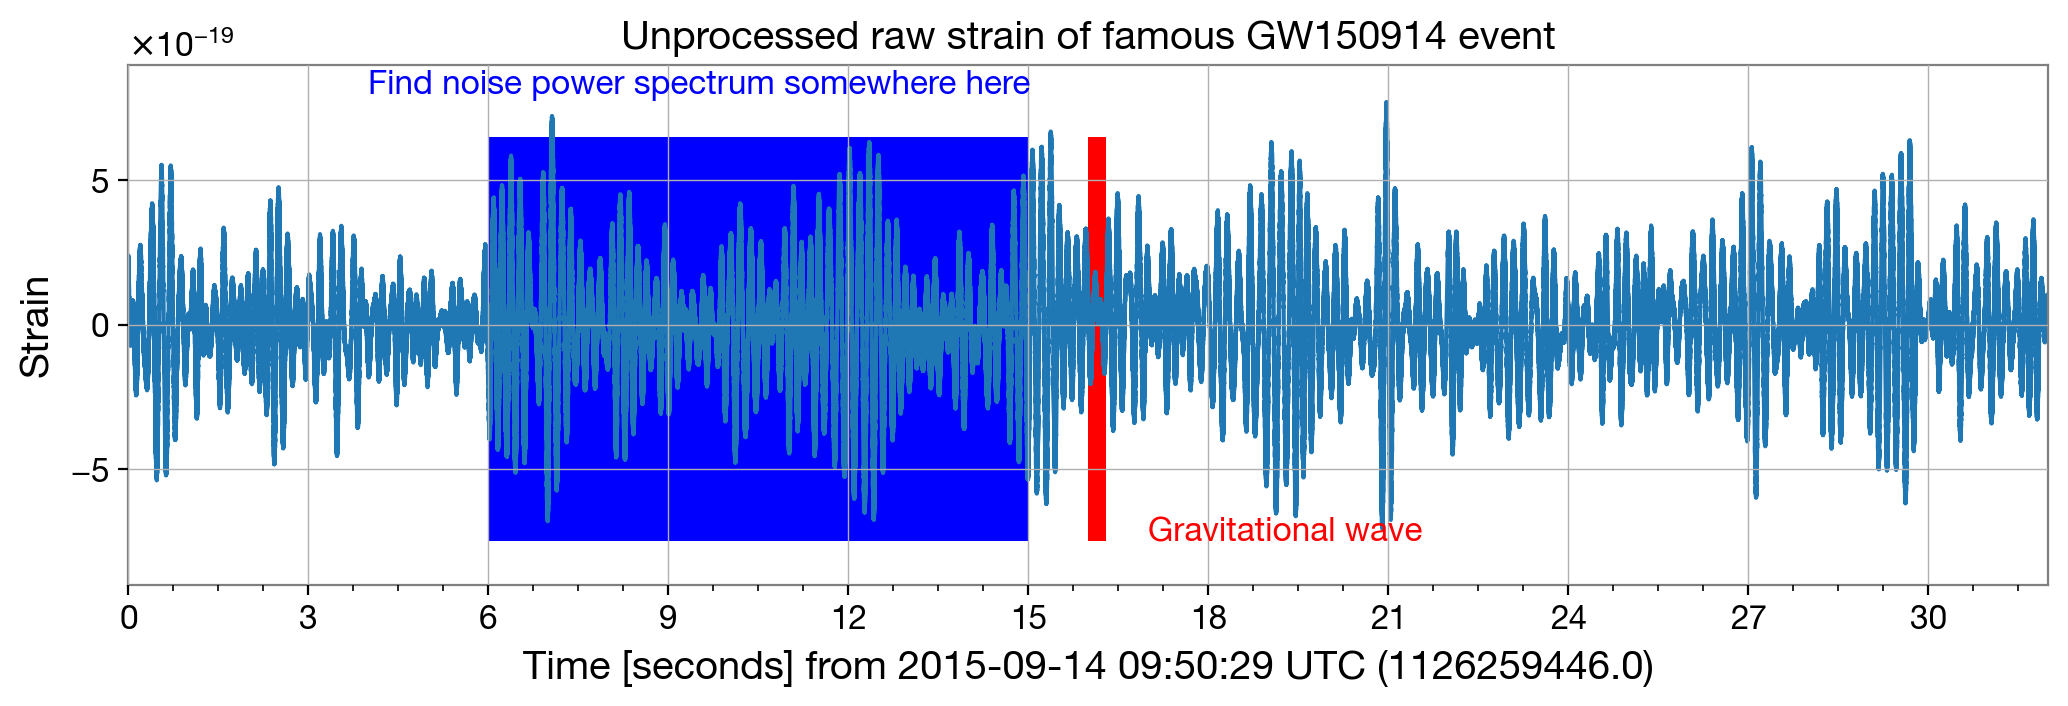

In [7]:
import matplotlib.patches as patches

fig2 = strain.plot()
plt.title("Unprocessed raw strain of famous GW150914 event")
rec1 = patches.Rectangle((center, -7.5e-19), 0.3, 14e-19, fc='r', fill=True)
rec2 = patches.Rectangle((center-10, -7.5e-19), 9, 14e-19, fc='blue', fill=True)
plt.text(center+1, -7.5e-19, "Gravitational wave", color='r')
plt.text(center-12, 8e-19, "Find noise power spectrum somewhere here", color='blue')
plt.gca().add_patch(rec1)
plt.gca().add_patch(rec2)
plt.ylim(-9e-19, 9e-19)
plt.ylabel("Strain")

In [8]:
t = np.array(strain.times) - center
t += np.abs(min(t))
d = np.array(strain.value)

# time_window = (6,15)
time_window = (9,9.5)

idcs = np.where( (time_window[0]<t) & (t<time_window[1]) )
t = t[idcs]
d = d[idcs]

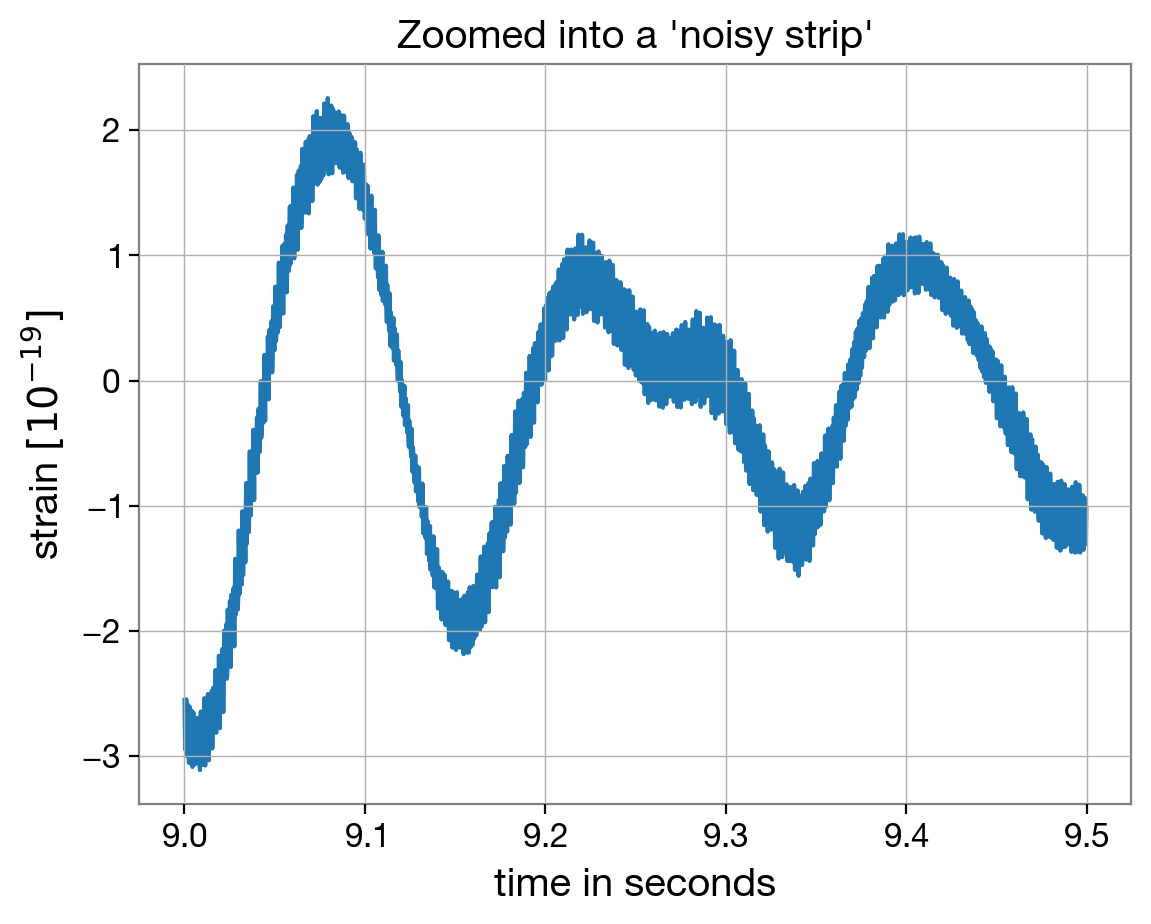

In [9]:
plt.title("Zoomed into a 'noisy strip'")
d *= 1e19
plt.plot(t, d)
plt.xlabel("time in seconds")
plt.ylabel(r"strain $[\mathrm{10^{-19}}]$")
plt.show()

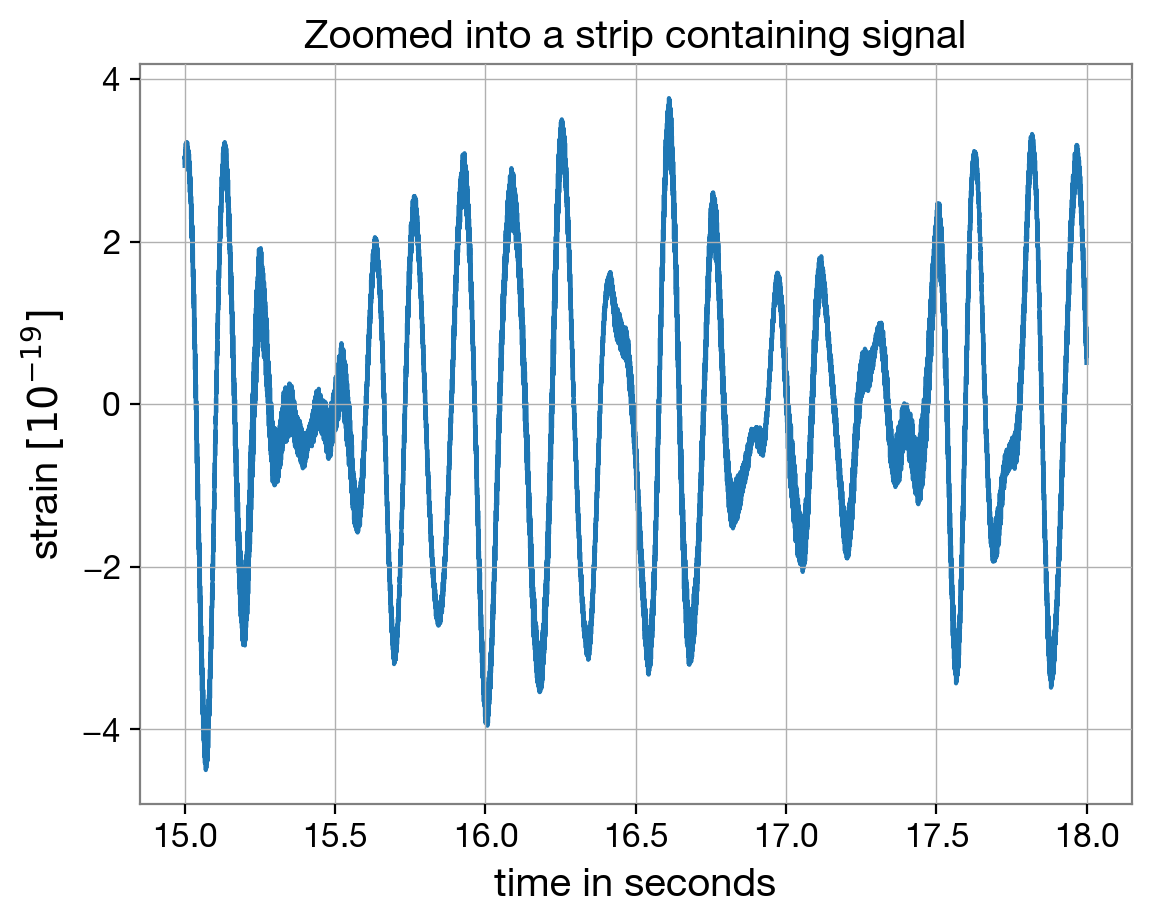

In [10]:
t_tmp = np.array(strain.times) - center
t_tmp += np.abs(min(t))
d_tmp = np.array(strain.value)

time_window_tmp = (15, 18)

idcs_tmp = np.where( (time_window_tmp[0]<t_tmp) & (t_tmp<time_window_tmp[1]) )
t_tmp = t_tmp[idcs_tmp]
d_tmp = d_tmp[idcs_tmp]

plt.title("Zoomed into a strip containing signal")
d_tmp *= 1e19
plt.plot(t_tmp, d_tmp)
plt.xlabel("time in seconds")
plt.ylabel(r"strain $[\mathrm{10^{-19}}]$")
plt.show()

In [11]:
from initial_ideas.utils.minimization_control import *
import numpy as np
import matplotlib.pyplot as plt

def plot_histogram(mean, sigma, n_samples, mode="Lognormal"):
    if mode == "Normal":
        print("Normal distrubution")
        op = ift.NormalTransform(mean=mean, sigma=sigma, key="Normal for Histogram")
    elif mode == "Lognormal":
        op = ift.LognormalTransform(mean=mean, sigma=sigma, key='Lognormal for Histogram', N_copies=0)
    elif mode == "Uniform":
        raise ValueError("Not implemented")
        # print("Uniform distribution")
        # op = ift.StandardUniformTransform(key='Uniform for Histogram', N_copies=0,
        #                               upper_bound=sigma, shift=mean)
    else:
        raise ValueError("Unknown mode")

    op_samples = np.array([op(s).val for s in [ift.from_random(op.domain) for _ in range(n_samples)]])
    label = rf"{mode} with $(\mu, \sigma)=$" + f"$({mean}, {sigma})$" if not (mode=="Uniform") else rf"{mode} in " + r"$\mathrm{[0,1]}$"
    plt.hist(op_samples, bins=200, label=label, histtype='step', facecolor='white', color="black")

    plt.ylabel("Frequency", fontsize=30)
    plt.xlabel(r"Fluctuation parameter", fontsize=30)
    # Right-align the text in the legend
    # special_legend_II()
    # plt.xlim(-0.1, 1.1)
    # if save:
    #     filename = "data_storage/figures/histogram_of_lognormal_distribution"
    #     plt.tight_layout(pad=2)
    #     plt.savefig(filename + ".png", pad_inches=1)
    # if show:
    # plt.show()

class Mask(ift.LinearOperator):
    # Implements a mask response based on a sampling rate
    def __init__(self, domain, sampling_rate_hz, physical_start, physical_end):
        # sampling_rate is typically for ligo 4096Hz or 16384Hz
        # physical_start and end have to be correspondingly in seconds
        # Note that in my implementation, the points are probably not exactly equidistantly spaced (because of the `np.floor` function
        # Also domain.shape[0]-1 is so that the last element is definitely not returned as an index
        self._domain = domain

        physical_length_of_domain = physical_end - physical_start
        num_of_points_to_keep = int(sampling_rate_hz * physical_length_of_domain) + 1  # for the start point ???


        self._target = ift.DomainTuple.make(ift.UnstructuredDomain((num_of_points_to_keep, )))
        self._capability = self.TIMES | self.ADJOINT_TIMES

        self._where_to_keep = np.floor(np.linspace(0, domain.shape[0]-1, num_of_points_to_keep)).astype(int)
        print("Based on sampling rate, length and shape of domain, keeping ", num_of_points_to_keep, " points of continuous signal.")

    def apply(self, x, mode):
        self._check_input(x, mode)
        # x is a field
        if mode == self.ADJOINT_TIMES:
            # zero-pads
            values = np.zeros(self._domain.shape[0])
            values[self._where_to_keep] = x.val
            return ift.Field(self._domain, values)

        elif mode == self.TIMES:
            extract = np.array(x.val)
            idcs = np.array(self._where_to_keep)
            values = extract[idcs]
            return ift.Field(self._target, values)


class ExecuteRGSpaceKL:
    def __init__(self, discrete_time, d, cfm_model_name, n_pix_fac=2, x_fac=2, response="linear mask",
                 sampling_rate_hz=4096, kl_minimizations=10, fluct=(1,1), llslope=(-4,1),
                 gaussian_noise_level=1e-16, out_dir_name="out_index_my_playground", custom_noise_operator=None):
        """
        Parameters
        ----------
        discrete_time : np.array
            The x values at which discrete data occur.
        d : array-like
            Observed data to be analyzed.
        cfm_model_name : str
            What to call the CF ("key").
        n_pix_fac : int, optional
            Factor for determining the number of pixels in the reconstruction grid by multiplying this factor
            onto the number of datapoints. Default is 2.
        x_fac : int, optional
            Expansion factor for the spatial domain, s.t. extended domain is of length x_fac * n_pix_fac * len(d).
             Default is 2.
        response : str, optional
            Type of response model to apply (e.g., 'linear mask'). Default is 'linear mask'.
        sampling_rate_hz : float, optional
            Data sampling rate in Hertz. Default is 4096. Used to determine which points to mask in the signal domain.
        kl_minimizations : int, optional
            Number of KL divergence minimization steps. Default is 10.
        fluct : tuple of float, optional
            Parameters controlling the prior fluctuation amplitude. Default is (1, 1).
        llslope : tuple of float, optional
            Slope range for the log-log power spectrum prior. Default is (-4, 1).
        gaussian_noise_level : float, optional
            Assumed level of additive Gaussian noise. Default is 1e-16.
        out_dir_name : str, optional
            Where to store the output files. Default is "out_index_my_playground".
        """

        x0, xf = (np.min(discrete_time), np.max(discrete_time))

        n_dtps = len(d)
        n_pix = n_pix_fac * n_dtps

        print("Number of datapoints: ", n_dtps)
        print("Constructing RGspace of this number of points: ", n_pix, " (not extended)")

        length_of_domain = xf - x0

        self.out_dir_name = out_dir_name
        self.distances =  length_of_domain / n_pix
        self.domain = ift.RGSpace(shape=(n_pix,), distances=self.distances)
        self.domain_ext = ift.RGSpace(shape=(n_pix*x_fac,), distances=self.distances)
        self.data_space = ift.UnstructuredDomain(shape=(n_dtps, ))
        self.data_field = ift.Field(ift.DomainTuple.make((self.data_space,)),  val=d)

        self.X = ift.FieldZeroPadder(self.domain, new_shape=(n_pix*x_fac, ))

        if response != "linear mask":
            raise ValueError("Not implemented yet")

        mask_op = Mask(ift.DomainTuple.make((self.domain,)), sampling_rate_hz, x0, xf)
        self.R_physical = mask_op

        self.posterior_samples = None
        self.kl_minimizations = kl_minimizations
        self.fluct = fluct
        self.llslope = llslope
        self.cfm_model_name = cfm_model_name
        self.gaussian_noise_level = gaussian_noise_level
        self.prior_parameters = None
        self.n_dtps = n_dtps
        self.n_pix = n_pix

        mdl = self._create_model(fluct, llslope, cfm_model_name)

        self.model, self._cf = (mdl[0], mdl[1])
        self.domain_values = ift.Field(ift.DomainTuple.make(self.domain), np.linspace(x0, xf, n_pix))
        self.domain_values_ext = ift.Field(ift.DomainTuple.make(self.domain_ext), np.linspace(x0, (xf-x0)*x_fac+x0, n_pix*x_fac))
        self.discrete_domain_values = discrete_time

        self._R_full = self.R_physical @ self.X.adjoint @ self.model

        if custom_noise_operator is None:
            self._N = ift.ScalingOperator(self.data_field.domain, gaussian_noise_level, sampling_dtype=np.float64)
        else:
            self._N = custom_noise_operator


    def _create_model(self, fluctuations, llslope, cfm_model_name):
        s_offset = {
            "offset_mean": 0,
            # "offset_std": (1e-20, 1e-21),
            "offset_std": (1e-16, 1e-16),
        }

        s_fluctuations = {
            "target_subdomain": self.domain_ext,
            "fluctuations": (fluctuations[0], fluctuations[1]),
            "loglogavgslope": (llslope[0], llslope[1]),
            # "flexibility": (1., 0.5),
            "flexibility": (1e-16, 1e-16),
            # "asperity": (5., 0.5),
            "asperity": (1e-16, 1e-16)
        }

        s_model = ift.CorrelatedFieldMaker(cfm_model_name)
        s_model.set_amplitude_total_offset(**s_offset)
        s_model.add_fluctuations(**s_fluctuations)

        s_model_meta_class = s_model  # contains information on the power spectra etc
        s_model = s_model.finalize()  # this is solely the operator chauin
        self.prior_parameters = {**s_offset, **s_fluctuations}
        # self.model = s_model
        return s_model, s_model_meta_class

    def _create_gaussian_likelihood(self):
        N = self._N
        R = self._R_full
        likelihood_energy = ift.GaussianEnergy(self.data_field, N.inverse) @ R
        return likelihood_energy

    def _execute_kl(self, lh_energy, kl_minimizations = 10):

        posterior_samples = ift.optimize_kl(
            likelihood_energy=lh_energy,
            total_iterations=kl_minimizations,
            n_samples=kl_sampling_rate,
            kl_minimizer=descent_finder,
            sampling_iteration_controller=ic_sampling_lin,
            nonlinear_sampling_minimizer=geoVI_sampling_minimizer,
            output_directory=self.out_dir_name,
            return_final_position=False,
            resume=True)

        print("Posterior samples saved. Analyze via class.plot_posterior()")
        self.posterior_samples = posterior_samples

    def run(self):
        print("Creating Gaussian likelihood...")
        lh_energy = self._create_gaussian_likelihood()
        print("Created Gaussian likelihood, running KL.")
        self._execute_kl(lh_energy, kl_minimizations=self.kl_minimizations)

    def plot_posterior(self, plot_signal_space=False, plot_with_variance=False):
        if self.posterior_samples is None:
            raise ValueError("Execute `run` first")

        s_m, s_v = self.posterior_samples.sample_stat(self.model)

        if plot_signal_space:
            plt.plot(self.discrete_domain_values, self.data_field.val, "r-", label="Data")  # DATA
            plt.plot(self.domain_values.val, self.X.adjoint(s_m).val, "b-", label="Posterior mean")
            if plot_with_variance:
                plt.errorbar(self.domain_values.val, self.X.adjoint(s_m).val, yerr=np.sqrt(self.X.adjoint(s_v).val))

        else:
            res_sq = (self.data_field.val - self.R_physical(self.X.adjoint(s_m)).val)**2
            chi_sq = np.sum(res_sq) / (self.gaussian_noise_level * self.n_dtps)
            print("chi_sq reduced in dataspace: ", chi_sq)
            plt.plot(self.discrete_domain_values, self.data_field.val, "r-", label="Data")  # DATA
            plt.plot(self.discrete_domain_values, self.R_physical(self.X.adjoint(s_m)).val, "b-", label="Data from posterior mean")

        plt.legend()
        plt.xlabel('Time (s)')
        plt.ylabel('Strain $[10^{-19}]$')
        plt.title("Reconstruction")
        plt.show()

    def plot_prior_samples(self, num=5, plot_in_data_space=False, apply_adjoint_zp = True):
        plt.ylabel("strain $[10^{-19}]$")
        if not plot_in_data_space:
            op = self.model
            samples = list(op(ift.from_random(op.domain)) for _ in range(num))
            if apply_adjoint_zp:
                plt.xlabel("time in seconds")
                y = [self.X.adjoint(sl) for sl in samples]
                [plt.plot(self.domain_values.val, sl.val) for sl in y]
                return y
            else:
                plt.xlabel("time in seconds (extended domain)")
                [plt.plot(self.domain_values_ext.val, sl.val) for sl in samples]
                return samples
        else:
            op = self.R_physical @ self.X.adjoint @ self.model
            samples = list(op(ift.from_random(op.domain)) for _ in range(num))
            for sample in samples:
                plt.plot(self.discrete_domain_values, sample.val)
            return samples

    def plot_data_realization(self):
        data_realization = self._R_full(ift.from_random(self.model.domain)) + self._N.draw_sample()
        plt.plot(self.discrete_domain_values, data_realization.val)

    def plot_prior_fluctuations_distribution(self):
        plot_histogram(mean=self.fluct[0], sigma=self.fluct[1], n_samples=1000, mode="Lognormal")

    def plot_pow_spec(self):
        a = self._cf.amplitude
        harmonic_samples = list(self.posterior_samples.local_iterator())
        # print("here: ",harmonic_samples[0].domain, harmonic_samples[0].val)
        spectrum_realizations = [a.force(sl) for sl in harmonic_samples]
        # print("here: ", spectrum_realizations[0].val)
        # print("here: ", spectrum_realizations[0].val[:3])
        # print("here: ", spectrum_realizations[0].val[-3:])

        arrs = [sp.val for sp in spectrum_realizations]
        mean_pow_spec = np.mean(arrs, axis=0)

        all_k_domains = [spec.domain[0].k_lengths for spec in spectrum_realizations]
        k_domain_lengths = all_k_domains[0]
        # print("Are all k-domains the same?", np.all(all_k_domains == all_k_domains[0]))

        for spec in spectrum_realizations:
            plt.plot(k_domain_lengths, spec.val, color="black", alpha=0.3)

        plt.plot(k_domain_lengths, mean_pow_spec, label="Posterior mean pow spec", lw=5)
        plt.loglog()

        plt.xlabel(r"Frequency $\omega$")
        plt.ylabel(r"$P_n(\omega)$")

        plt.legend()
        plt.ylim(1e-7,10)
        return k_domain_lengths, mean_pow_spec

    def get_mean_pow_spec(self):
        raise NotImplementedError

Text(0, 0.5, 'strain $[\\mathrm{10^{-19}}]$')

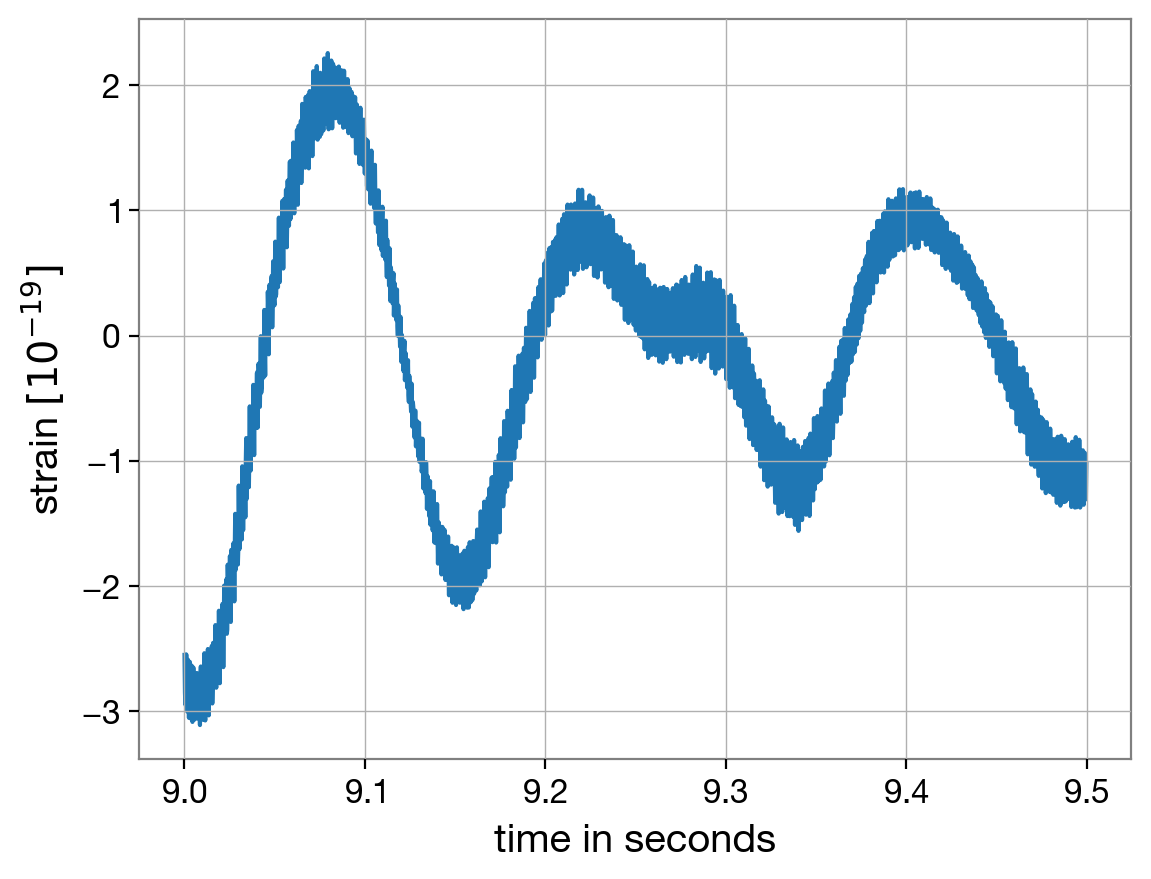

In [12]:
# to remind
plt.plot(t, d)
plt.xlabel("time in seconds")
plt.ylabel(r"strain $[\mathrm{10^{-19}}]$")

In [13]:

inference_scheme = ExecuteRGSpaceKL(
    discrete_time=t,
    d=d,
    cfm_model_name="noise cfm ",
    kl_minimizations=5,
    fluct=(2, 1),
    llslope=(-2, 1),
    gaussian_noise_level=0.1
)

Offset amplitude: 8.28E-17 ± 5.69E-17
Total fluctuation amplitude: 1.99E+00 ± 1.05E+00


Number of datapoints:  2047
Constructing RGspace of this number of points:  4094  (not extended)
Based on sampling rate, length and shape of domain, keeping  2047  points of continuous signal.


In [14]:
# inference_scheme.plot_prior_fluctuations_distribution()
# inference_scheme.plot_prior_samples(1, plot_in_data_space=True)
# inference_scheme.plot_data_realization()

In [15]:
inference_scheme.run()

Creating Gaussian likelihood...
Created Gaussian likelihood, running KL.
Posterior samples saved. Analyze via class.plot_posterior()


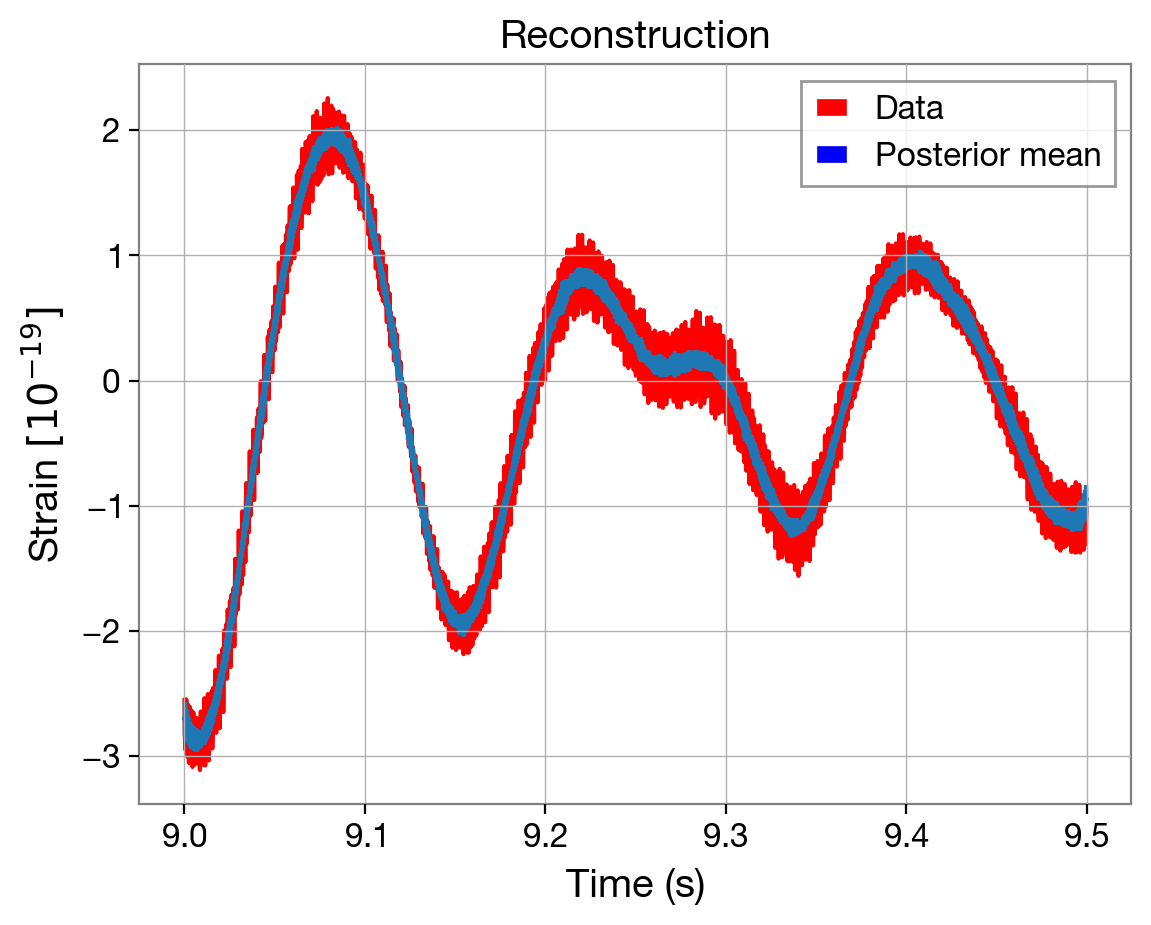

In [16]:
inference_scheme.plot_posterior(plot_signal_space=True, plot_with_variance=True)



from prior choices 

	 {'offset_mean': 0, 'offset_std': (1e-16, 1e-16), 'target_subdomain': RGSpace(shape=(8188,), distances=(0.00012201067873717636,), harmonic=False), 'fluctuations': (2, 1), 'loglogavgslope': (-2, 1), 'flexibility': (1e-16, 1e-16), 'asperity': (1e-16, 1e-16)} 

 and latent parameters

	 {'noise cfm asperity': array(1.35299738e-06), 'noise cfm flexibility': array(5.6411814e-06), 'noise cfm fluctuations': array(0.6686507), 'noise cfm loglogavgslope': array(-0.91417194), 'noise cfm spectrum': array([[-8.21708120e-06, -1.95263151e-07, -3.37966339e-06, ...,
         2.99705058e-07,  1.80795594e-06, -1.04777510e-06],
       [-2.64326401e-06,  6.72369133e-06, -7.54272179e-07, ...,
         6.27560151e-06,  1.79748115e-06,  5.32170821e-06]]), 'noise cfm xi': array([-1.44291198e-06, -3.36605585e-01, -4.74985083e-01, ...,
       -6.96056891e-01,  1.23181806e+00, -3.26582132e-01]), 'noise cfm zeromode': array(-3.01562826e-06)}  

inferred following model parameters:

res:  {'

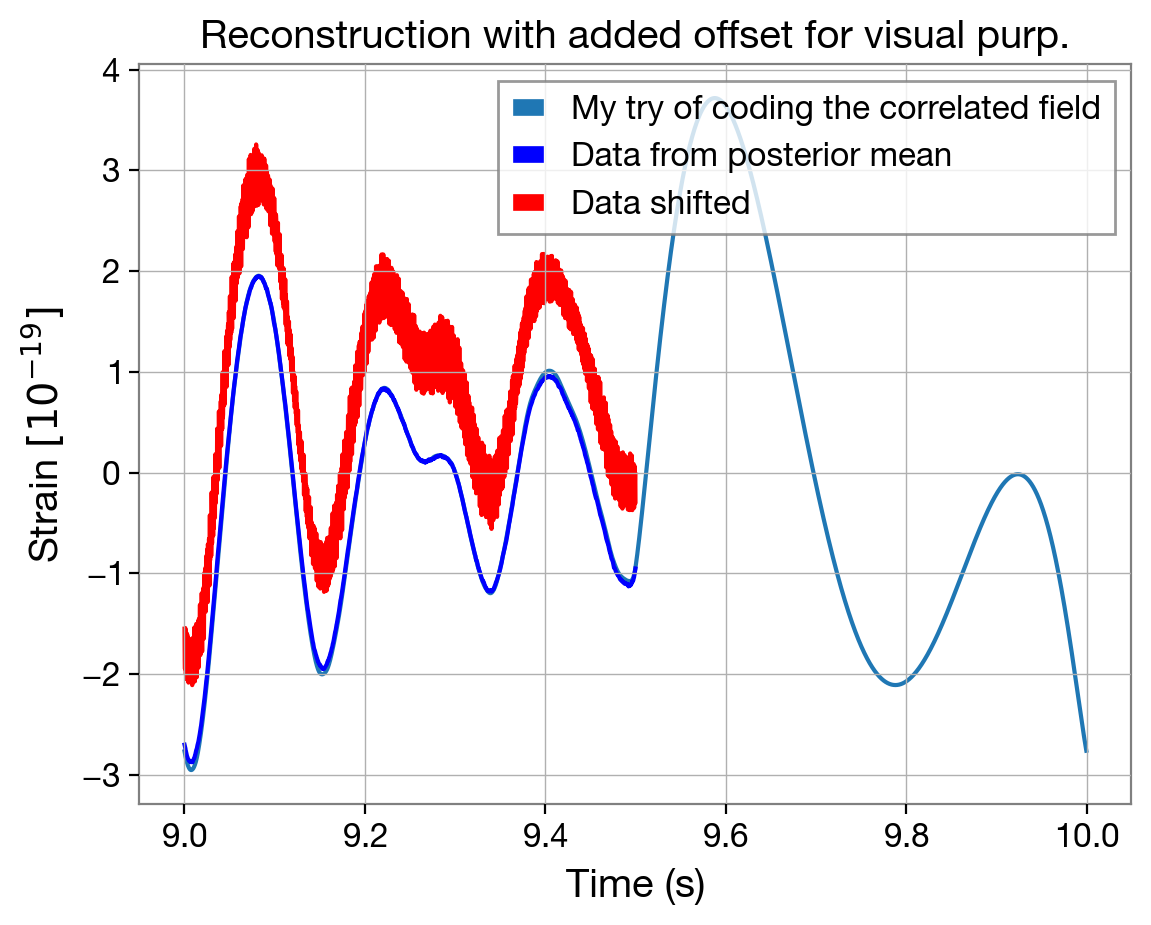

In [17]:

def lognormal_moments(mean, sigma):
    """Calculates the parameters for a normal distribution `n(x)`
    such that `exp(n)(x)` has the mean and standard deviation given.

    Used in :func:`~nifty8.normal_operators.LognormalTransform`."""
    if not np.all(mean > 0):
        raise ValueError("mean must be greater 0; got {!r}".format(mean))
    if not np.all(sigma > 0):
        raise ValueError("sig must be greater 0; got {!r}".format(sigma))

    logsigma = np.sqrt(np.log1p((sigma / mean)**2))
    logmean = np.log(mean) - logsigma**2 / 2
    return logmean, logsigma

def calculate_model_parameters_from_latent_sample(inf_scheme:ExecuteRGSpaceKL, l_sl=None):
    # if l_sl is None, the mean latent sample from inference scheme is gotten
    prior_choices = inf_scheme.prior_parameters

    if l_sl is None:
        l_sl = inf_scheme.posterior_samples.sample_stat()[0]

    vals = l_sl.val

    res = {}
    val_keys = vals.keys()

    mode = {
        "fluctuations": "lognormal",
        "loglogavgslope": "normal",
        "flexibility": "lognormal",
        "asperity": "lognormal"
    }

    functions = {
        "lognormal": np.exp,
        "normal": lambda arg: arg, # unity
    }

    for key in prior_choices.keys():
        for k in val_keys:
            if key in k:
                res[key] = vals[k]

    for param in res.keys():
        xi_value = res[param]
        prior = prior_choices[param]

        if mode[param] == "normal":
            mean = prior[0]
            sig = prior[1]
        elif mode[param] == "lognormal":
            mean, sig = lognormal_moments(prior[0], prior[1])
        else:
            raise ValueError("unknown mode")

        res[param] = functions[mode[param]](xi_value*sig + mean)

    print("\n\nfrom prior choices \n\n\t", prior_choices, "\n\n and latent parameters\n\n\t", l_sl.val, " \n\ninferred following model parameters:")
    print("\nres: ", res, "\n\n")
    return res

s_mean, s_var = inference_scheme.posterior_samples.sample_stat(inference_scheme.model)

s_mean_latent = inference_scheme.posterior_samples.sample_stat()[0]
model_parameters = calculate_model_parameters_from_latent_sample(inference_scheme, s_mean_latent)
my_custom_harmonic_xi_s_from_first_run = s_mean_latent.val["noise cfm xi"]  # the mean harmonic xi_s

test = ift.VerySimpleCorrelatedField(inference_scheme.domain_ext, fluctuations=model_parameters["fluctuations"], loglogavgslope=model_parameters["loglogavgslope"], override_with_exact_values=True, custom_harmonic_xi_s=my_custom_harmonic_xi_s_from_first_run)
plt.plot(inference_scheme.domain_values_ext.val, test.val, label="My try of coding the correlated field")

plt.plot(inference_scheme.R_physical(inference_scheme.domain_values).val, inference_scheme.R_physical(inference_scheme.X.adjoint(s_mean)).val, "b-", label="Data from posterior mean")
plt.plot(inference_scheme.discrete_domain_values, inference_scheme.data_field.val+1, "r-", label="Data shifted")  # DATA

plt.legend(loc="upper right")
plt.xlabel('Time (s)')
plt.ylabel('Strain $[10^{-19}]$')
plt.title("Reconstruction with added offset for visual purp.")
plt.show()

fluctuations approximately:  2.177673242779381
k lengths  [0.00000000e+00 1.00097752e+00 2.00195503e+00 ... 4.09600000e+03
 4.09700098e+03 4.09800196e+03]
mean_pow_spec  [1.45410364e-16 1.72199426e+00 5.92171088e-01 ... 2.32270641e-05
 2.32204331e-05 2.32138056e-05]


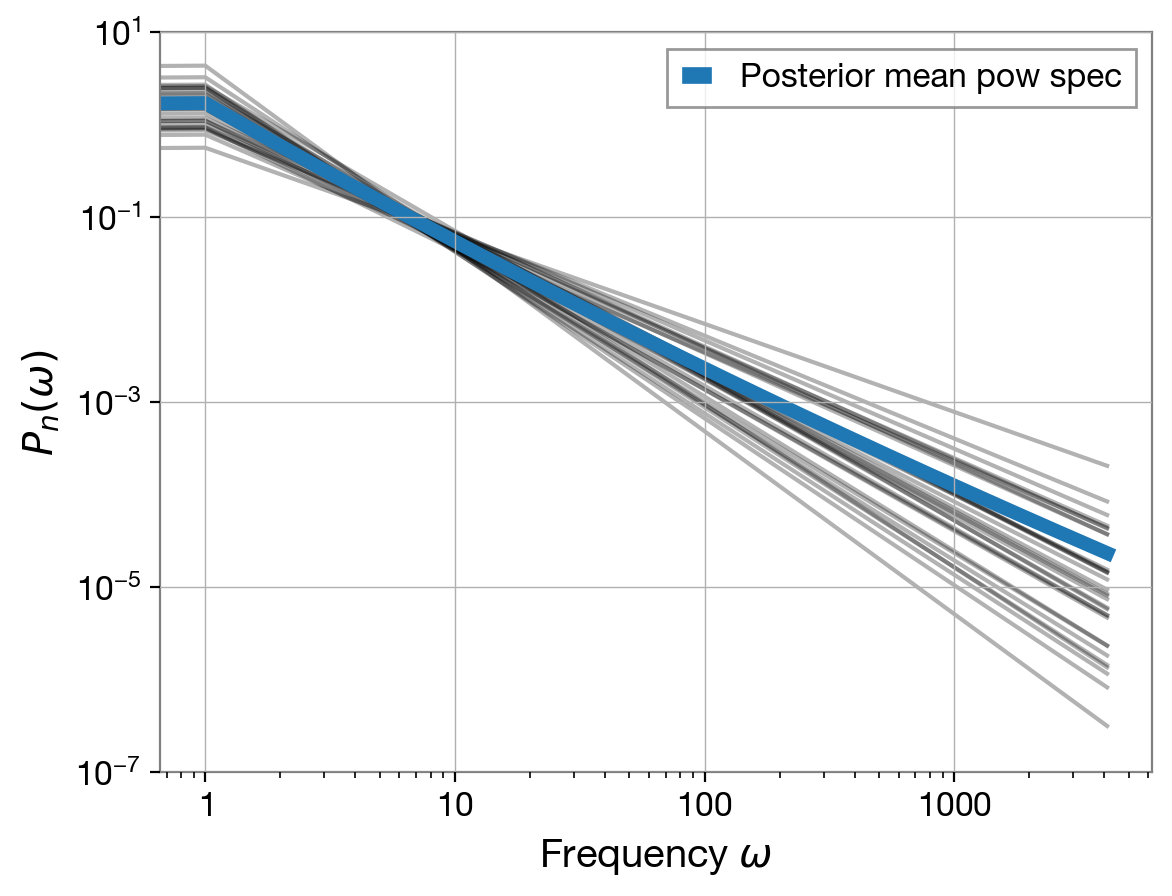

In [18]:
# now let us extract the noise covariance operator in matrix representation
k_lengths, mean_pow_spec = inference_scheme.plot_pow_spec()
print("fluctuations approximately: ", np.sqrt(np.trapz(mean_pow_spec, k_lengths)))
print("k lengths ", k_lengths)
print("mean_pow_spec ", mean_pow_spec)

## Questions

Now I want to use this power spectrum to infer the signal in another strip of data.

- ~~How do I handle the reconstruction uncertainty of this power spectrum?~~  <span style="color:green">Later, you will either way learn the power spectrum in the signal-containing data-strip </span>
- ~~Does this noise power spectrum differ from those in other short strips of data~~  <span style="color:green"> Not if you reduce the parameters of the model to just two (fluct and loglogslope) </span>
- I assumed a noise level of 0.2 *in* the noise itself. Makes sense?
- The chi square values -> 0. Desired?


In [19]:
class RunAnalysisOnDifferentDataStrips:
    def __init__(self, strain_time_series):
        self.strain = strain_time_series
        self.time_windows = []
        self.inference_schemes = []

    def run(self, window = (9,9.5)):
        t = np.array(strain.times) - center
        t += np.abs(min(t))
        d = np.array(strain.value)

        idcs = np.where( (window[0]<t) & (t<window[1]) )
        t = t[idcs]
        d = d[idcs]

        d *= 1e19

        sub_inference_scheme = ExecuteRGSpaceKL(
            discrete_time=t,
            d=d,
            cfm_model_name=f"noise cfm data window {window} ",
            kl_minimizations=5,
            fluct=(2, 1),
            llslope=(-2,1),
            gaussian_noise_level=0.1,
            out_dir_name=f"output_{window}"
        )

        sub_inference_scheme.run()
        self.inference_schemes.append(sub_inference_scheme)
        self.time_windows.append(window)


In [20]:
multiple_inference_schemes = RunAnalysisOnDifferentDataStrips(strain)
tm_windows = [
    (9, 9.5),
    (10, 10.5),
    (13, 13.5),
    (14, 14.5)
]
for window in tm_windows:
    multiple_inference_schemes.run(window=window)

Offset amplitude: 8.62E-17 ± 7.29E-17
Total fluctuation amplitude: 2.23E+00 ± 1.10E+00
Offset amplitude: 9.05E-17 ± 7.71E-17
Total fluctuation amplitude: 1.92E+00 ± 8.45E-01
Offset amplitude: 1.05E-16 ± 1.11E-16
Total fluctuation amplitude: 1.86E+00 ± 9.20E-01
Offset amplitude: 8.75E-17 ± 9.89E-17
Total fluctuation amplitude: 2.21E+00 ± 1.31E+00


Number of datapoints:  2047
Constructing RGspace of this number of points:  4094  (not extended)
Based on sampling rate, length and shape of domain, keeping  2047  points of continuous signal.
Creating Gaussian likelihood...
Created Gaussian likelihood, running KL.
Posterior samples saved. Analyze via class.plot_posterior()
Number of datapoints:  2047
Constructing RGspace of this number of points:  4094  (not extended)
Based on sampling rate, length and shape of domain, keeping  2047  points of continuous signal.
Creating Gaussian likelihood...
Created Gaussian likelihood, running KL.
Posterior samples saved. Analyze via class.plot_posterior()
Number of datapoints:  2047
Constructing RGspace of this number of points:  4094  (not extended)
Based on sampling rate, length and shape of domain, keeping  2047  points of continuous signal.
Creating Gaussian likelihood...
Created Gaussian likelihood, running KL.
Posterior samples saved. Analyze via class.plot_posterior()
Number of datapoints: 

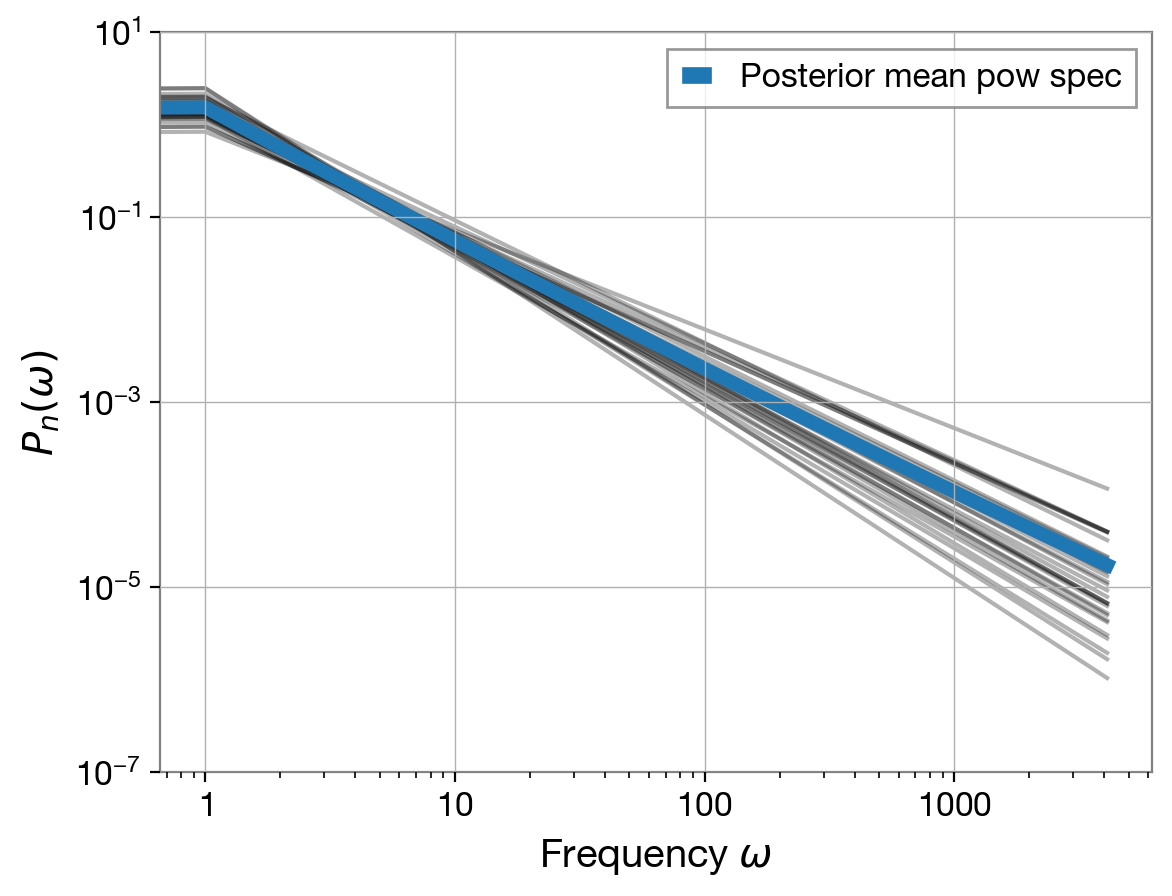

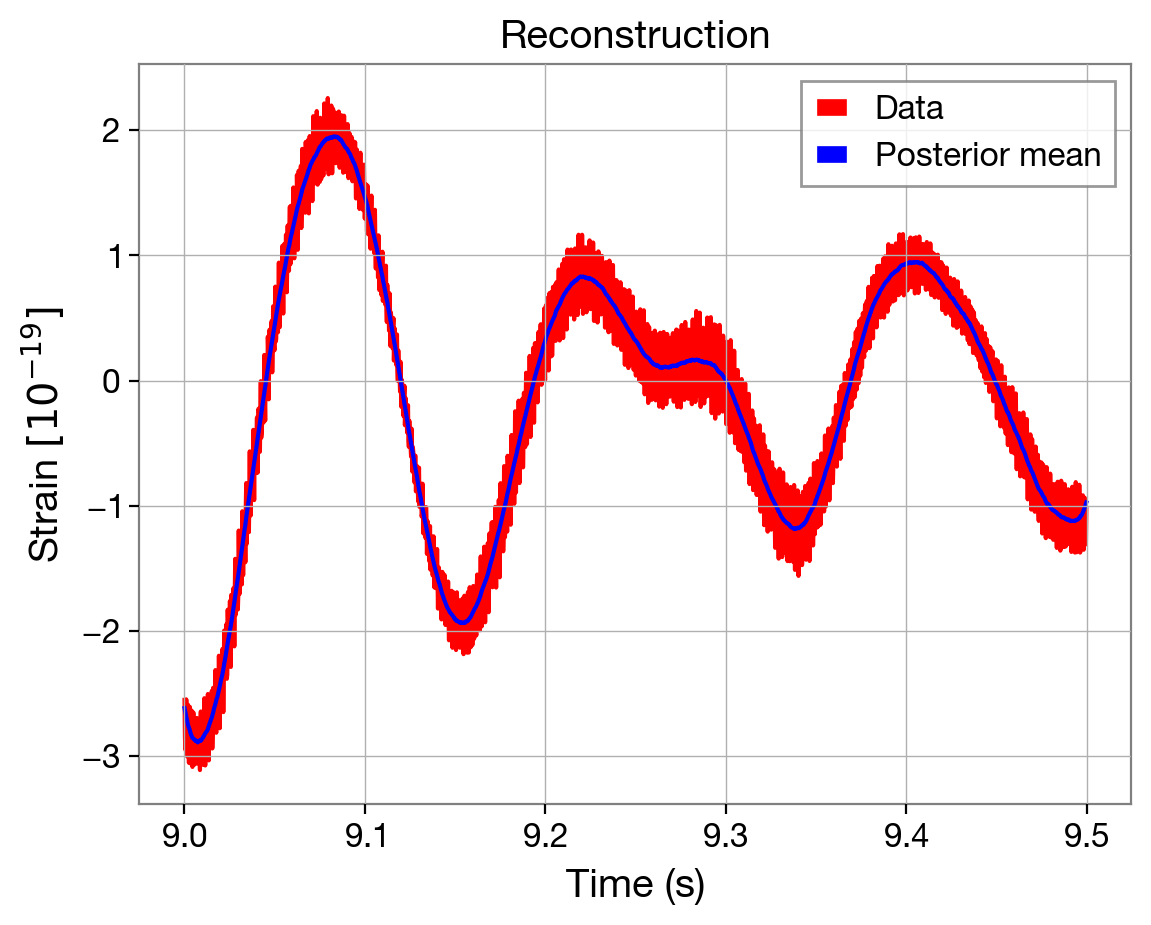

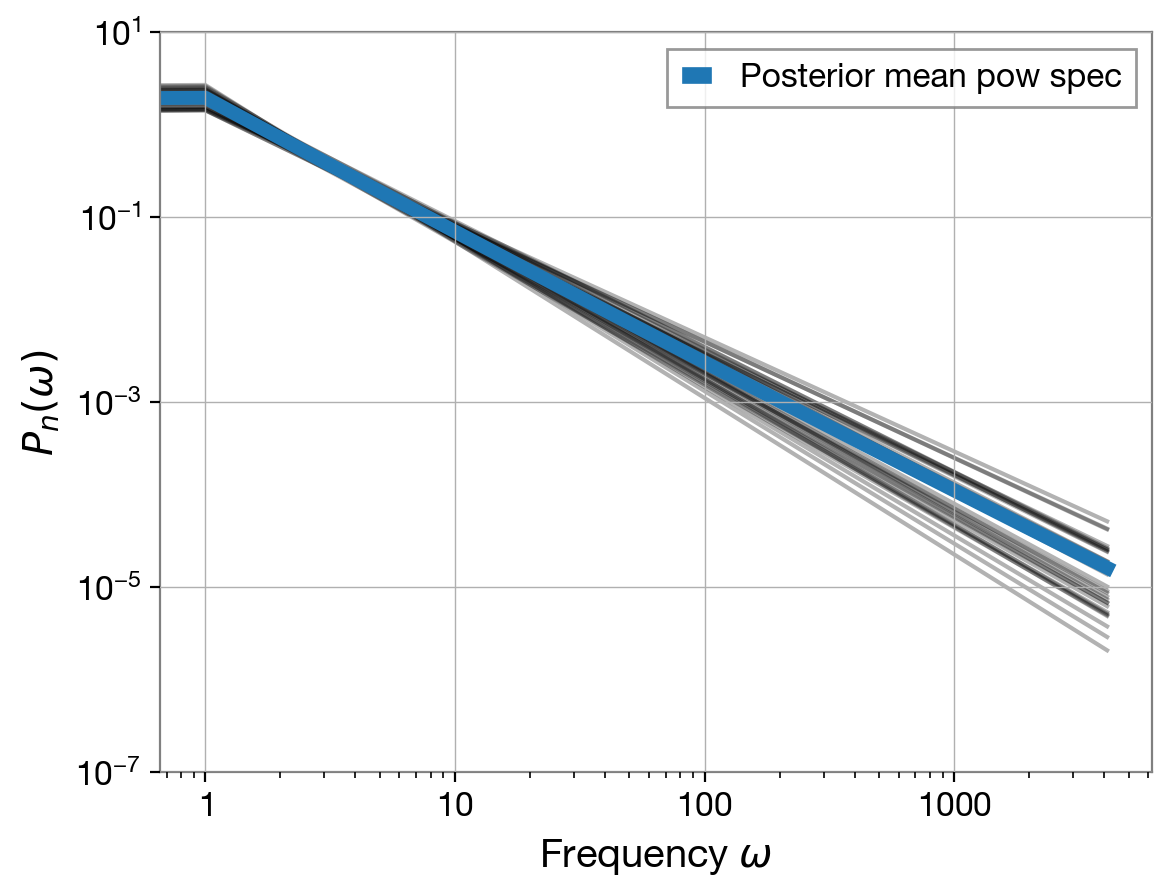

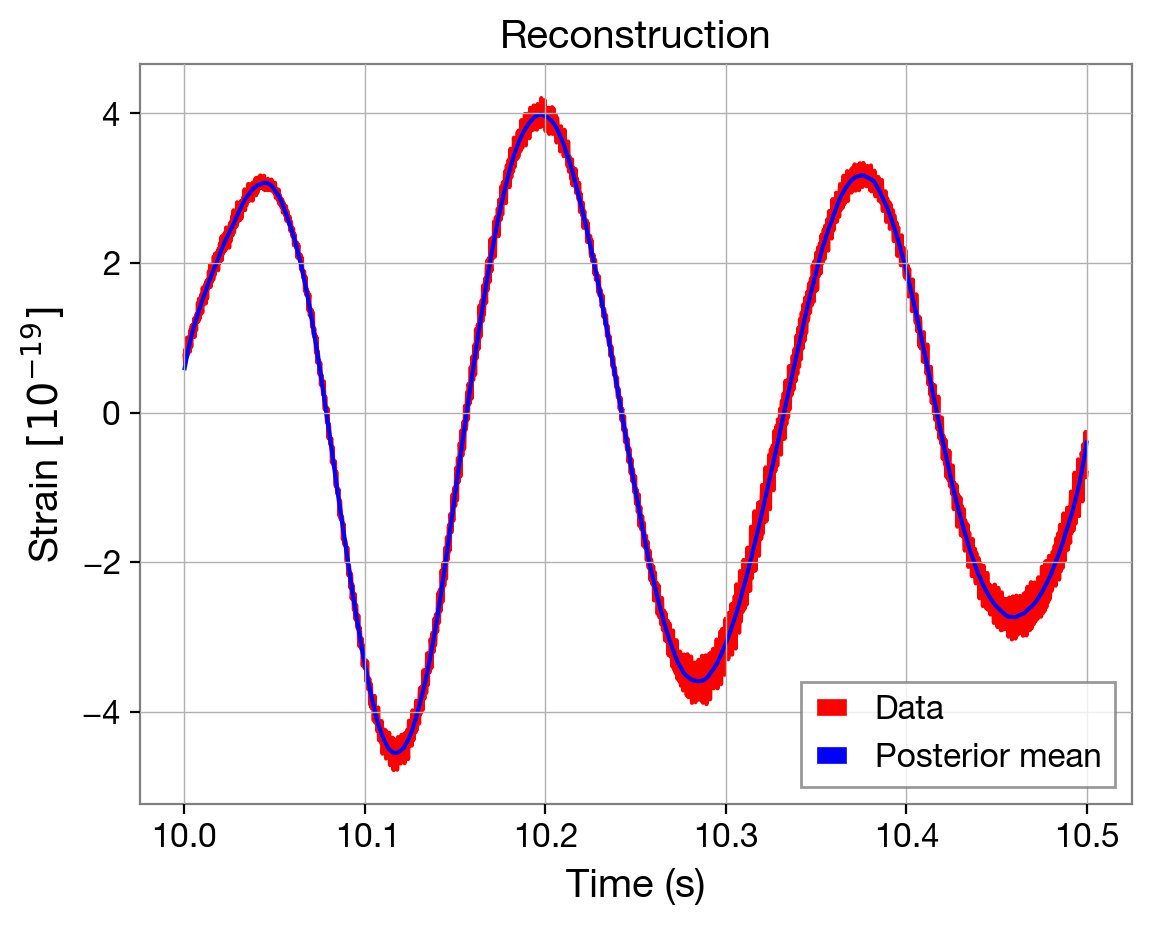

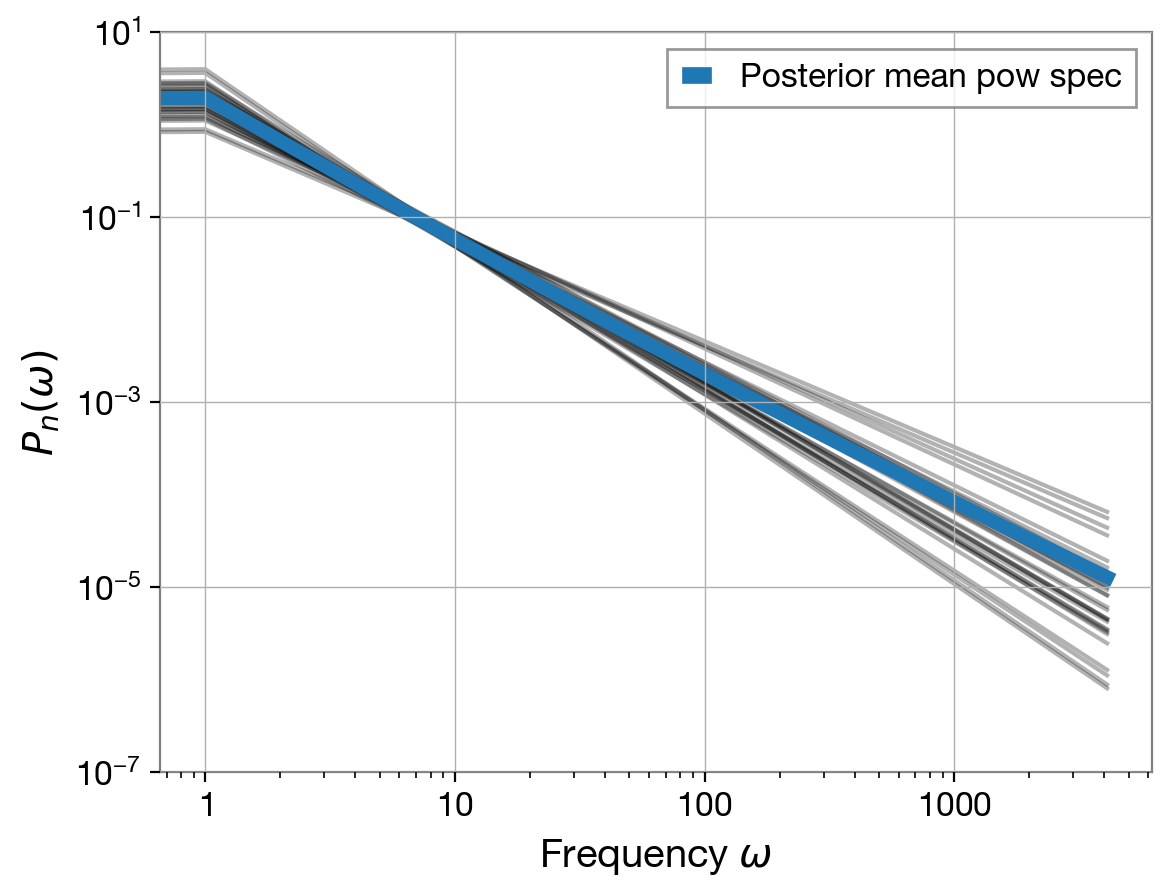

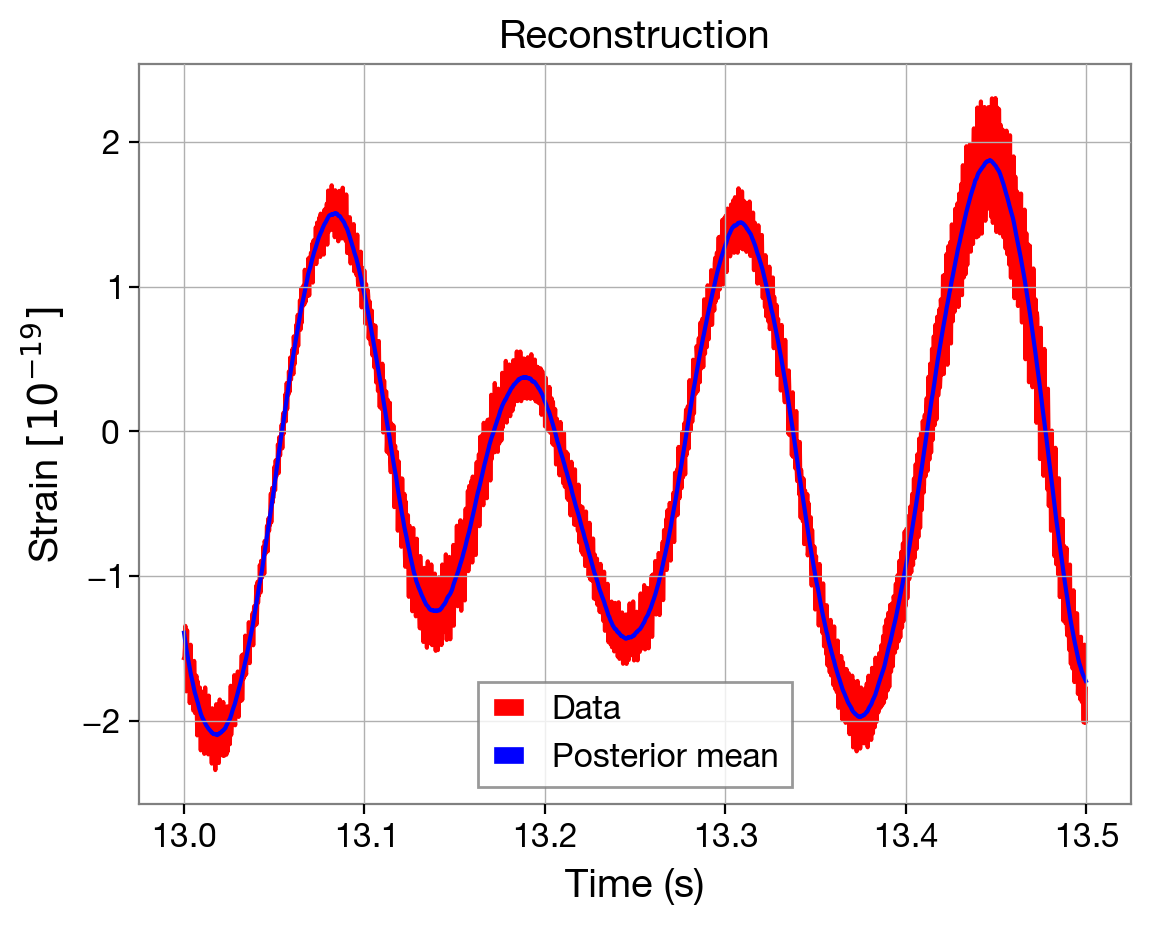

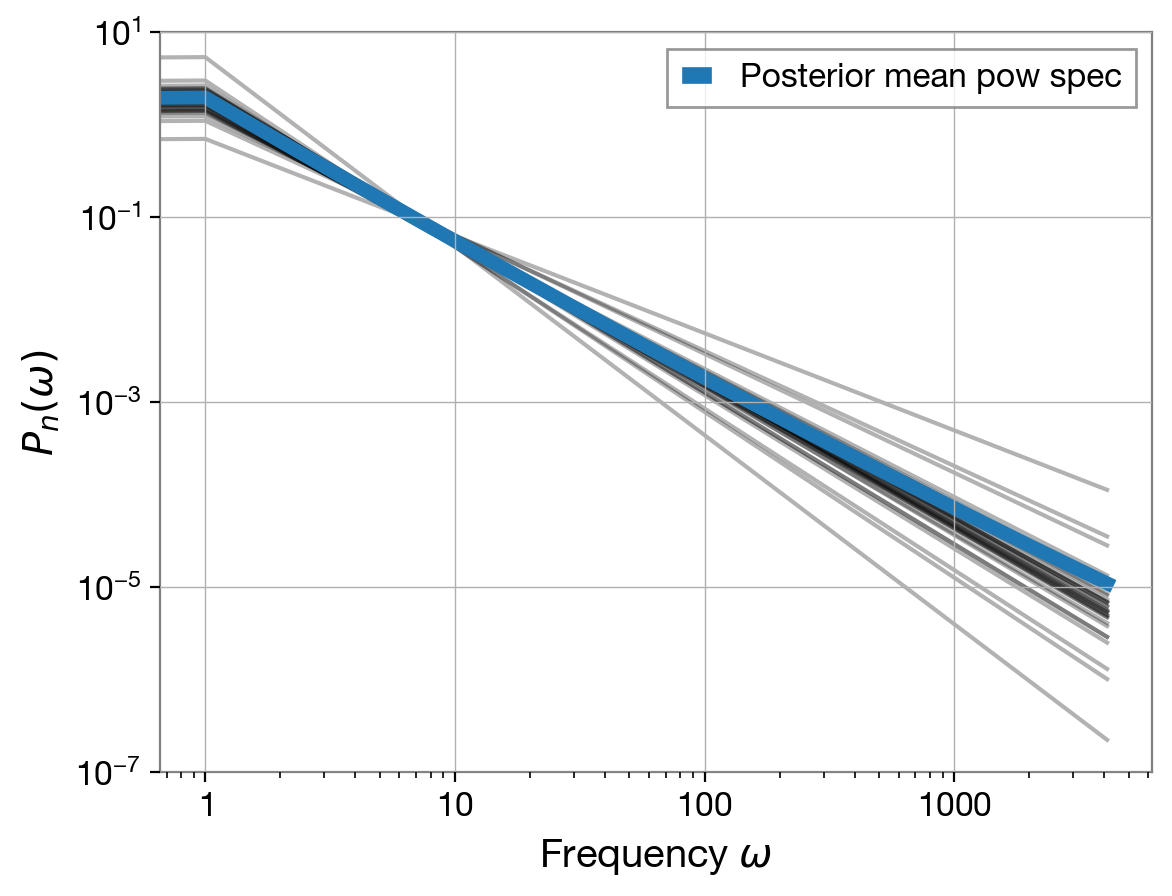

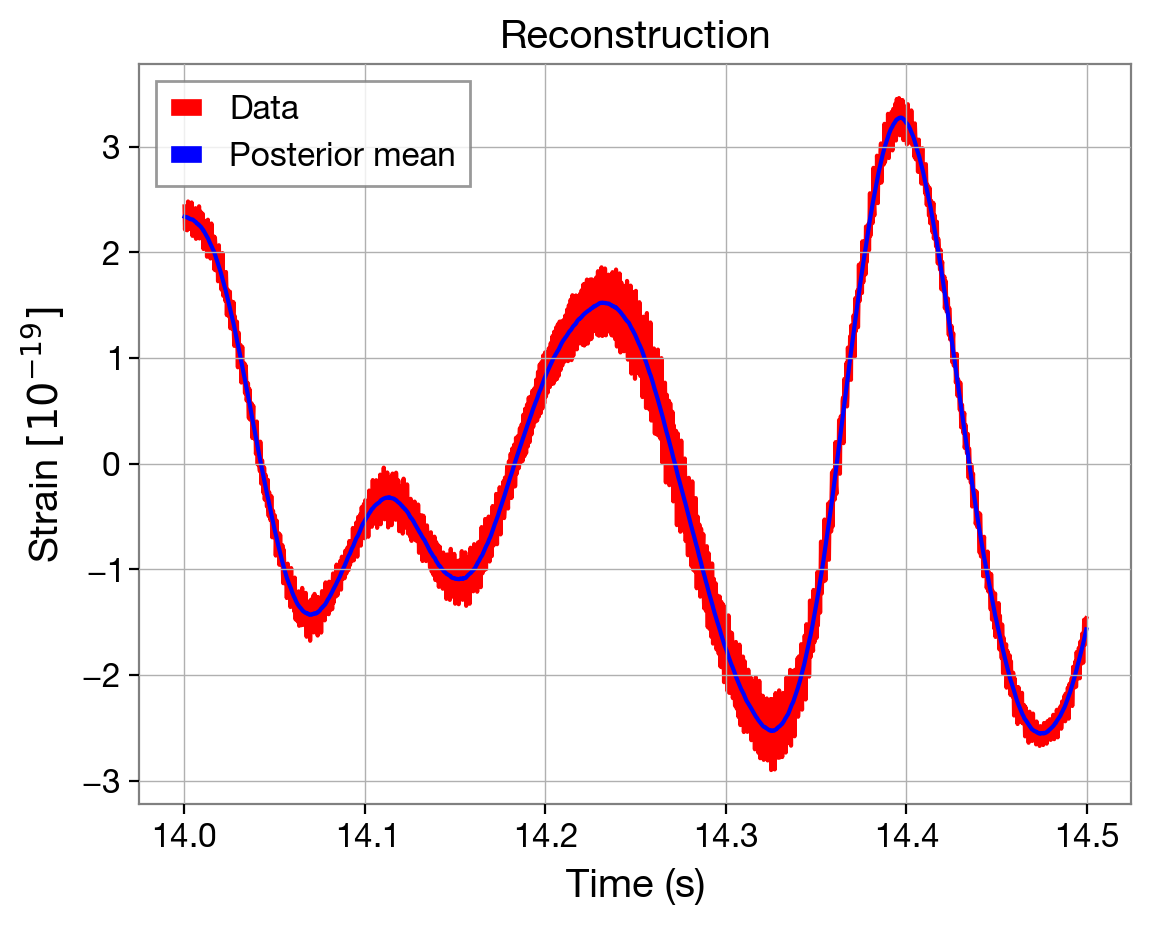

Mean slopes:  [-1.320160444444967, -1.3807110223699506, -1.3684217562115186, -1.3808834990854582]
Mean flucts:  [1.9294976387639506, 2.142511069445458, 2.0054436435289205, 1.9706502005621074]
Ensemble average of slopes:  -1.3625441805279737
Ensemble average of flucts:  2.012025638075109


In [21]:
from scipy.optimize import curve_fit

def linear(x,a,b):
    return x*a+b

def find_mean_slope(mean_pow_spec, k_lengths):
    popt = curve_fit(linear, k_lengths, mean_pow_spec)[0]
    return popt[0]

def find_mean_fluctuations(mean_pow_spec, k_lengths):
    return np.sqrt(np.trapz(mean_pow_spec, k_lengths))

mean_slopes = []
mean_flucts = []

for inference_subscheme in multiple_inference_schemes.inference_schemes:
    k_domain_lengths, mean_pow_spec = inference_subscheme.plot_pow_spec()
    mean_slopes.append(find_mean_slope(np.log10(mean_pow_spec[1:]), np.log10(k_domain_lengths[1:])))
    mean_flucts.append(find_mean_fluctuations(mean_pow_spec[1:], k_domain_lengths[1:]))
    plt.show()
    inference_subscheme.plot_posterior(plot_signal_space=True)
    plt.show()

print("Mean slopes: ", mean_slopes)
print("Mean flucts: ", mean_flucts)

print("Ensemble average of slopes: ", np.mean(mean_slopes))
print("Ensemble average of flucts: ", np.mean(mean_flucts))


Let's build a function to extract the posterior noise covariance (in the data domain i.e. of length len(d) x len(d)) from the posterior power spectrum

In [22]:

HT = ift.HartleyOperator(domain=inference_scheme.domain_ext)
harmonic_space = HT.target

pow_spec_domain = ift.PowerSpace(harmonic_partner=harmonic_space[0])
print(pow_spec_domain)
pow_spec = ift.Field(ift.DomainTuple.make((pow_spec_domain,)), val=mean_pow_spec)
N_fourier = ift.create_power_operator(domain=harmonic_space, power_spectrum=pow_spec, sampling_dtype=np.float64)  # operator in fourier space with the power spectrum as  its diagonal
N_fourier_sqrt = ift.create_power_operator(domain=harmonic_space, power_spectrum=np.sqrt(pow_spec), sampling_dtype=np.float64)  # operator in fourier space with the power spectrum as  its diagonal
N_real_sqrt = ift.SandwichOperator.make(bun=HT, cheese=N_fourier_sqrt, sampling_dtype=np.float64)
N_real = ift.SandwichOperator.make(bun=HT, cheese=N_fourier, sampling_dtype=np.float64)

PowerSpace(harmonic_partner=RGSpace(shape=(8188,), distances=(1.0009775171065494,), harmonic=True), binbounds=None)


(8188,)
nifty8.Field instance
- domain      = DomainTuple, len: 1
* RGSpace(shape=(8188,), distances=(0.00012201067873717636,), harmonic=False)
- val         = array([9.00024414, 9.00036617, 9.00048819, ..., 9.99902353,
       9.99914555, 9.99926758])
- nbytes      = 0.066 MB


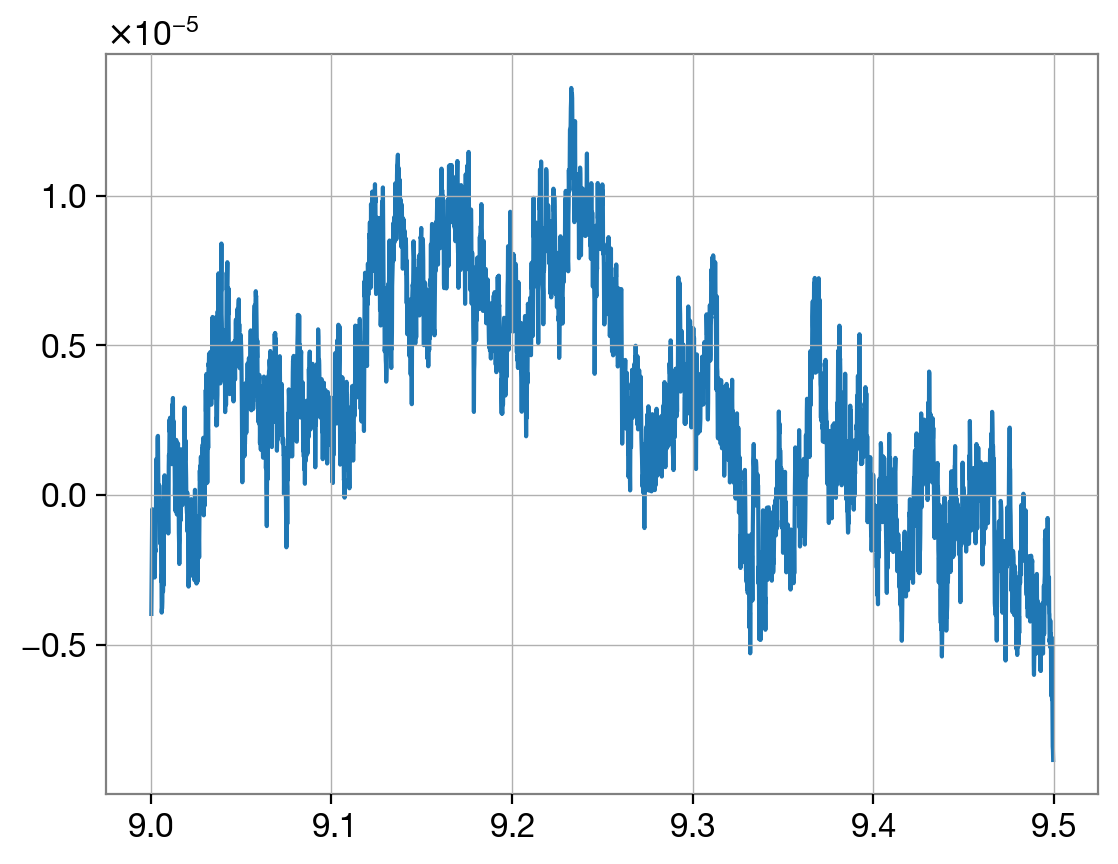

In [23]:
print(N_real_sqrt.domain[0].shape)
xi_n = ift.Field(N_real_sqrt.domain, val=np.random.normal(loc=0, scale=1, size=N_real_sqrt.domain[0].shape))
noise_field_sample = N_real_sqrt(xi_n)
print(inference_scheme.domain_values_ext)
plt.plot(inference_scheme.X.adjoint(inference_scheme.domain_values_ext).val, inference_scheme.X.adjoint(noise_field_sample).val)

In [24]:
integral = np.trapz(y=mean_pow_spec, x=k_domain_lengths)
print("Fluctuations is ", np.sqrt(integral))

Fluctuations is  2.2074728999800115


## Exursion: Real fields have 1/2*n+1 number of fourier points

Length of f_k: 129
Reconstruction error: 3.3306690738754696e-16
Length of reconstructed domain: 256


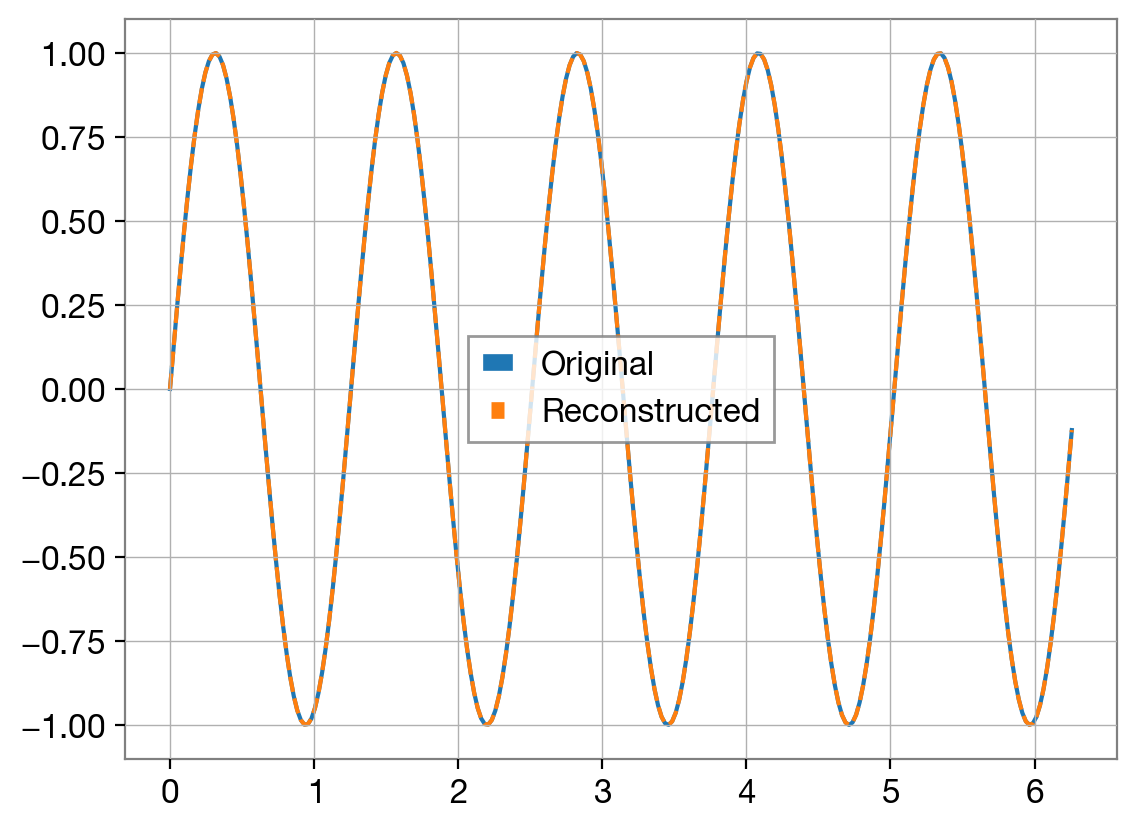

In [25]:
import numpy as np
import matplotlib.pyplot as plt

# Real-space field with 256 points
N = 256
x = np.linspace(0, 2*np.pi, N, endpoint=False)
f = np.sin(5 * x)  # example real field

# FFT using rfft (real FFT)
f_k = np.fft.rfft(f)  # length will be 129
print("Length of f_k:", len(f_k))  # -> 129

# Inverse FFT
f_back = np.fft.irfft(f_k, n=N)  # needs n=N to get original length
print("Reconstruction error:", np.max(np.abs(f - f_back)))  # should be ~0
print("Length of reconstructed domain:", len(f_back))  # should be ~0

# Optional: plot to verify
plt.plot(x, f, label="Original")
plt.plot(x, f_back, '--', label="Reconstructed")
plt.legend()
plt.show()


n :  8188
fluct:  2.2074728999800115


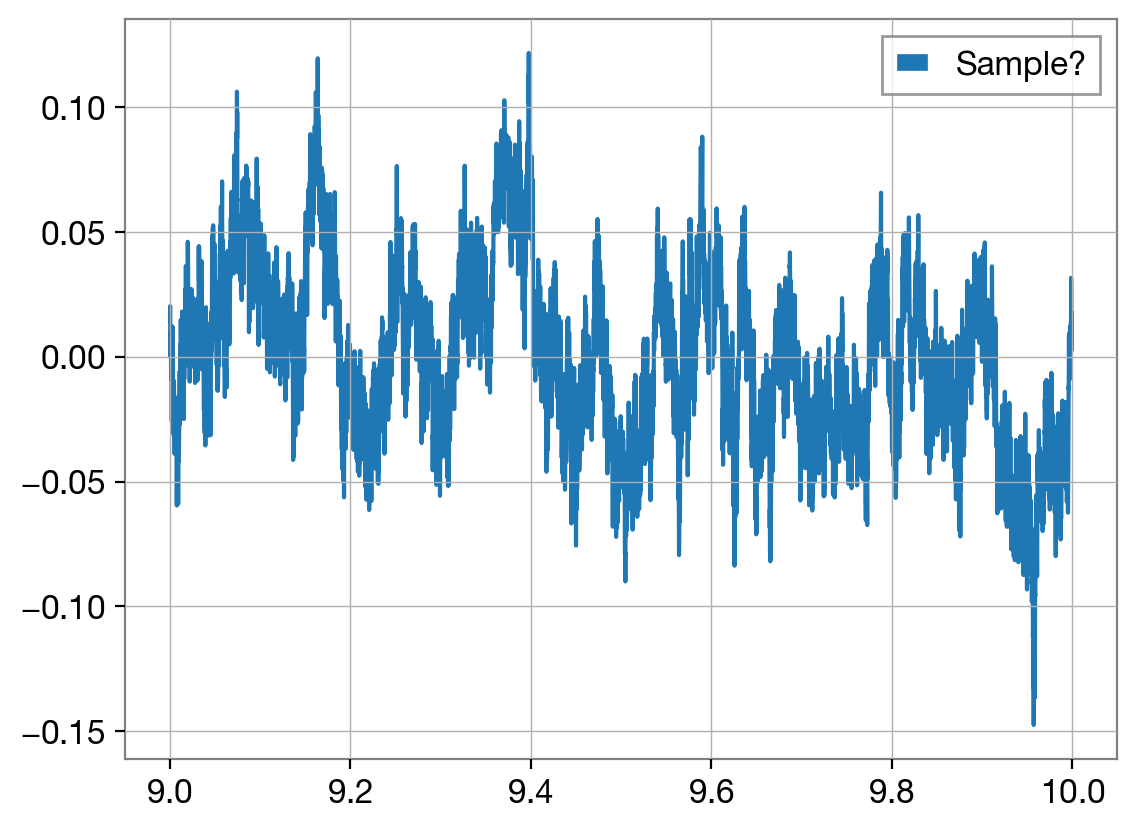

In [26]:
import numpy as np

n = inference_scheme.domain_ext.shape[0]
print("n : ", n)
P = mean_pow_spec  # shape (129,)
lp = len(P)
tmp = inference_scheme.domain_values_ext.val
L = np.max(tmp) - np.min(tmp)

dx = L / n
# k_vals = np.fft.rfftfreq(n, d=dx) * 2 * np.pi  # same as FFT

# k_domain_lengths = k_vals

# === SAFETY CHECKS ===
if n % 2 != 0:
    raise ValueError("Field length n must be even for consistent Nyquist handling.")

expected_lp = n // 2 + 1
if lp != expected_lp:
    raise ValueError(f"Power spectrum length mismatch: got {lp}, expected {expected_lp} for n={n}.")

if np.any(P < 0):
    raise ValueError("Power spectrum contains negative values.")

# Step 1: Generate white noise in rfft space (Hermitian-compatible)
xi = np.random.normal(0, 1, lp) + 1j * np.random.normal(0, 1, lp)
xi[0] = np.random.normal(0, 1)           # DC real
xi[-1] = np.random.normal(0, 1)          # Nyquist real

# Step 2: Apply sqrt power spectrum
s_k = np.sqrt(P) * xi

# Step 3: Inverse rFFT to get real field
sl = np.fft.irfft(s_k, n=n)
sl *= np.sqrt(n / L)

plt.plot(inference_scheme.domain_values_ext.val, sl, label="Sample?")
plt.legend()
fluctuations = np.sqrt(np.trapz(mean_pow_spec, k_domain_lengths))
print("fluct: ", fluctuations)

## Let's try the following: Get the posterior llslope etc values and then draw signal realizations based on that initial position via HT(A * harmonic_xi_s)

In [27]:
def create_strict_model(fluct, llslope, cfm_model_name, inf_scheme):
        s_offset = {
            "offset_mean": 0,
            # "offset_std": (1e-20, 1e-21),
            "offset_std": (1e-16, 1e-16),
        }

        s_fluctuations = {
            "target_subdomain": inf_scheme.domain_ext,
            "fluctuations": (fluct, 1e-16),
            "loglogavgslope": (llslope, 1e-16),
            # "flexibility": (1., 0.5),
            "flexibility": (1e-16, 1e-16),
            # "asperity": (5., 0.5),
            "asperity": (1e-16, 1e-16)
        }

        s_model = ift.CorrelatedFieldMaker(cfm_model_name)
        s_model.set_amplitude_total_offset(**s_offset)
        s_model.add_fluctuations(**s_fluctuations)

        s_model_meta_class = s_model  # contains information on the power spectra etc
        s_model = s_model.finalize()  # this is solely the operator chain
        return s_model, s_model_meta_class

strict_cfm_model, amp = create_strict_model(2, -1.36, "strict cfm",inference_scheme)

Offset amplitude: 9.92E-17 ± 9.19E-17
Total fluctuation amplitude: 2.00E+00 ± 7.40E-17


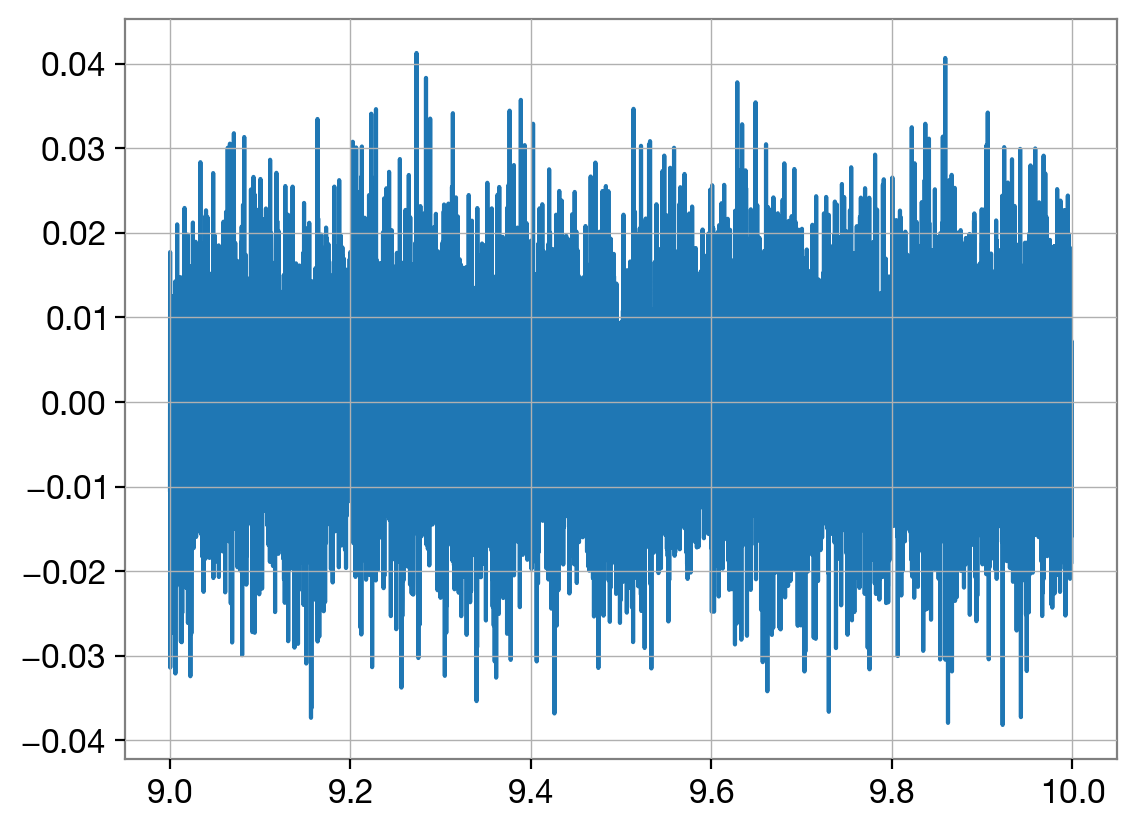

In [28]:

posterior_harmonic_samples = inference_scheme.posterior_samples
harmonic_sl = list(posterior_harmonic_samples.local_iterator())[0]   # one random harmonic sample
harmonic_xi_s = harmonic_sl["noise cfm xi"]

xi_ss = HT.adjoint(harmonic_xi_s)

num = 1
fields = [ift.from_random(strict_cfm_model.domain) for _ in range(num)]
samples = [strict_cfm_model(fld).val for fld in fields]

mean_sl = np.mean(samples, axis=0)

# plt.plot(inference_scheme.domain_values_ext.val, mean_sl)
plt.plot(inference_scheme.domain_values_ext.val, xi_ss.val)

In [29]:
test = ift.VerySimpleCorrelatedField(inference_scheme.domain_ext, fluctuations=2, loglogavgslope=-4, override_with_exact_values=True)

In [30]:
test.domain

DomainTuple.make((RGSpace(shape=(8188,), distances=(0.00012201067873717636,), harmonic=False),))

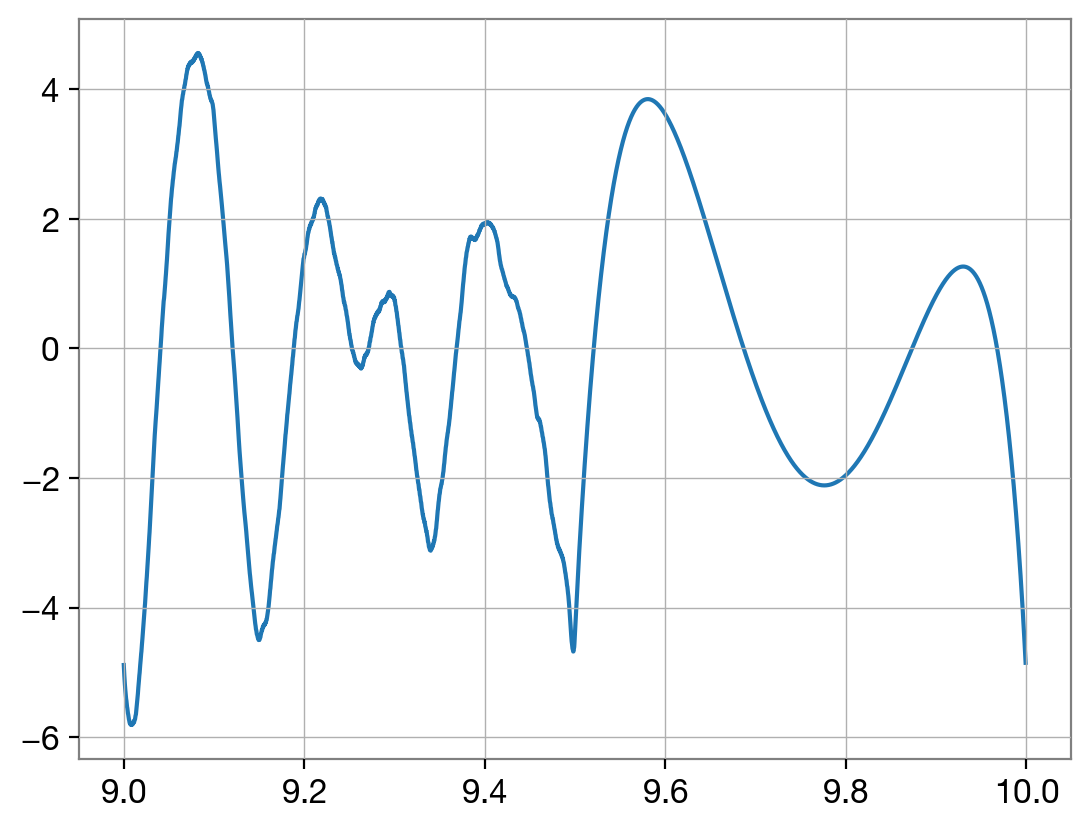

In [31]:
# test = ift.VerySimpleCorrelatedField(inference_scheme.domain_ext, fluctuations=2, loglogavgslope=-1.36, override_with_exact_values=True, custom_harmonic_xi_s=None)
test = ift.VerySimpleCorrelatedField(inference_scheme.domain_ext, fluctuations=2, loglogavgslope=-1.36, override_with_exact_values=True, custom_harmonic_xi_s=my_custom_harmonic_xi_s_from_first_run)
plt.plot(inference_scheme.domain_values_ext.val, test.val)

## How ducktape operator works

in the cfm, you build wrapper around operator chains that knows the full domain, you never need to call the e.g. normal-operators directly on the full multifield domain which would throw an error, because the normal operators expect a multifield(just the subfield they are concerned with as entry) input!

In [7]:
import numpy as np
import nifty8 as ift

# Step 1: Create domains
scalar_dom = ift.DomainTuple.scalar_domain()
multi_dom = ift.MultiDomain.make({
    "a time": scalar_dom,
    "b time": scalar_dom
})

# Step 2: Create a MultiField over the MultiDomain
mf = ift.MultiField.from_dict(domain=multi_dom, dct={
    "a time": ift.full(scalar_dom, 2.0),
    "b time": ift.full(scalar_dom, 4.0)
})

# Step 3: Create a ducktape operator to extract 'a time'
dt_op = ift.ducktape(scalar_dom, multi_dom, "a time")

# Step 4: Apply operator
result = dt_op(mf)

print("Result field:", result)
print("Result domain:", result.domain)
print("Result value:", result.val)


Result field: nifty8.Field instance
- domain      = DomainTuple, len: 0
- val         = array(2.)
- nbytes      = 0.000 MB
Result domain: DomainTuple, len: 0
Result value: 2.0


Lets visualize the xi_s

Text(0.5, 1.0, 'Fourier space')

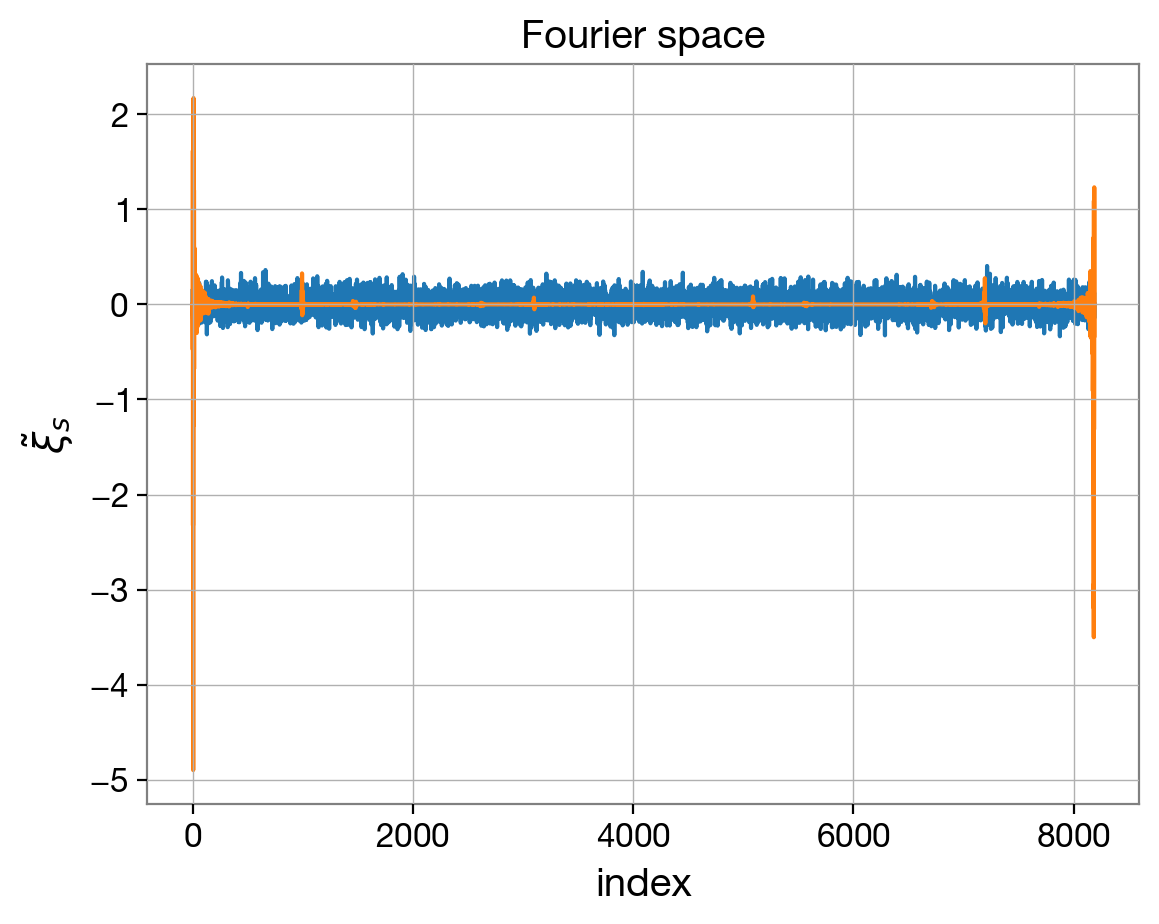

In [33]:
random_harmonic_xi_s = ift.from_random(HT.target, std=0.1)
plt.plot( random_harmonic_xi_s.val, label="Random harmonic xi_s")
plt.plot( my_custom_harmonic_xi_s_from_first_run, label="from reconstruction")
plt.xlabel("index")
plt.ylabel(r"$\tilde{\xi}_s$")
plt.title("Fourier space")

Text(0, 0.5, '$\\xi_s$')

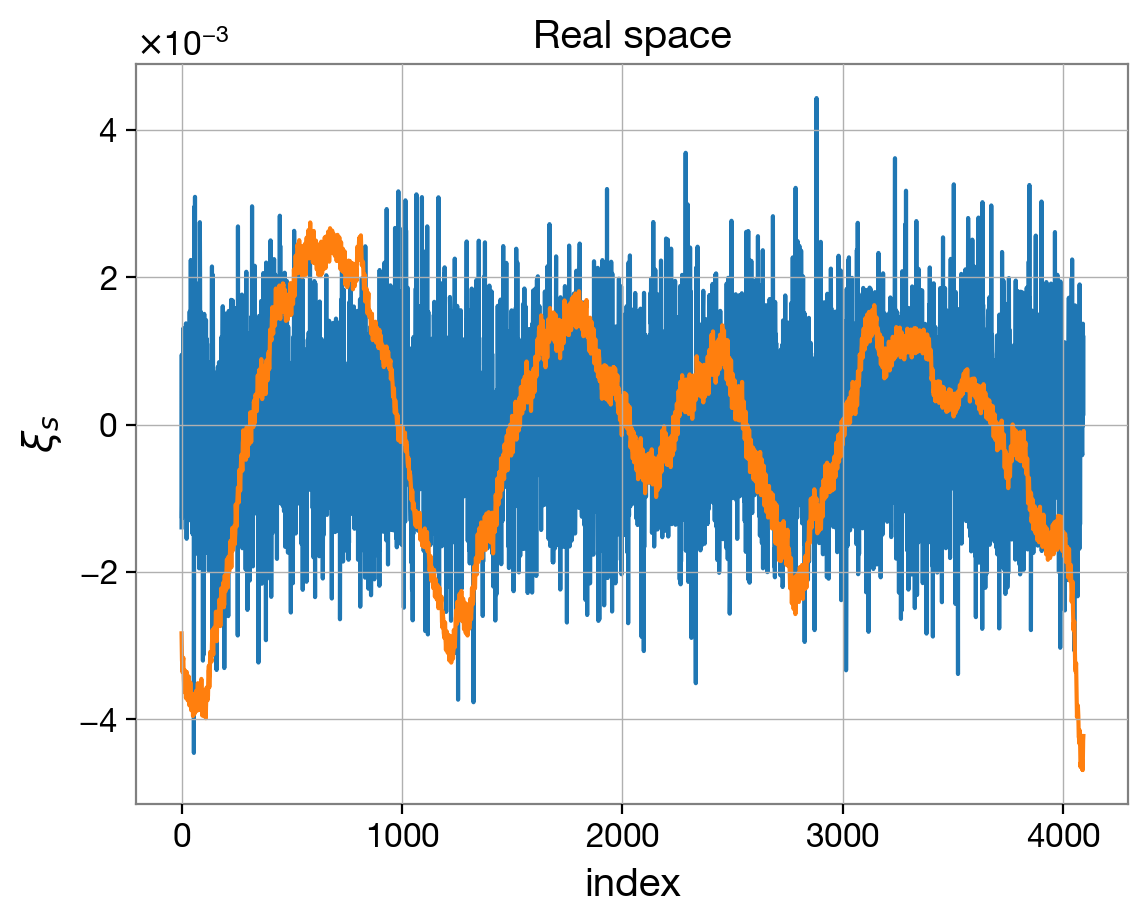

In [34]:
real_xi_sample = HT.adjoint(ift.Field(domain=HT.adjoint.domain, val=my_custom_harmonic_xi_s_from_first_run))
real_xi_sample_2 = HT.adjoint(random_harmonic_xi_s)
plt.plot(inference_scheme.X.adjoint(real_xi_sample_2).val, label="expected random sample")
plt.plot(inference_scheme.X.adjoint(real_xi_sample).val, label="reconstructed random sample")
plt.title("Real space")
plt.xlabel("index")
plt.ylabel(r"$\xi_s$")

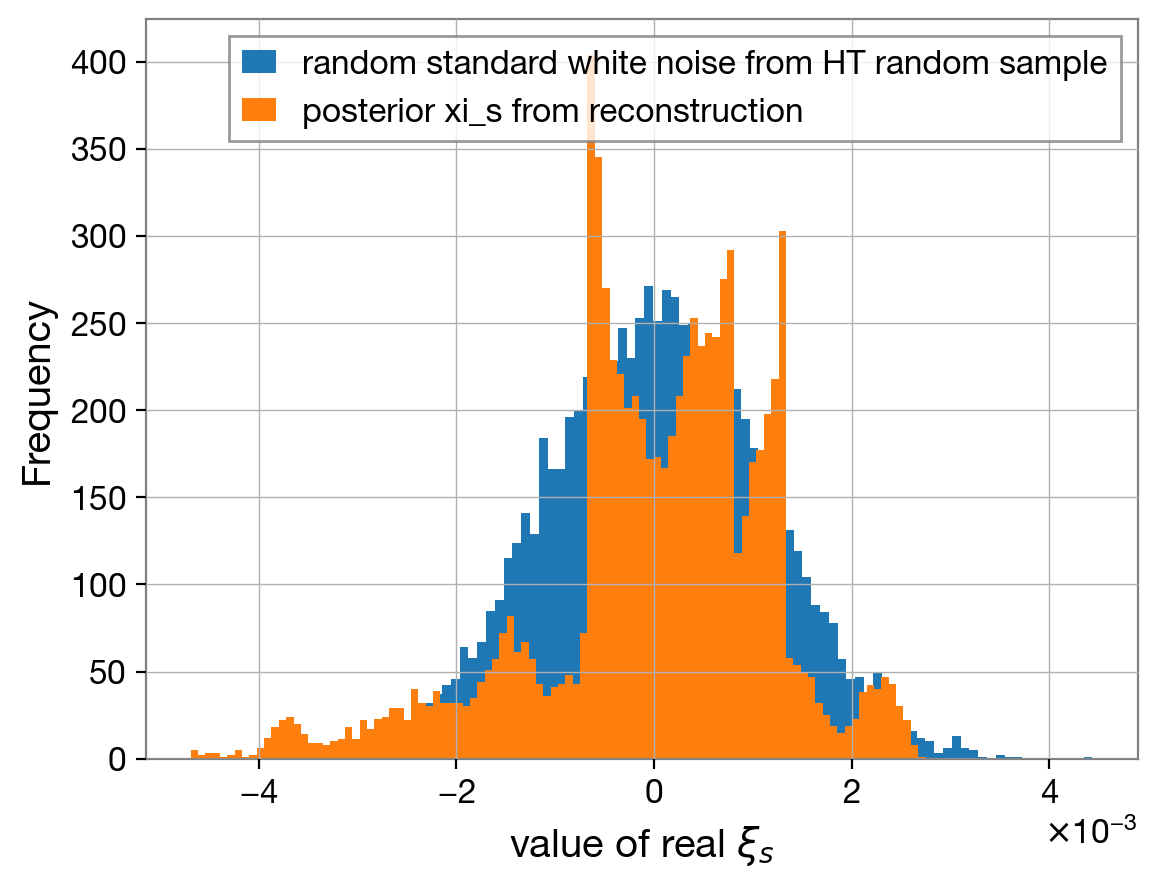

In [35]:
hist2 = plt.hist(real_xi_sample_2.val, bins=100, label="random standard white noise from HT random sample")
hist = plt.hist(real_xi_sample.val, bins=100, label="posterior xi_s from reconstruction")
plt.xlabel(r"value of real $\xi_s$")
plt.ylabel("Frequency")
plt.legend()

## Conclusions up to there

I managed to re-code the correlated field such that it creates almost the exact instance given some real space fixed parameter values. I want to use this to extract the power spectrum later on.
ToDo's / Comments / Questions
- I found out that the actual loglogavgslope calculated inside the model did not match the line fit on the log log diagram. I don't know why, maybe I can still test this out! <span style="color:green">actually, further down below with power analyzed it worked, what's up with that?</span>
- We also see that the posterior xi_s encodes correlation structure. This is not really good since our goal is to get the amplitude operator as carrier of all correlation information. Lets plot some further samples

using fluct , llslope =  2.4532976758962945 -2.9141719395594414


/Users/iason/PycharmProjects/stability-of-submoons/.venv/lib/python3.12/site-packages/matplotlib/cbook/__init__.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


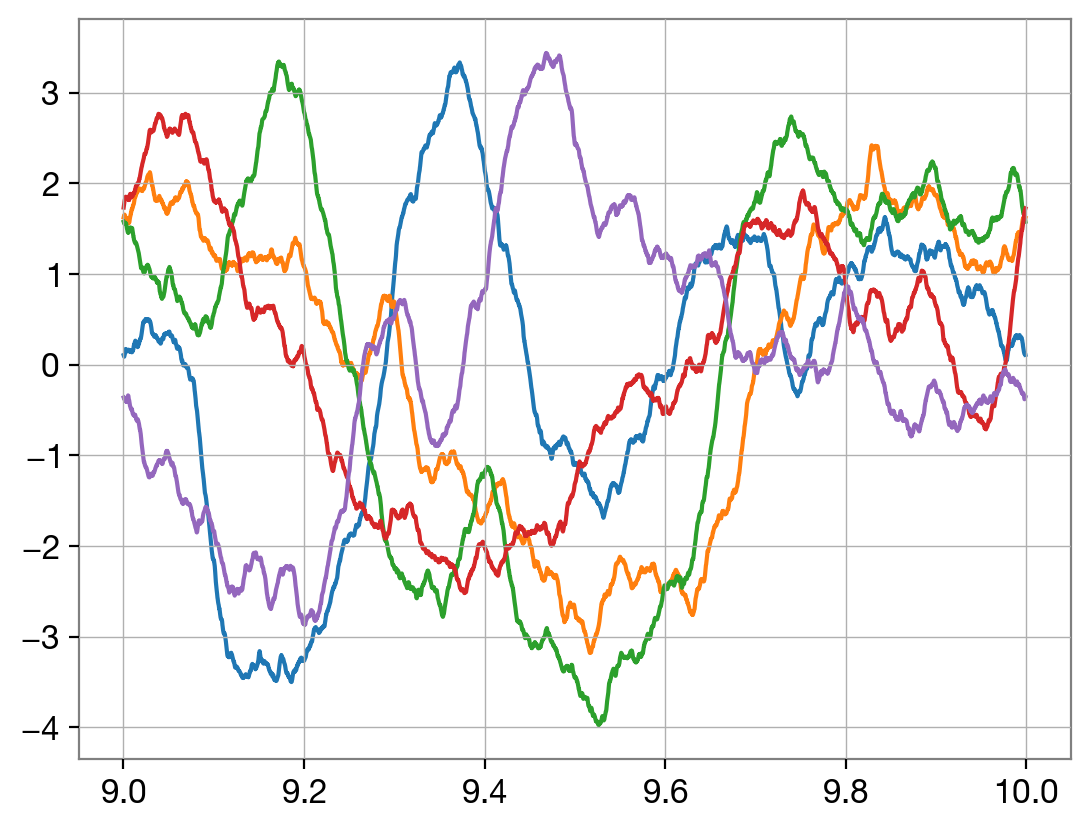

In [36]:

print("using fluct , llslope = ", model_parameters["fluctuations"], model_parameters["loglogavgslope"])

for _ in range(5):
    test = ift.VerySimpleCorrelatedField(inference_scheme.domain_ext, fluctuations=model_parameters["fluctuations"], loglogavgslope=model_parameters["loglogavgslope"], override_with_exact_values=True)
    plt.plot(inference_scheme.domain_values_ext.val, test.val)

As we can see from the last samples, these are still very rough signals. So lets try a run where the chi^2=1 by manually adjusting the noise level and setting a much smoother prior.

Let's build a custom noise covariance

mean squared noise level:  0.03180005677957517


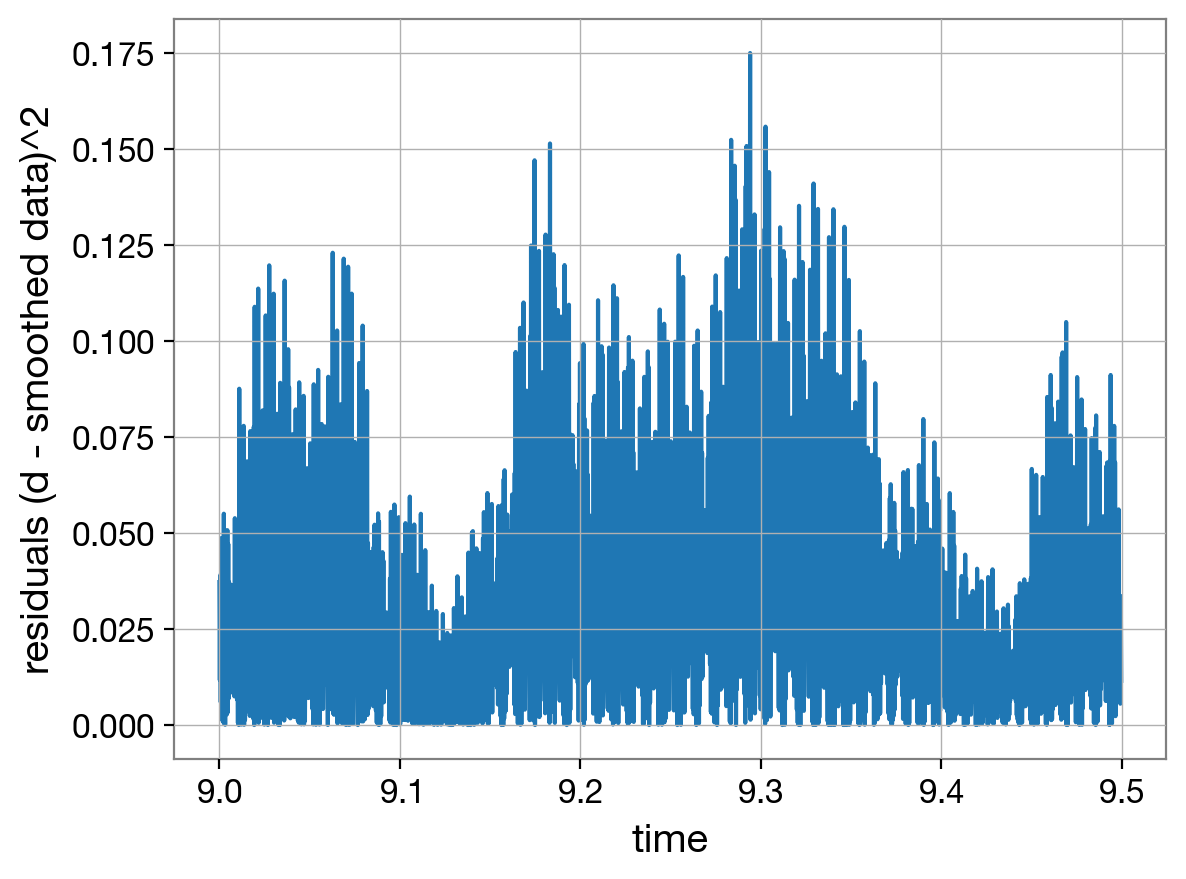

In [37]:
from scipy.ndimage import gaussian_filter1d

smoothed = gaussian_filter1d(d, sigma=3)  # adj

plt.plot(t, (smoothed-d)**2)
plt.xlabel("time")
plt.ylabel("residuals (d - smoothed data)^2")

print("mean squared noise level: ", np.mean((smoothed-d)**2))

my_noise_op = ift.DiagonalOperator(diagonal=ift.Field(domain=ift.DomainTuple.make(inference_scheme.data_space,), val=(smoothed-d)**2), sampling_dtype=np.float64)  # i dont think you should use this, just take it as an informed guess to the scale of the squared noise standard deviation => 0.2


In [ ]:
inference_scheme2 = ExecuteRGSpaceKL(
    discrete_time=t,
    d=d,
    cfm_model_name="noise cfm smooth prior ",
    kl_minimizations=5,
    fluct=(2, 1),
    llslope=(-4, 1),
    gaussian_noise_level=0.05,
    out_dir_name="outs/out_smooth_cfm3"
)

In [ ]:
inference_scheme2.run()

chi_sq reduced in dataspace:  0.6367438017034206


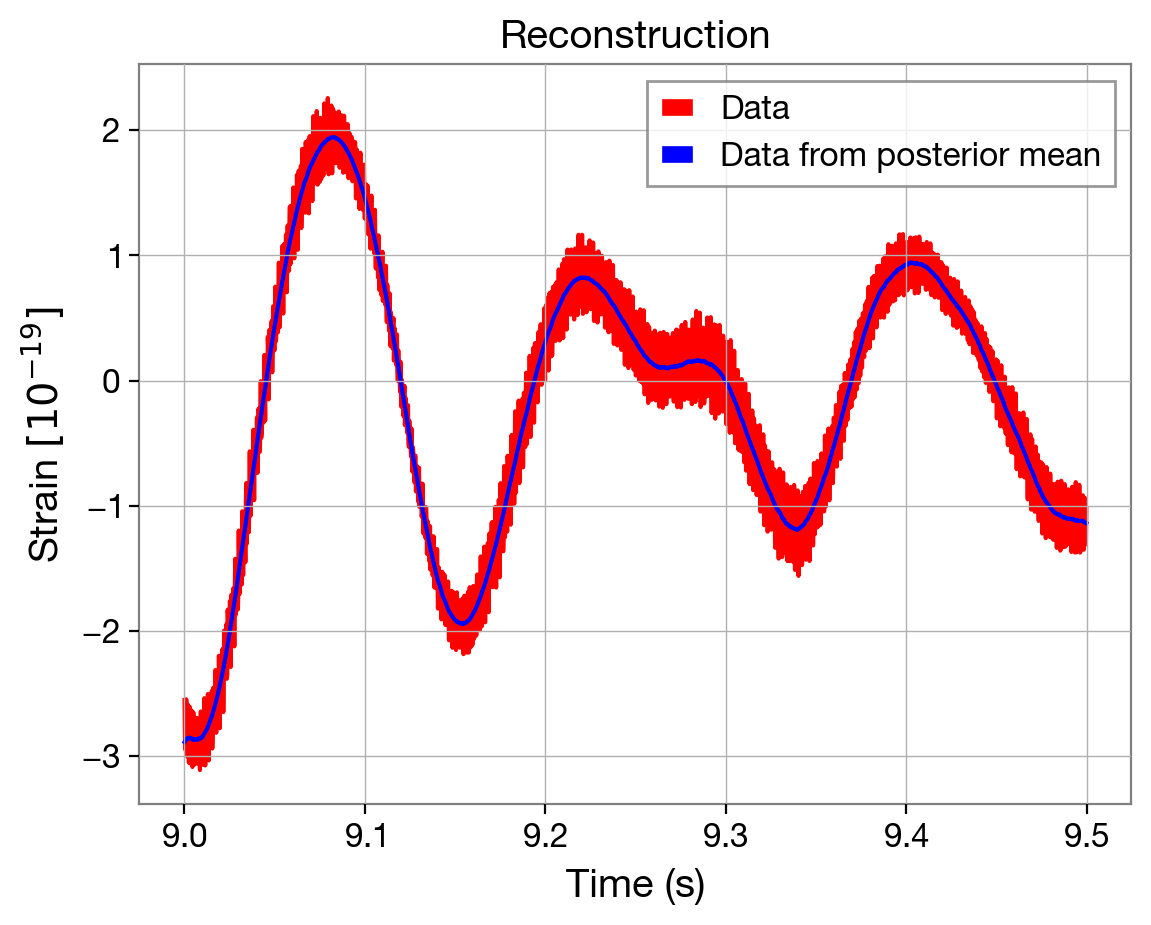

In [40]:
inference_scheme2.plot_posterior(plot_signal_space=False)

In [41]:
model_params_inf_scheme2 = calculate_model_parameters_from_latent_sample(inference_scheme2)



from prior choices 

	 {'offset_mean': 0, 'offset_std': (1e-16, 1e-16), 'target_subdomain': RGSpace(shape=(8188,), distances=(0.00012201067873717636,), harmonic=False), 'fluctuations': (2, 1), 'loglogavgslope': (-4, 1), 'flexibility': (1e-16, 1e-16), 'asperity': (1e-16, 1e-16)} 

 and latent parameters

	 {'noise cfm smooth prior asperity': array(1.65217726e-09), 'noise cfm smooth prior flexibility': array(2.38793887e-08), 'noise cfm smooth prior fluctuations': array(-0.92426649), 'noise cfm smooth prior loglogavgslope': array(1.43152919), 'noise cfm smooth prior spectrum': array([[ 4.61692201e-09, -3.33113435e-08, -3.21639182e-09, ...,
         4.19041613e-09, -1.82138258e-08,  1.17398494e-08],
       [ 1.01495057e-08,  1.37826601e-08,  6.15263714e-09, ...,
         1.13251694e-08, -1.02372502e-08,  1.55344494e-09]]), 'noise cfm smooth prior xi': array([ 6.43943025e-09, -1.88732034e-01, -4.10048259e+00, ...,
        3.89815246e+00, -9.52875468e-01, -1.22492493e+00]), 'noise cfm smoo

using fluct , llslope =  1.1560045777224384 -2.5684708116682375


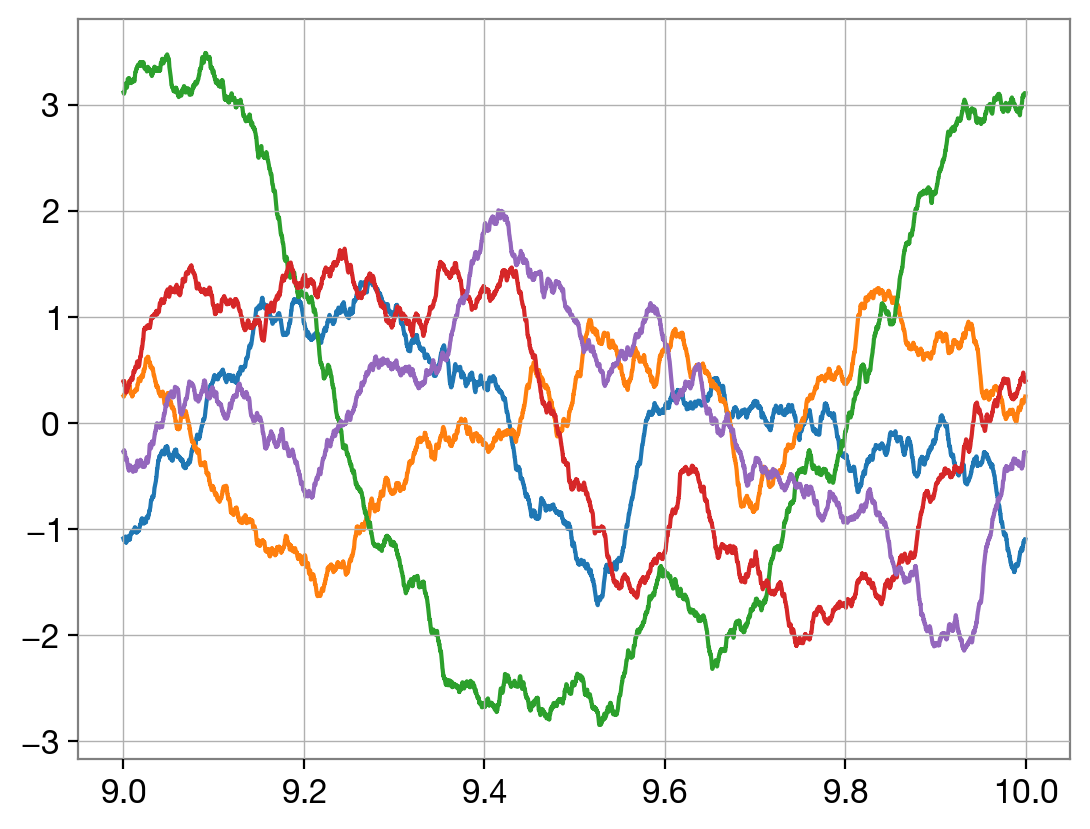

In [42]:

print("using fluct , llslope = ", model_params_inf_scheme2["fluctuations"], model_params_inf_scheme2["loglogavgslope"])

for _ in range(5):
    test = ift.VerySimpleCorrelatedField(inference_scheme.domain_ext, fluctuations=model_params_inf_scheme2["fluctuations"], loglogavgslope=model_params_inf_scheme2["loglogavgslope"], override_with_exact_values=True)
    plt.plot(inference_scheme.domain_values_ext.val, test.val)

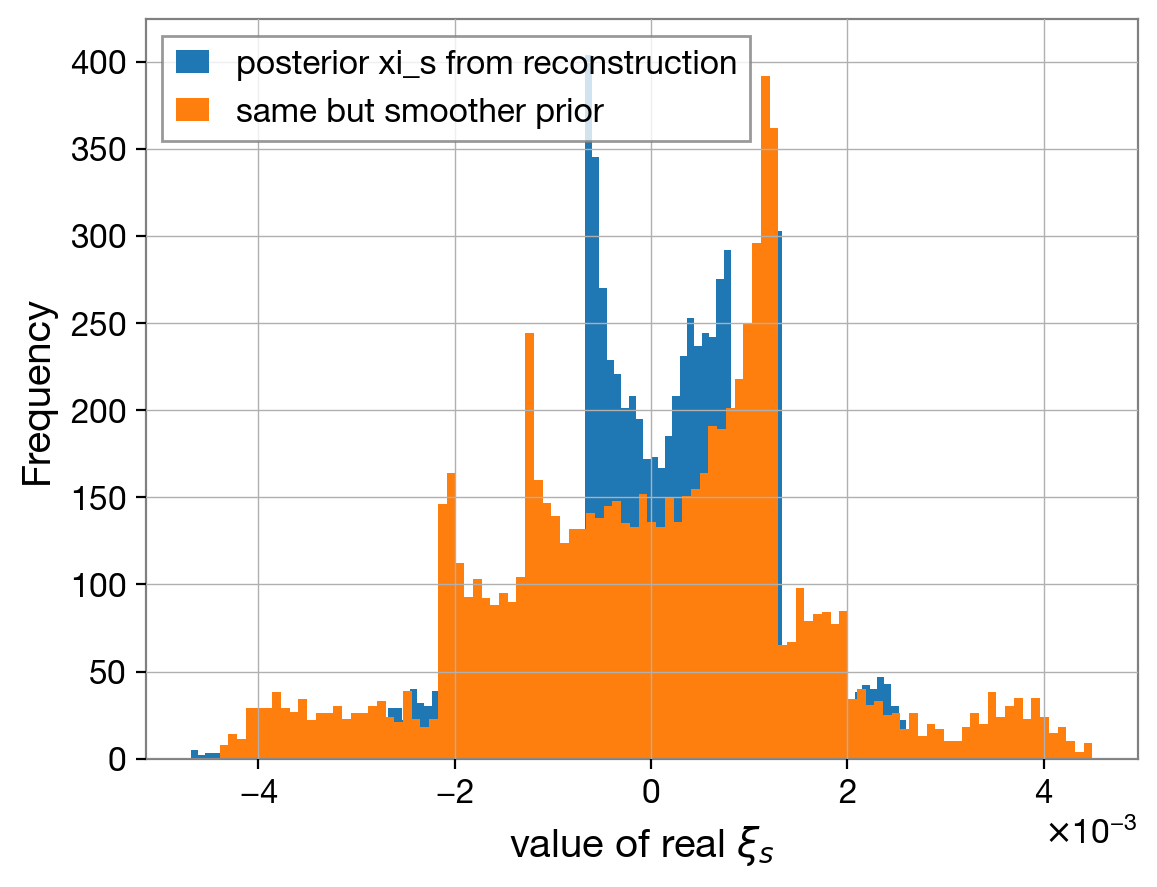

In [43]:
s_mean_latent_inf_scheme_2 = inference_scheme2.posterior_samples.sample_stat()[0]
posterior_xi_s_inf_scheme_2 = s_mean_latent_inf_scheme_2.val["noise cfm smooth prior xi"]
posterior_xi_s_inf_scheme_2_real = HT.adjoint(ift.Field(HT.adjoint.domain, val=posterior_xi_s_inf_scheme_2))


hist2 = plt.hist(real_xi_sample.val, bins=100, label="posterior xi_s from reconstruction")
hist = plt.hist(posterior_xi_s_inf_scheme_2_real.val, bins=100, label="same but smoother prior")
plt.xlabel(r"value of real $\xi_s$")
plt.ylabel("Frequency")
plt.legend()

Let's model the noise via two components, one low frequency smooth field around which another cfm of low llslope models deviations.

In [44]:
class ExecuteRGSpaceKLDoubleCFM:
    def __init__(self, discrete_time, d, cfm_model_name1, cfm_model_name2, n_pix_fac=2, x_fac=2, response="linear mask",
                 sampling_rate_hz=4096, kl_minimizations=10, fluct_low_freq=(1,1), llslope_low_freq=(-4,1), fluct_high_freq=(1,1), llslope_high_freq=(-4,1),
                 gaussian_noise_level=1e-16, out_dir_name="out_index_my_playground"):
        """
        Parameters
        ----------
        discrete_time : np.array
            The x values at which discrete data occur.
        d : array-like
            Observed data to be analyzed.
        cfm_model_name : str
            What to call the CF ("key").
        n_pix_fac : int, optional
            Factor for determining the number of pixels in the reconstruction grid by multiplying this factor
            onto the number of datapoints. Default is 2.
        x_fac : int, optional
            Expansion factor for the spatial domain, s.t. extended domain is of length x_fac * n_pix_fac * len(d).
             Default is 2.
        response : str, optional
            Type of response model to apply (e.g., 'linear mask'). Default is 'linear mask'.
        sampling_rate_hz : float, optional
            Data sampling rate in Hertz. Default is 4096. Used to determine which points to mask in the signal domain.
        kl_minimizations : int, optional
            Number of KL divergence minimization steps. Default is 10.
        fluct : tuple of float, optional
            Parameters controlling the prior fluctuation amplitude. Default is (1, 1).
        llslope : tuple of float, optional
            Slope range for the log-log power spectrum prior. Default is (-4, 1).
        gaussian_noise_level : float, optional
            Assumed level of additive Gaussian noise. Default is 1e-16.
        out_dir_name : str, optional
            Where to store the output files. Default is "out_index_my_playground".
        """

        x0, xf = (np.min(discrete_time), np.max(discrete_time))

        n_dtps = len(d)
        n_pix = n_pix_fac * n_dtps

        print("Number of datapoints: ", n_dtps)
        print("Constructing RGspace of this number of points: ", n_pix, " (not extended)")

        length_of_domain = xf - x0

        self.out_dir_name = out_dir_name
        self.distances =  length_of_domain / n_pix
        self.domain = ift.RGSpace(shape=(n_pix,), distances=self.distances)
        self.domain_ext = ift.RGSpace(shape=(n_pix*x_fac,), distances=self.distances)
        self.data_space = ift.UnstructuredDomain(shape=(n_dtps, ))
        self.data_field = ift.Field(ift.DomainTuple.make((self.data_space,)),  val=d)

        self.X = ift.FieldZeroPadder(self.domain, new_shape=(n_pix*x_fac, ))

        if response != "linear mask":
            raise ValueError("Not implemented yet")

        mask_op = Mask(ift.DomainTuple.make((self.domain,)), sampling_rate_hz, x0, xf)
        self.R_physical = mask_op

        self.posterior_samples = None
        self.kl_minimizations = kl_minimizations
        self.fluct_low_freq = fluct_low_freq
        self.fluct_high_freq = fluct_high_freq
        self.llslope_high_freq = llslope_high_freq
        self.llslope_low_freq = llslope_low_freq
        self.cfm_model_name1 = cfm_model_name1
        self.cfm_model_name2 = cfm_model_name2
        self.gaussian_noise_level = gaussian_noise_level
        self.prior_parameters = None
        self.n_dtps = n_dtps
        self.n_pix = n_pix

        mdl = self._create_model(fluctuations1=fluct_low_freq, llslope1=llslope_low_freq, fluctuations2=fluct_high_freq, llslope2=llslope_high_freq, cfm_model_name1=cfm_model_name1, cfm_model_name2=cfm_model_name2)

        self.model, self._cf = (mdl[0], mdl[1])
        self.domain_values = ift.Field(ift.DomainTuple.make(self.domain), np.linspace(x0, xf, n_pix))
        self.domain_values_ext = ift.Field(ift.DomainTuple.make(self.domain_ext), np.linspace(x0, (xf-x0)*x_fac+x0, n_pix*x_fac))
        self.discrete_domain_values = discrete_time
        self.s_model_meta_class1 = None
        self.s_model_meta_class2 = None
        self.full_s_model_meta_class = None

        self._R_full = self.R_physical @ self.X.adjoint @ self.model

        self._N = ift.ScalingOperator(self.data_field.domain, gaussian_noise_level, sampling_dtype=np.float64)


    def _create_model(self, fluctuations1, llslope1, fluctuations2, llslope2, cfm_model_name1, cfm_model_name2):
        s_offset = {
            "offset_mean": 0,
            # "offset_std": (1e-20, 1e-21),
            "offset_std": (1e-16, 1e-16),
        }

        s_fluctuations1 = {
            "target_subdomain": self.domain_ext,
            "fluctuations": (fluctuations1[0], fluctuations1[1]),
            "loglogavgslope": (llslope1[0], llslope1[1]),
            # "flexibility": (1., 0.5),
            "flexibility": (1e-16, 1e-16),
            # "asperity": (5., 0.5),
            "asperity": (1e-16, 1e-16)
        }

        s_fluctuations2 = {
            "target_subdomain": self.domain_ext,
            "fluctuations": (fluctuations2[0], fluctuations2[1]),
            "loglogavgslope": (llslope2[0], llslope2[1]),
            # "flexibility": (1., 0.5),
            "flexibility": (1e-16, 1e-16),
            # "asperity": (5., 0.5),
            "asperity": (1e-16, 1e-16)
        }

        s_model1 = ift.CorrelatedFieldMaker(cfm_model_name1)
        s_model2 = ift.CorrelatedFieldMaker(cfm_model_name2)

        s_model1.set_amplitude_total_offset(**s_offset)
        s_model2.set_amplitude_total_offset(**s_offset)

        s_model1.add_fluctuations(**s_fluctuations1)
        s_model2.add_fluctuations(**s_fluctuations2)

        # s_model_meta_class = s_model1+s_model2  # contains information on the power spectra etc
        s_model_meta_class = None  # idk

        s_model_meta_class1 = s_model1  # contains information on the power spectra etc
        s_model_meta_class2 = s_model2 # contains information on the power spectra etc

        s_model = s_model1.finalize()+s_model2.finalize()  # this is solely the operator chauin
        self.prior_parameters_low_frequency = {**s_offset, **s_fluctuations1}
        self.prior_parameters_high_frequency = {**s_offset, **s_fluctuations2}
        self.s_model_meta_class1 = s_model_meta_class1
        self.s_model_meta_class2 = s_model_meta_class2
        self.full_s_model_meta_class = s_model_meta_class
        return s_model, s_model_meta_class

    def _create_gaussian_likelihood(self):
        N = self._N
        R = self._R_full
        likelihood_energy = ift.GaussianEnergy(self.data_field, N.inverse) @ R
        return likelihood_energy

    def _execute_kl(self, lh_energy, kl_minimizations = 10):

        posterior_samples = ift.optimize_kl(
            likelihood_energy=lh_energy,
            total_iterations=kl_minimizations,
            n_samples=kl_sampling_rate,
            kl_minimizer=descent_finder,
            sampling_iteration_controller=ic_sampling_lin,
            nonlinear_sampling_minimizer=geoVI_sampling_minimizer,
            output_directory=self.out_dir_name,
            return_final_position=False,
            resume=True)

        print("Posterior samples saved. Analyze via class.plot_posterior()")
        self.posterior_samples = posterior_samples

    def run(self):
        print("Creating Gaussian likelihood...")
        lh_energy = self._create_gaussian_likelihood()
        print("Created Gaussian likelihood, running KL.")
        self._execute_kl(lh_energy, kl_minimizations=self.kl_minimizations)

    def plot_posterior(self, plot_signal_space=False, plot_with_variance=False, show=True):
        if self.posterior_samples is None:
            raise ValueError("Execute `run` first")

        s_m, s_v = self.posterior_samples.sample_stat(self.model)

        if plot_signal_space:
            plt.plot(self.discrete_domain_values, self.data_field.val, "r-", label="Data")  # DATA
            plt.plot(self.domain_values.val, self.X.adjoint(s_m).val, "b-", label="Posterior mean")
            if plot_with_variance:
                plt.errorbar(self.domain_values.val, self.X.adjoint(s_m).val, yerr=np.sqrt(self.X.adjoint(s_v).val))

        else:
            res_sq = (self.data_field.val - self.R_physical(self.X.adjoint(s_m)).val)**2
            chi_sq = np.sum(res_sq) / (self.gaussian_noise_level * self.n_dtps)
            print("chi_sq reduced in dataspace: ", chi_sq, " without dividing out the noise level: ", np.sum(res_sq) / self.n_dtps, " and then doing the operation ", 1/self.gaussian_noise_level, " gives ", np.sum(res_sq) / self.n_dtps/self.gaussian_noise_level)
            plt.plot(self.discrete_domain_values, self.data_field.val, "r-", label="Data")  # DATA
            plt.plot(self.discrete_domain_values, self.R_physical(self.X.adjoint(s_m)).val, "b-", label="Data from posterior mean")

        plt.legend()
        plt.xlabel('Time (s)')
        plt.ylabel('Strain $[10^{-19}]$')
        plt.title("Reconstruction")
        if show:
            plt.show()

    def plot_prior_samples(self, num=5, plot_in_data_space=False, apply_adjoint_zp = True):
        plt.ylabel("strain $[10^{-19}]$")
        if not plot_in_data_space:
            op = self.model
            samples = list(op(ift.from_random(op.domain)) for _ in range(num))
            if apply_adjoint_zp:
                plt.xlabel("time in seconds")
                y = [self.X.adjoint(sl) for sl in samples]
                [plt.plot(self.domain_values.val, sl.val) for sl in y]
                return y
            else:
                plt.xlabel("time in seconds (extended domain)")
                [plt.plot(self.domain_values_ext.val, sl.val) for sl in samples]
                return samples
        else:
            op = self.R_physical @ self.X.adjoint @ self.model
            samples = list(op(ift.from_random(op.domain)) for _ in range(num))
            for sample in samples:
                plt.plot(self.discrete_domain_values, sample.val)

    def plot_data_realization(self):
        data_realization = self._R_full(ift.from_random(self.model.domain)) + self._N.draw_sample()
        plt.plot(self.discrete_domain_values, data_realization.val)

    def plot_prior_fluctuations_distribution(self, mode="low freq"):
        if mode == "low freq":
            plot_histogram(mean=self.fluct_low_freq[0], sigma=self.fluct_low_freq[1], n_samples=1000, mode="Lognormal")
        elif mode == "high freq":
            plot_histogram(mean=self.fluct_high_freq[0], sigma=self.fluct_high_freq[1], n_samples=1000, mode="Lognormal")
        else:
            raise ValueError("Mode must be 'low freq' or 'high freq'")

    def plot_pow_spec(self):
        a = self._cf.amplitude
        harmonic_samples = list(self.posterior_samples.local_iterator())
        # print("here: ",harmonic_samples[0].domain, harmonic_samples[0].val)
        spectrum_realizations = [a.force(sl) for sl in harmonic_samples]
        # print("here: ", spectrum_realizations[0].val)
        # print("here: ", spectrum_realizations[0].val[:3])
        # print("here: ", spectrum_realizations[0].val[-3:])

        arrs = [sp.val for sp in spectrum_realizations]
        mean_pow_spec = np.mean(arrs, axis=0)

        all_k_domains = [spec.domain[0].k_lengths for spec in spectrum_realizations]
        k_domain_lengths = all_k_domains[0]
        # print("Are all k-domains the same?", np.all(all_k_domains == all_k_domains[0]))

        for spec in spectrum_realizations:
            plt.plot(k_domain_lengths, spec.val, color="black", alpha=0.3)

        plt.plot(k_domain_lengths, mean_pow_spec, label="Posterior mean pow spec", lw=5)
        plt.loglog()

        plt.xlabel(r"Frequency $\omega$")
        plt.ylabel(r"$P_n(\omega)$")

        plt.legend()
        plt.ylim(1e-7,10)
        return k_domain_lengths, mean_pow_spec


    def get_mean_posterior_model_parameters(self):
        l_sl = self.posterior_samples.sample_stat()[0]  # The posterior latent multifield

        parameter_names = {
        "fluctuations": "lognormal",
        "loglogavgslope": "normal",
        "flexibility": "lognormal",
        "asperity": "lognormal"
        }

        functions = {
            "lognormal": np.exp,
            "normal": lambda arg: arg, # unity
        }

        res = l_sl.val.copy()

        for key in l_sl.keys():

            xi = l_sl[key]

            if "high frequency" in key:
                prior_choices = self.prior_parameters_high_frequency
            elif "low frequency" in key:
                prior_choices = self.prior_parameters_low_frequency
            else:
                raise NotImplementedError


            for parameter_name in parameter_names.keys():
                if parameter_name in key:
                    # calculate values
                    mode = parameter_names[parameter_name]
                    if mode == "lognormal":
                        mean_sig = prior_choices[parameter_name]
                        mean, sig = lognormal_moments(mean_sig[0], mean_sig[1])
                    elif mode == "normal":
                        mean_sig = prior_choices[parameter_name]
                        mean, sig = (mean_sig[0], mean_sig[1])
                    else:
                        raise ValueError("Unknown mode")
                    res[key] = functions[mode]( xi * sig + mean).val

        result = {}

        for key in res.keys():
            if any(param_name in key for param_name in parameter_names.keys()):
                result[key] = res[key]

        result2 = {}

        for key in result.keys():
            if "high frequency" in key:
                prefix = "high_frequency_"
            elif "low frequency" in key:
                prefix = "low_frequency_"
            else:
                raise NotImplementedError
            parameter_name = key.split(" ")[-1]
            result2[prefix+parameter_name] = result[key]

        return result2



In [ ]:
inference_scheme_double_model = ExecuteRGSpaceKLDoubleCFM(
    discrete_time=t,
    d=d,
    cfm_model_name1="noise cfm low frequency component ",
    cfm_model_name2="noise cfm high frequency component ",
    kl_minimizations=7,
    fluct_low_freq=(2, 1),
    llslope_low_freq=(-4, 1),
    fluct_high_freq=(0.3, 0.5),
    llslope_high_freq=(-0.5, 0.5),
    gaussian_noise_level=1e-3,
    out_dir_name="outs/out_smooth_cfm5"
)

inference_scheme_double_model.plot_prior_fluctuations_distribution(mode="low freq")


In [ ]:
inference_scheme_double_model.run()

chi_sq reduced in dataspace:  0.04357102422454929  without dividing out the noise level:  4.357102422454929e-05  and then doing the operation  1000.0  gives  0.04357102422454929


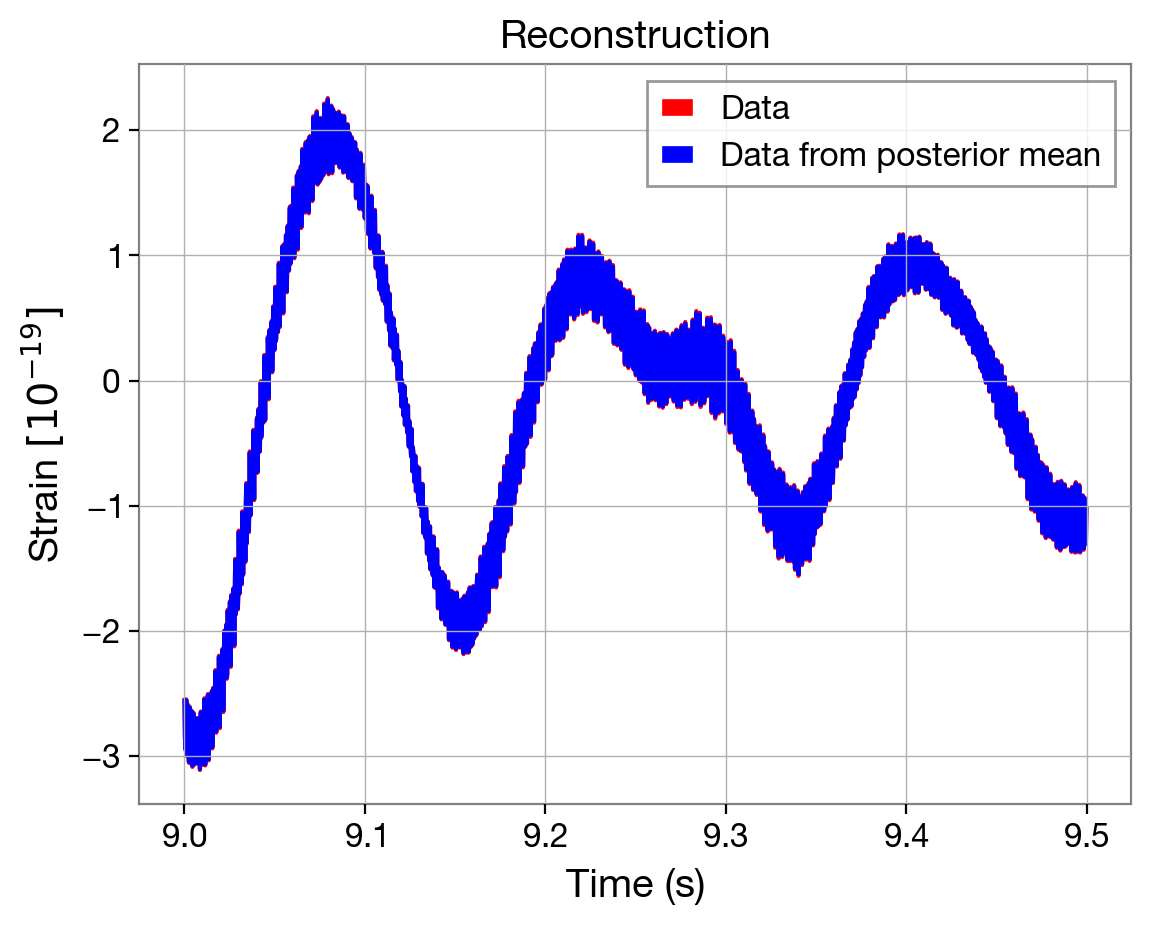

In [47]:
inference_scheme_double_model.plot_posterior()

In [48]:
myDict = inference_scheme_double_model.get_mean_posterior_model_parameters()
print(myDict)

tmp = inference_scheme_double_model.posterior_samples.sample_stat()[0].val
posterior_high_freq_xi_s = tmp["noise cfm high frequency component xi"]
posterior_low_freq_xi_s = tmp["noise cfm low frequency component xi"]

s_low_frequency = ift.VerySimpleCorrelatedField(inference_scheme.domain_ext, fluctuations=myDict["low_frequency_fluctuations"], loglogavgslope=myDict["low_frequency_loglogavgslope"], override_with_exact_values=True, custom_harmonic_xi_s=posterior_low_freq_xi_s)

s_high_frequency = ift.VerySimpleCorrelatedField(inference_scheme.domain_ext, fluctuations=myDict["high_frequency_fluctuations"], loglogavgslope=myDict["high_frequency_loglogavgslope"], override_with_exact_values=True, custom_harmonic_xi_s=posterior_high_freq_xi_s)

{'high_frequency_asperity': array(7.07106833e-17), 'high_frequency_flexibility': array(7.07106736e-17), 'high_frequency_fluctuations': array(0.32338062), 'high_frequency_loglogavgslope': array(-1.00467099), 'low_frequency_asperity': array(7.07106809e-17), 'low_frequency_flexibility': array(7.07106803e-17), 'low_frequency_fluctuations': array(1.34670621), 'low_frequency_loglogavgslope': array(-2.81495564)}


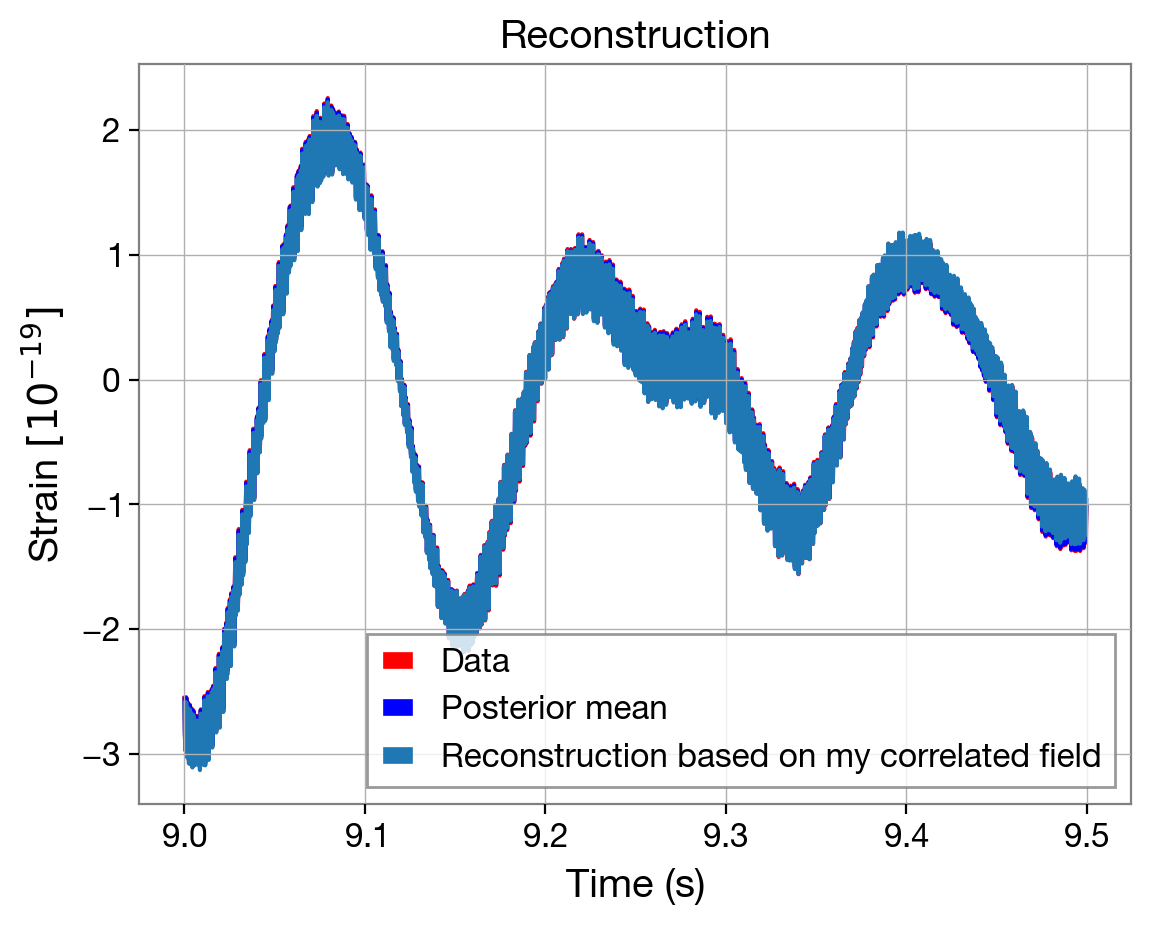

In [49]:
inference_scheme_double_model.plot_posterior(plot_signal_space=True, show=False)
plt.plot(inference_scheme_double_model.domain_values.val, inference_scheme_double_model.X.adjoint(s_low_frequency+s_high_frequency).val, label="Reconstruction based on my correlated field")
plt.legend()

So now lets plot samples

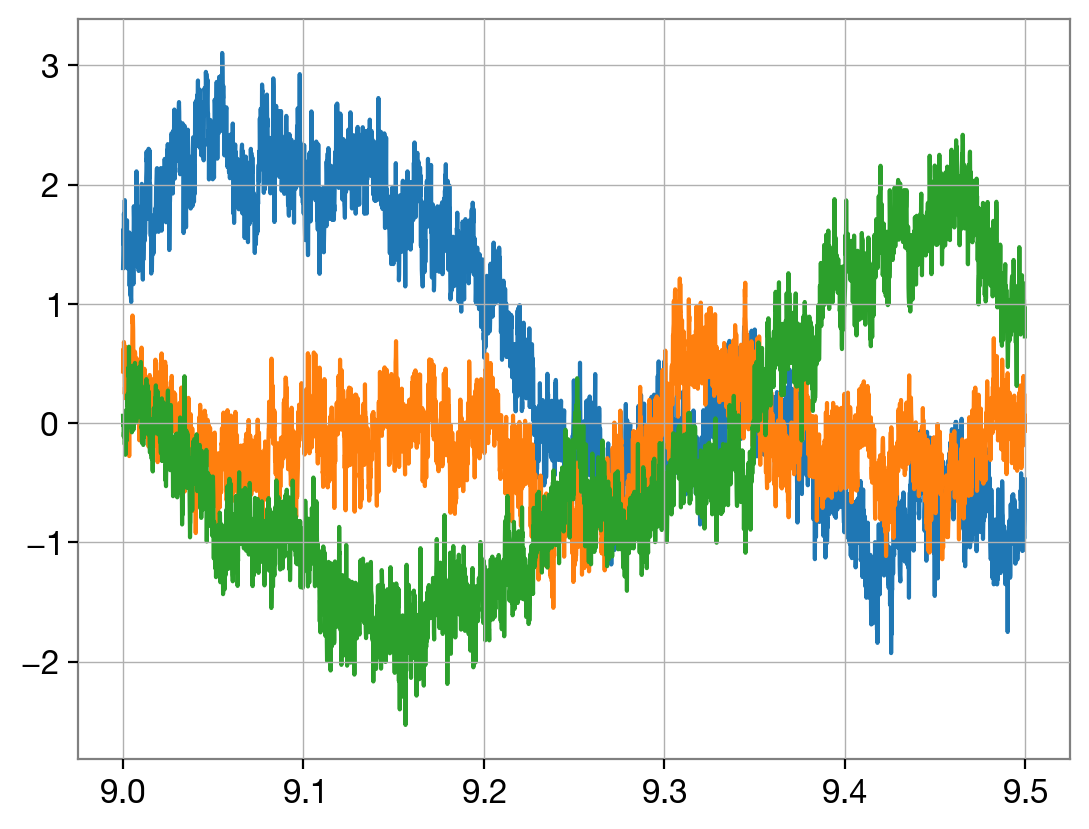

In [50]:
for _ in range(3):
    s_low_frequency = ift.VerySimpleCorrelatedField(inference_scheme.domain_ext, fluctuations=myDict["low_frequency_fluctuations"], loglogavgslope=myDict["low_frequency_loglogavgslope"], override_with_exact_values=True)

    s_high_frequency = ift.VerySimpleCorrelatedField(inference_scheme.domain_ext, fluctuations=myDict["high_frequency_fluctuations"],loglogavgslope=myDict["high_frequency_loglogavgslope"], override_with_exact_values=True)

    plt.plot(inference_scheme_double_model.domain_values.val, inference_scheme_double_model.X.adjoint(s_low_frequency+s_high_frequency).val)

plt.show()

From the samples, we obviously see that a smooth envelope around the high frequency fluctuations is missing.

## Today, 4th of June,

- I would like to examine the frequency content of the data. Since it stationary, a simple absolute squared fourier amplitude should give the power spectrum with some normalization.
- I would like to plot the combined power spectrum of the double cfm process
- Also note that the width of the deviations around the mean line in the data could maybe be modelled by some kind of exponential or varying envelope. Maybe this is a good idea to implement some time, since even if I infer the noise alongside the signal later on, I will need a model for the noise; Although the problem is that in general if I model the signal as well as the noise as a cfm, I think the smooth signal cfm will be completely degenerate with the smooth noise low frequency cfm.. what can we do here...

In [51]:
import nifty8 as ift

In [52]:
my_posterior_field = s_low_frequency+s_high_frequency
test3 = ift.power_analyze(HT(my_posterior_field))

[]

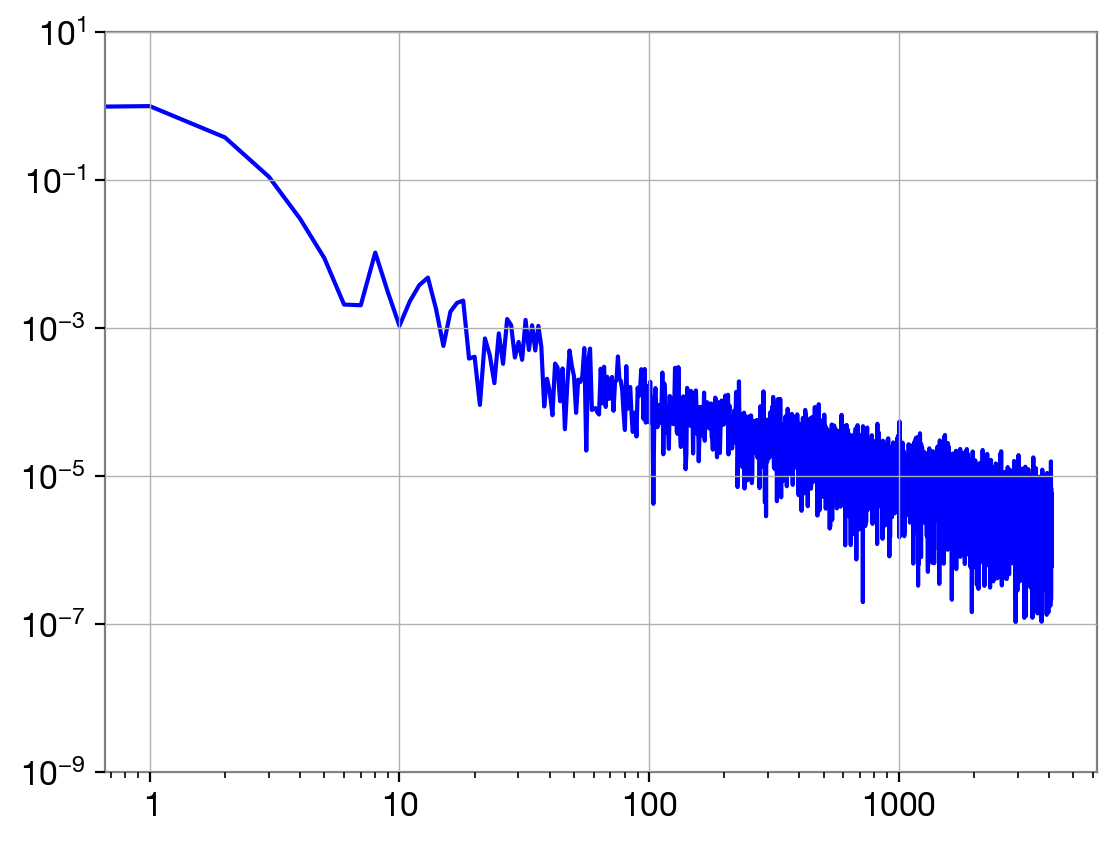

In [53]:
k_lengths_2 = test3.domain[0].k_lengths
plt.plot(k_lengths_2, test3.val, "b-")
plt.ylim(1e-9, 10)
plt.loglog()

## Power analyze magic

In [54]:
inference_scheme_2 = ExecuteRGSpaceKL(
    discrete_time=t,
    d=d,
    cfm_model_name="noise cfm ",
    kl_minimizations=5,
    fluct=(2, 1e-16),
    llslope=(-4, 1e-16),
    gaussian_noise_level=0.1
)

Offset amplitude: 1.01E-16 ± 9.48E-17
Total fluctuation amplitude: 2.00E+00 ± 9.20E-17


Number of datapoints:  2047
Constructing RGspace of this number of points:  4094  (not extended)
Based on sampling rate, length and shape of domain, keeping  2047  points of continuous signal.


living on domain:  RGSpace(shape=(4094,), distances=(0.00012201067873717636,), harmonic=False)


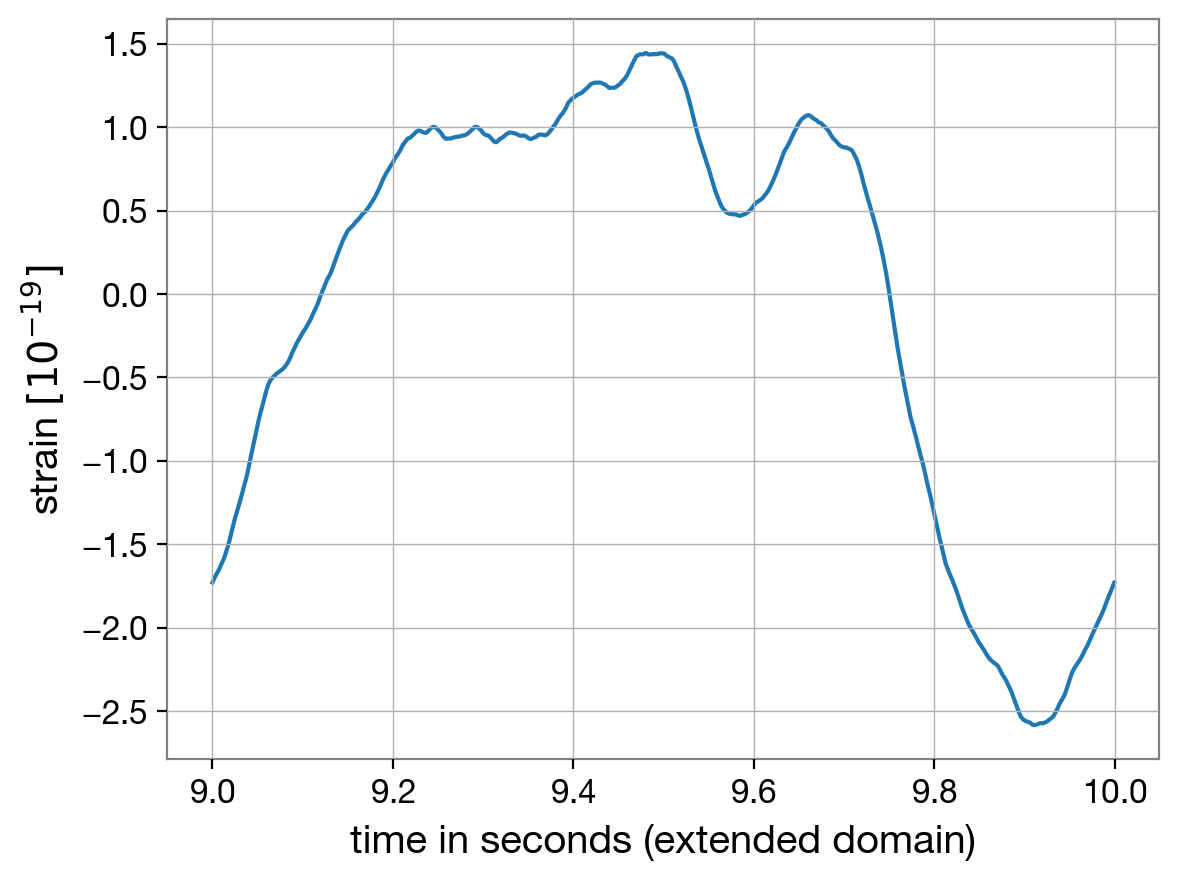

In [55]:
prior_samples = inference_scheme_2.plot_prior_samples(1, apply_adjoint_zp=False, )
print("living on domain: ", inference_scheme_2.domain)

Fluctuations should be:  0.8228646235506798
loglogavgslope should be:  -4.010295707290885  and y offset  0.06871036136732399
Which is indeed the process used to generate samples.


/var/folders/6s/zt639pwd3kg46kcb8b3t121r0000gp/T/ipykernel_86088/1806882894.py:33: RuntimeWarning: divide by zero encountered in log10
  plt.loglog(domains[0], 10**(linear(np.log10(domains[0]), -4, 0.257-1)), label="linear fit to this (shifted to see resemblance)")


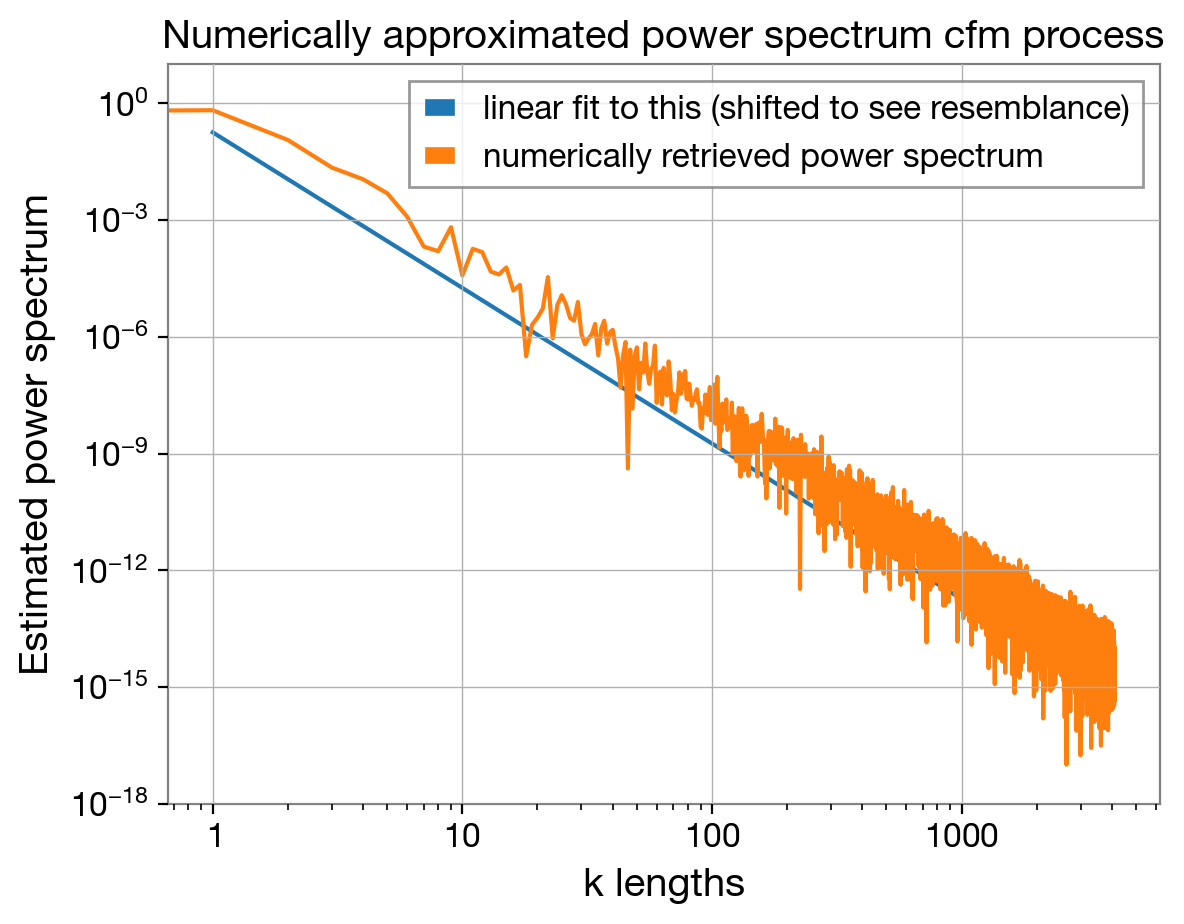

In [56]:
def power_analyze_my_field(field_to_analyze, custom_HT_operator):
    # note: custom_HT_operator(field_to_analyze) has units of svol * field_unit, so later svol needs to be divided out
    ps = ift.power_analyze(custom_HT_operator(field_to_analyze))
    return ps.domain[0].k_lengths, ps

def get_average_power_spectrum(sl_list, custom_HT_operator):
    ps_and_k_lengths = [power_analyze_my_field(field_sample, custom_HT_operator) for field_sample in sl_list]
    ps_list = [el[1].val for el in ps_and_k_lengths]
    k_len = [el[0] for el in ps_and_k_lengths]

    average_power_spectrum = np.mean(ps_list, axis=0)

    popt = curve_fit(linear, np.log10(k_len[0][1:]), np.log10(average_power_spectrum[1:]))

    print("Fluctuations should be: ", np.trapz(average_power_spectrum, k_len[0]))
    print("loglogavgslope should be: ", popt[0][0], " (and y intersection ", popt[0][1], " )")

    return k_len[0], average_power_spectrum  # return one k_length array assuming they are all the same

HT_2 = ift.HartleyOperator(inference_scheme_2.domain_ext)

power_spectra = [power_analyze_my_field(sl, HT_2)[1].val for sl in prior_samples]
domains = [power_analyze_my_field(sl, HT_2)[0] for sl in prior_samples]
mean_pow_spec_2 = np.mean(power_spectra, axis=0)

popt = curve_fit(linear, np.log10(domains[0][1:]), np.log10(mean_pow_spec_2[1:]))

print("Fluctuations should be: ", np.trapz(mean_pow_spec_2, domains[0]))
print("loglogavgslope should be: ", popt[0][0], " and y offset ", popt[0][1])

print("Which is indeed the process used to generate samples.")

plt.loglog(domains[0], 10**(linear(np.log10(domains[0]), -4, 0.257-1)), label="linear fit to this (shifted to see resemblance)")
plt.plot(domains[0], mean_pow_spec_2, label="numerically retrieved power spectrum")
plt.loglog()
plt.ylim(1e-18, 10)
plt.title("Numerically approximated power spectrum cfm process")
plt.xlabel("k lengths")
plt.ylabel("Estimated power spectrum")

plt.legend()


### Or, we do the same thing for the data itself actually. We expect a slightly different power spectrum here, since volume factors are different and the ZP operator also changes things I believe.

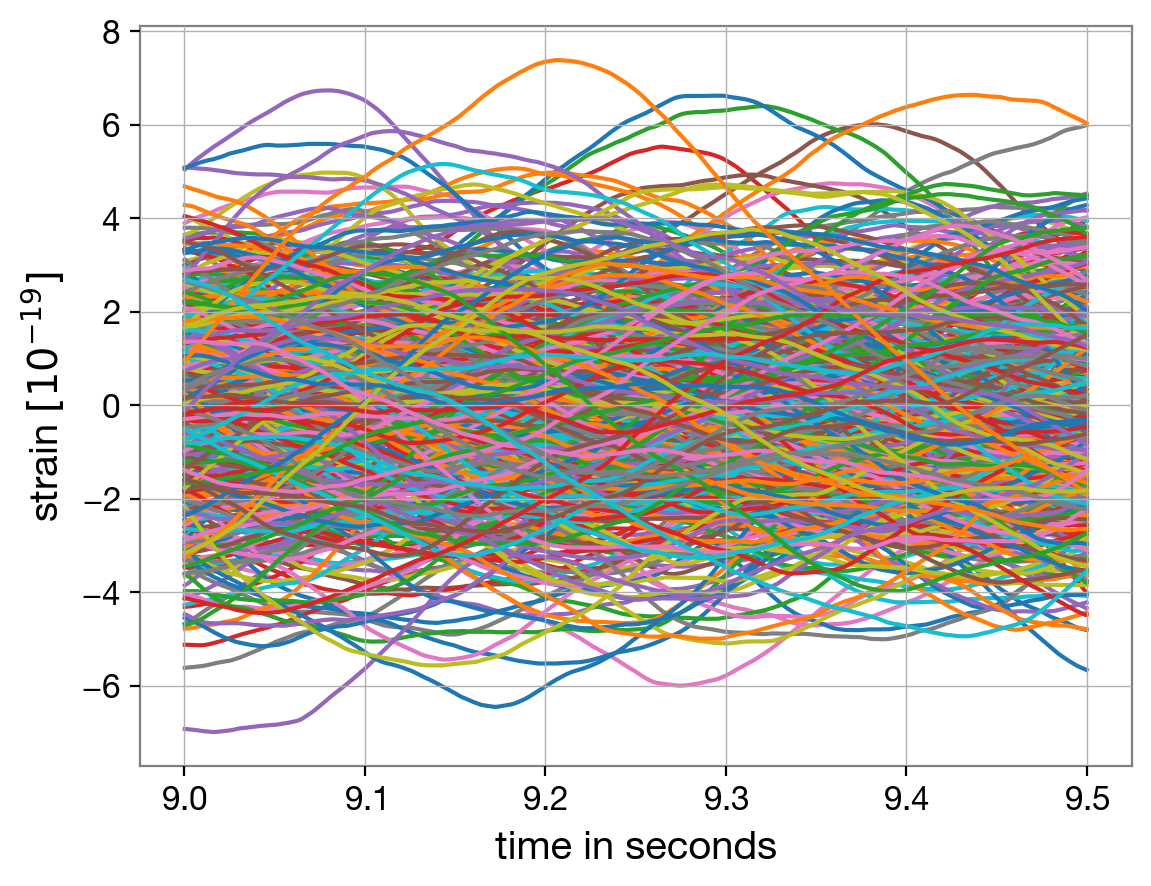

In [57]:
prior_data_samples = inference_scheme_2.plot_prior_samples(500, apply_adjoint_zp=True)  # not really `data samples` I defined them over an RG space such that the harmonic transform is well defined instead of an unstructured space but the difference between this and real data samples would be a simple mask so the power spectrum of this and the data should be identical in shape but the data power spectrum missing some support points

Fluctuations should be:  0.9566213141743568
loglogavgslope should be:  -1.8073252931375372  (and y intersection  -0.9270483175660961  )


/var/folders/6s/zt639pwd3kg46kcb8b3t121r0000gp/T/ipykernel_86088/2373653760.py:5: RuntimeWarning: divide by zero encountered in log10
  plt.loglog(k_len_data, 10**(linear(np.log10(k_len_data), -1.8, -0.94)), label="linear fit to this")


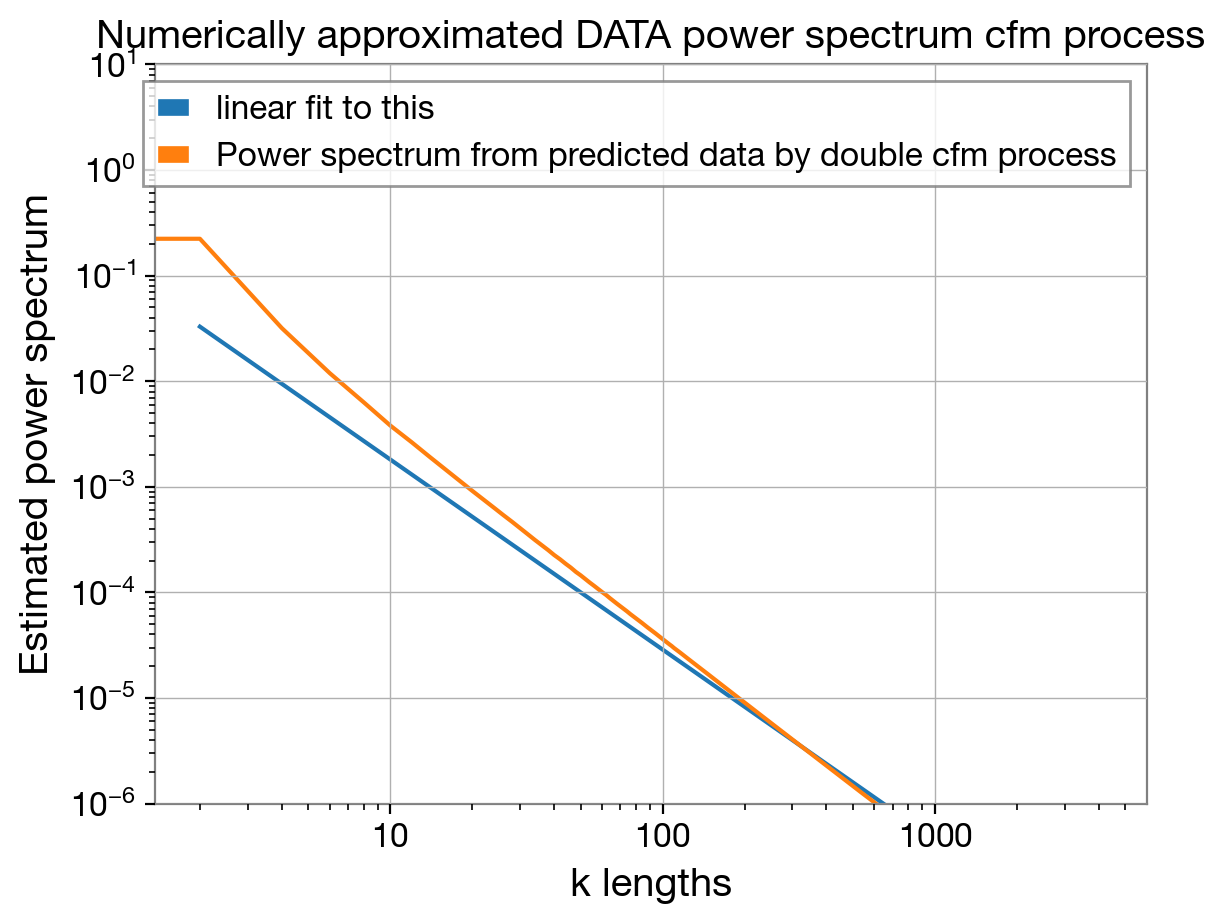

In [58]:

HT_small = ift.HartleyOperator(domain=inference_scheme_2.domain)

k_len_data, mean_pow_spec_data = get_average_power_spectrum(prior_data_samples, custom_HT_operator=HT_small)

plt.loglog(k_len_data, 10**(linear(np.log10(k_len_data), -1.8, -0.94)), label="linear fit to this")
plt.plot(k_len_data, mean_pow_spec_data, label="Power spectrum from predicted data by double cfm process")
plt.loglog()
plt.ylim(1e-6, 10)
plt.title("Numerically approximated DATA power spectrum cfm process")
plt.xlabel("k lengths")
plt.ylabel("Estimated power spectrum")
plt.legend()

### As you can see, it slightly bends a bit! So this is behaviour we would also expect from fourier transforming real data
Note: The linear fit looks really bad?

### Doing the same for the double cfm model

In [59]:

sample_list_double_cfm = []

for _ in range(500):

    s_low_frequency = ift.VerySimpleCorrelatedField(inference_scheme.domain_ext, fluctuations=myDict["low_frequency_fluctuations"], loglogavgslope=myDict["low_frequency_loglogavgslope"], override_with_exact_values=True)

    s_high_frequency = ift.VerySimpleCorrelatedField(inference_scheme.domain_ext, fluctuations=myDict["high_frequency_fluctuations"],loglogavgslope=myDict["high_frequency_loglogavgslope"], override_with_exact_values=True)

    sample_list_double_cfm.append(s_low_frequency+s_high_frequency)


Fluctuations should be:  1.8495053649085536
loglogavgslope should be:  -1.0565351699297496  (and y intersection  -1.753638549590287  )


Text(0, 0.5, 'Estimated power spectrum')

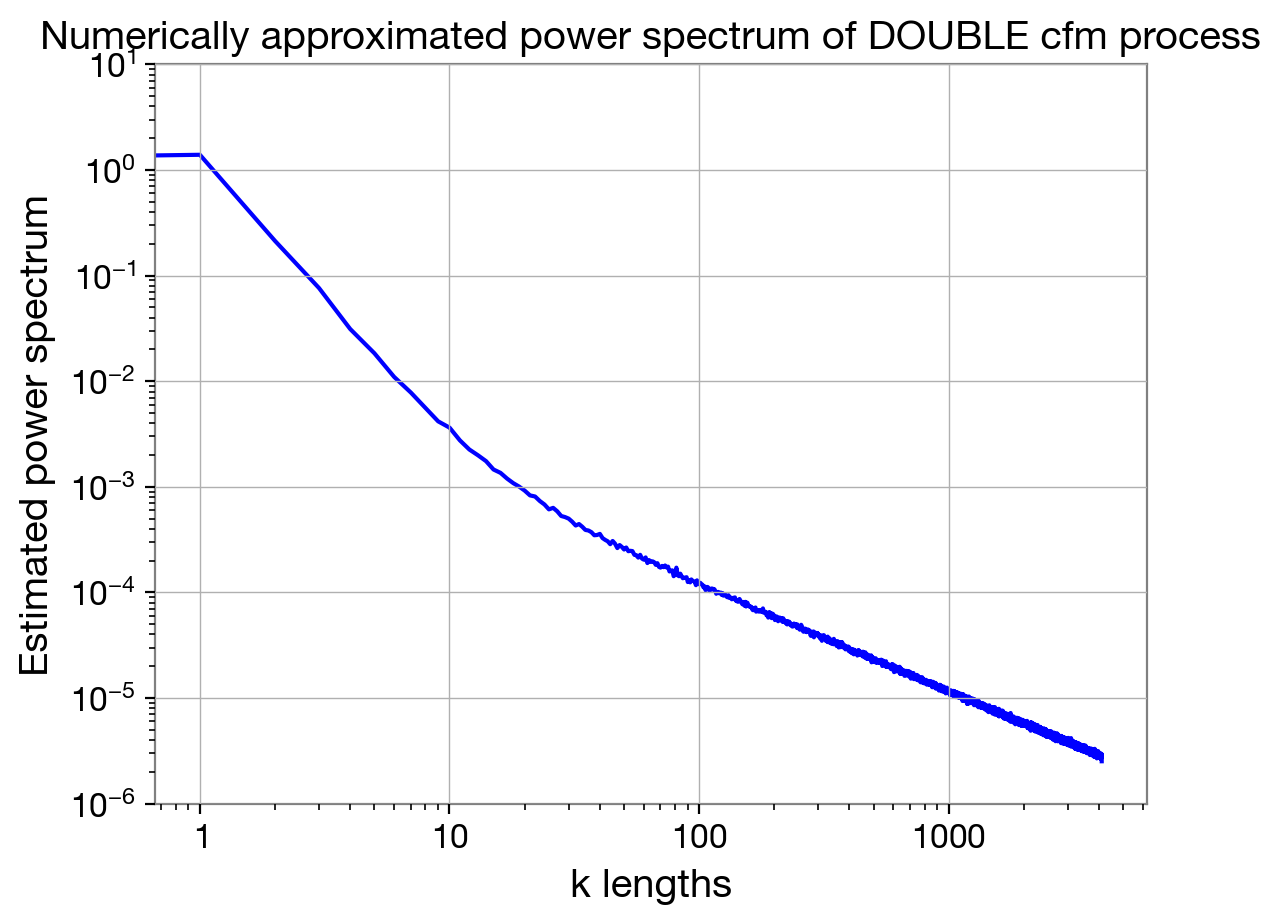

In [60]:
tmp = get_average_power_spectrum(sample_list_double_cfm, HT_2)
plt.plot(tmp[0], tmp[1], "b-")
plt.loglog()
plt.ylim(1e-6,10)
plt.title("Numerically approximated power spectrum of DOUBLE cfm process")
plt.xlabel("k lengths")
plt.ylabel("Estimated power spectrum")

In the last plot we actually see that this isnt just the sum of two lines, meaning that there is cross-correlation between the high and low frequency components of the cfm models. If they were independent, the power spectrum would be:

$$<s_k s_q^{\ast}>=<(s_{\text{low freq}}+s_{\text{high freq}})_k(s_{\text{low freq}}+s_{\text{high freq}})_q^{\ast}> = 2\pi \delta(k-q) [P_{s, \text{low freq}}+P_{s, \text{high freq}}] + 2\cdot <s_{\text{low freq},k}s_{\text{low freq},q}^{\ast}>,$$

where we WOULD see a line if the latter cross-correlation would have dropped out. So in this model, the data couples these two processes.

Finally, our power spectrum is a good model, if we directly compare with the data power spectrum by fourier transforming a strip taking the amplitude and repeating over multiple data strips and subsequently compare.

First, we also get the "data power spectrum" predicted by the double cfm model.

In [61]:

sample_list_double_cfm_data = []

for _ in range(500):

    s_low_frequency = ift.VerySimpleCorrelatedField(inference_scheme.domain_ext, fluctuations=myDict["low_frequency_fluctuations"], loglogavgslope=myDict["low_frequency_loglogavgslope"], override_with_exact_values=True)

    s_high_frequency = ift.VerySimpleCorrelatedField(inference_scheme.domain_ext, fluctuations=myDict["high_frequency_fluctuations"],loglogavgslope=myDict["high_frequency_loglogavgslope"], override_with_exact_values=True)

    sample_list_double_cfm_data.append(inference_scheme_double_model.X.adjoint(s_low_frequency+s_high_frequency))


Fluctuations should be:  0.9777910486256857
loglogavgslope should be:  -1.15682892564811  (and y intersection  -1.7035579776397456  )


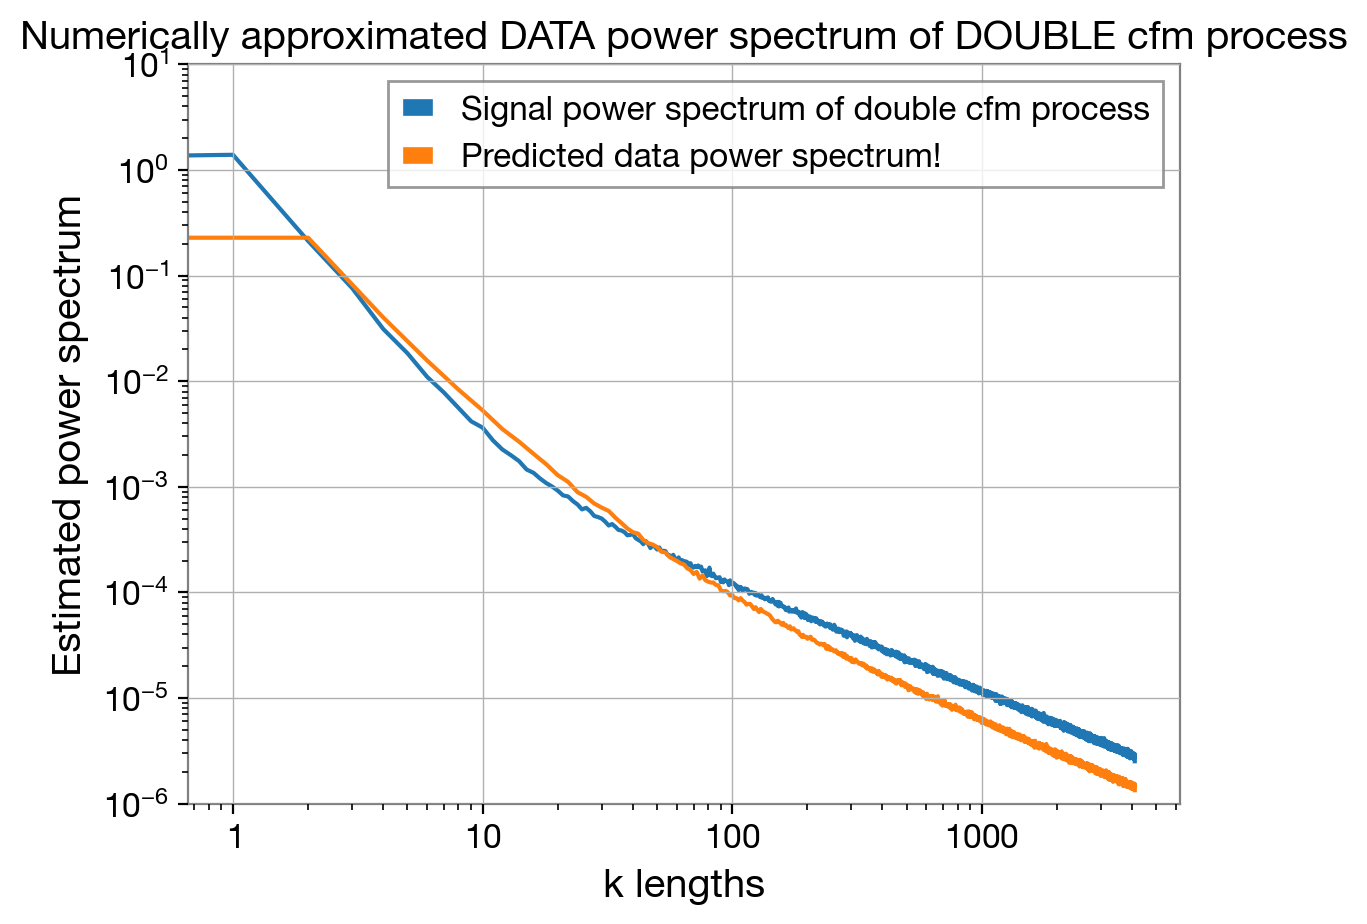

In [62]:
tmp3 = get_average_power_spectrum(sample_list_double_cfm_data, HT_small)
plt.plot(tmp[0], tmp[1], label="Signal power spectrum of double cfm process")
plt.plot(tmp3[0], tmp3[1], label="Predicted data power spectrum!")
plt.loglog()
plt.ylim(1e-6,10)
plt.title("Numerically approximated DATA power spectrum of DOUBLE cfm process")
plt.xlabel("k lengths")
plt.ylabel("Estimated power spectrum")
plt.legend()

## Taking the fourier transform of the data directly in multiple windows

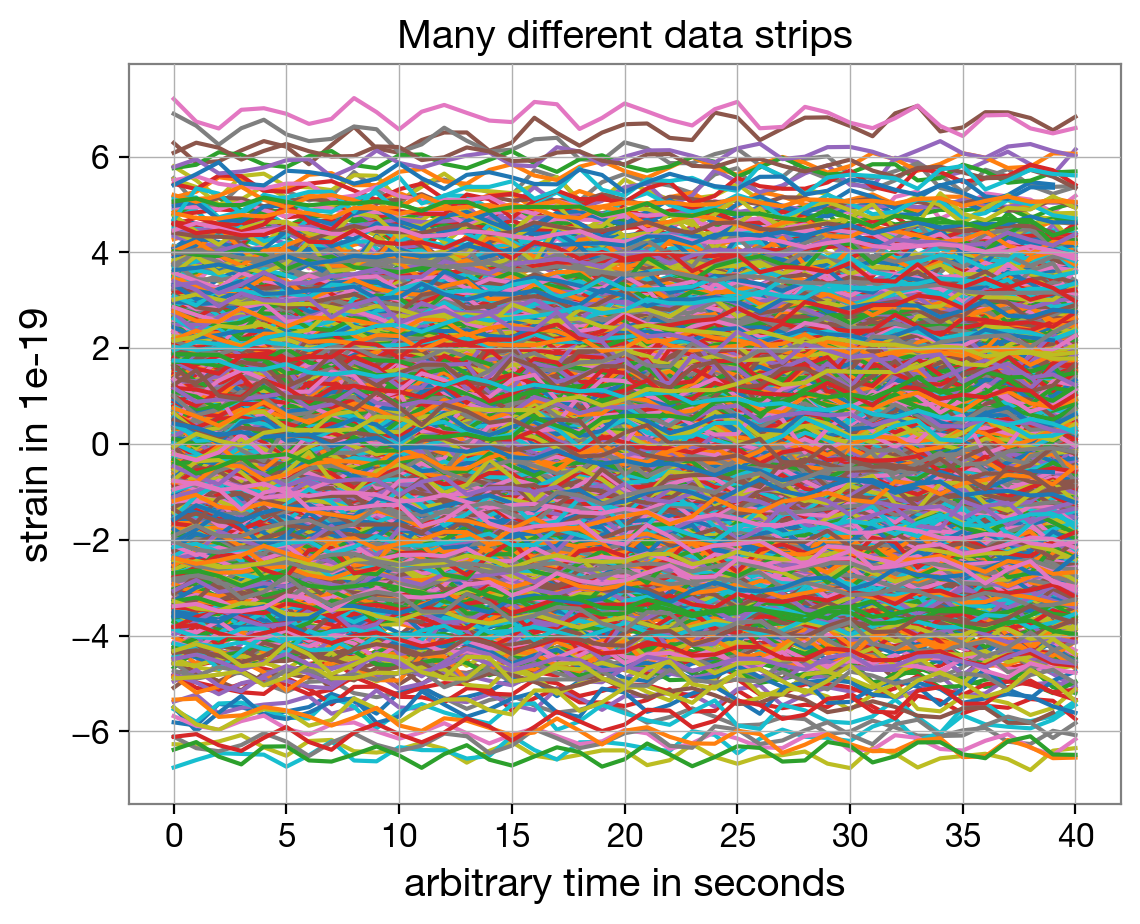

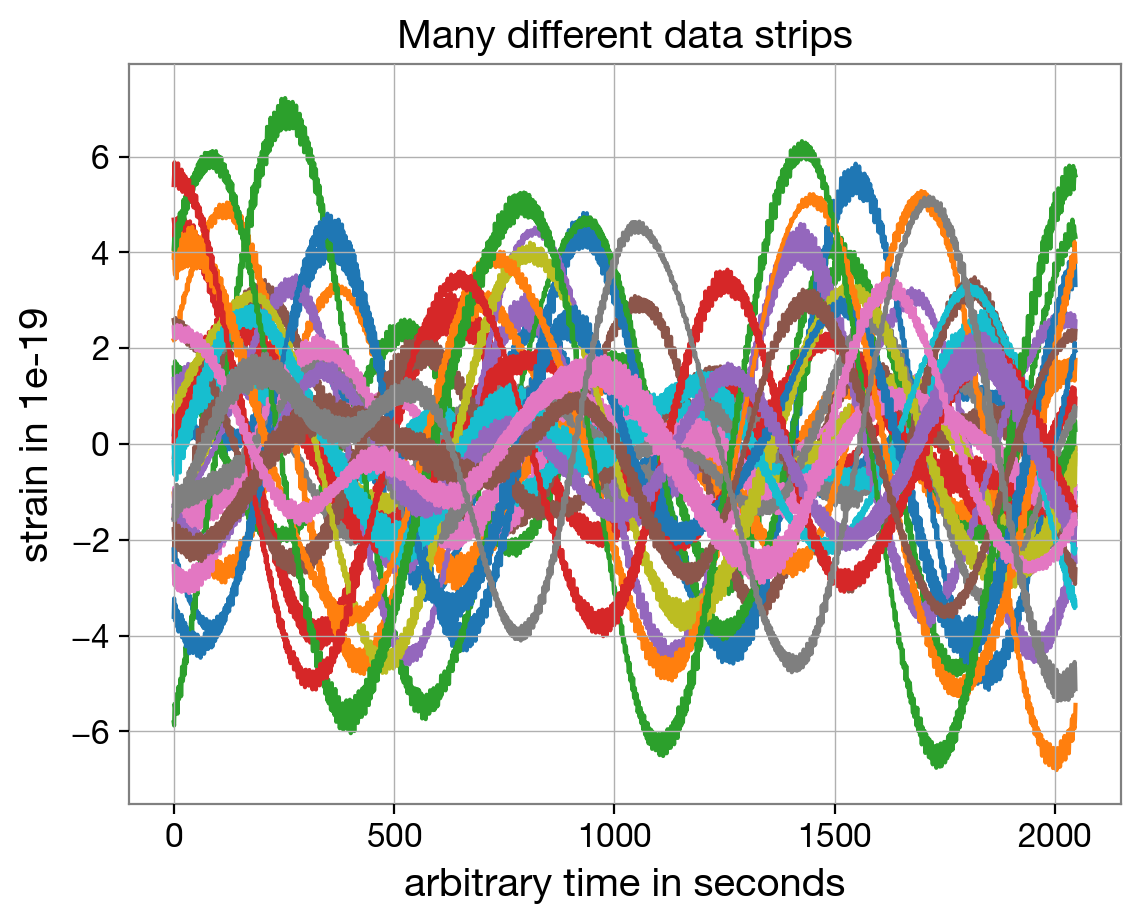

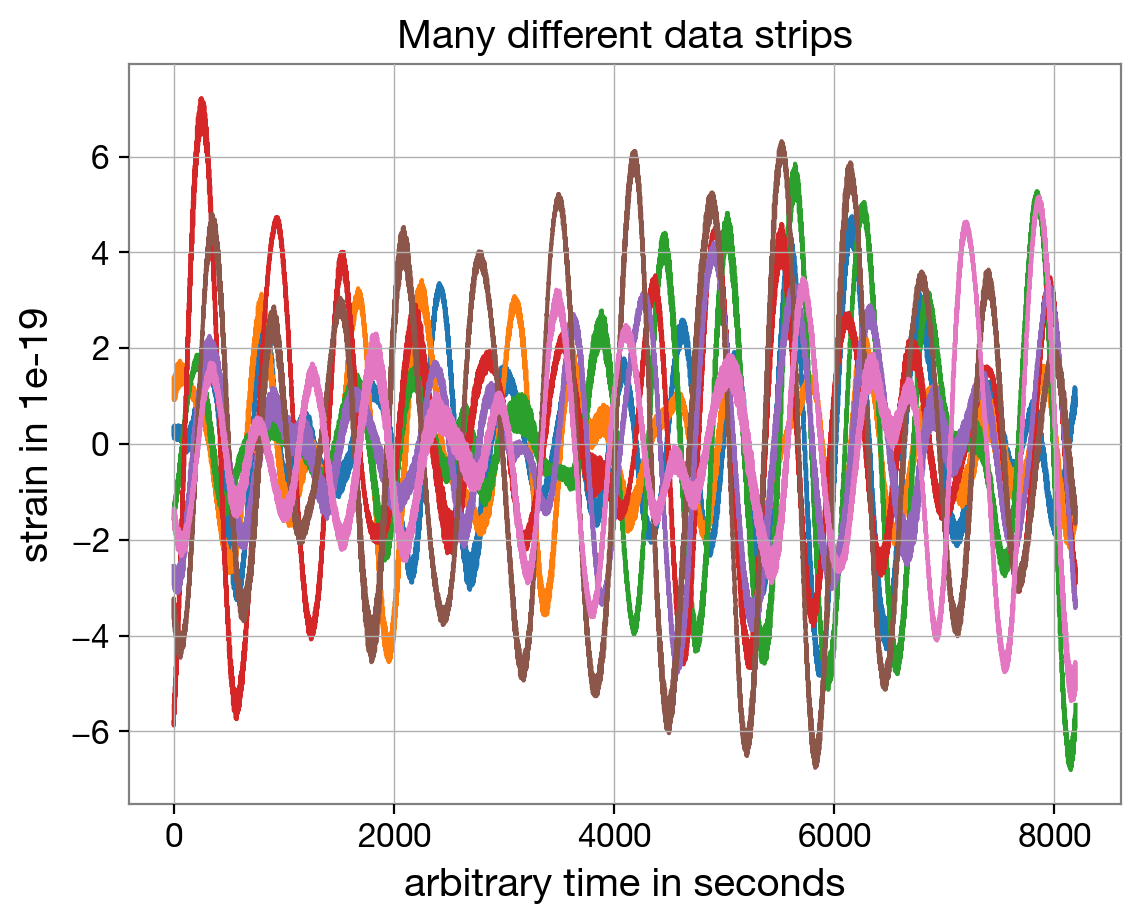

In [63]:
# Lets first get data in different windows
def create_windows(start, end, dt):
    edges = np.arange(start, end, dt)
    return [(round(time, 10), round(time + dt, 10)) for time in edges if time + dt <= end]

def get_strips_of_data(my_dt):

    new_time = np.array(strain.times) - center
    new_time += np.abs(min(new_time))

    # my_dt = 0.01
    # my_dt = 0.5
    # my_dt = 2
    my_start = 1
    my_end = 15

    windows = create_windows(my_start, my_end, my_dt)

    data_fields = []
    data_RG_spaces=[]
    data_harmonic_transforms = []

    for window in windows:
        new_d = np.array(strain.value)
        new_idcs = np.where( (window[0]<new_time) & (new_time<=window[1]) )
        new_d = new_d[new_idcs]

        n_dtp = len(new_idcs[0])
        data_RG_space = ift.RGSpace(shape=(n_dtp,), distances=my_dt/n_dtp)
        HT_data = ift.HartleyOperator(domain=data_RG_space)

        new_d *= 1e19

        data_fields.append(ift.Field(ift.DomainTuple.make(data_RG_space), val=new_d))  # use RGspace as domain for HT to work
        data_RG_spaces.append(data_RG_space)
        data_harmonic_transforms.append(HT_data)

    i=0
    for data_field in data_fields:
        i += 1
        plt.plot(data_field.val)

    plt.title("Many different data strips")
    plt.xlabel("arbitrary time in seconds")
    plt.ylabel("strain in 1e-19")
    plt.show()

    return data_RG_spaces, data_fields, data_harmonic_transforms

_, df1, ht1 = get_strips_of_data(0.01)
_, df2, ht2 = get_strips_of_data(0.5)
_, df3, ht3 = get_strips_of_data(2)

We expect the pixelwise standard deviation of the fields in the large data window to be:  1.6851973129774516 8192 7


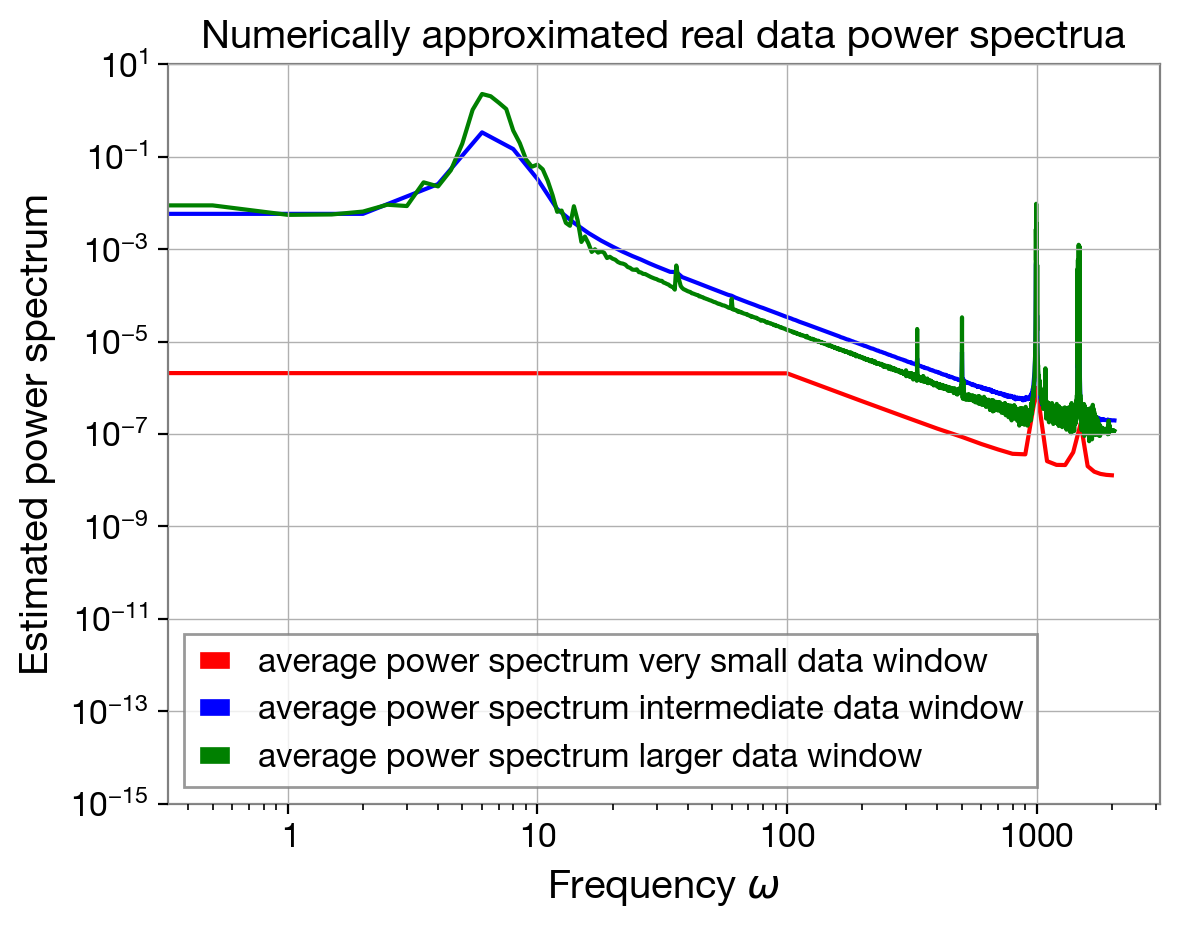

In [64]:

collect_all = [(df1, ht1, "red", "very small data window"), (df2, ht2, "blue", "intermediate data window"), (df3, ht3, "green", "larger data window")]

pixelwise_standard_deviation_of_df3_fields = np.std([df.val for df in df3], axis=0)
print("We expect the pixelwise standard deviation of the fields in the large data window to be: ", np.mean(pixelwise_standard_deviation_of_df3_fields), len(pixelwise_standard_deviation_of_df3_fields), len(df3))

for strip in collect_all:

    collect_power = []
    collect_k_len = []

    data_fields = strip[0]
    data_harmonic_transforms = strip[1]
    color = strip[2]
    info = strip[3]

    for idx, fld in enumerate(data_fields):
        tmp5 = power_analyze_my_field(fld, data_harmonic_transforms[idx])
        collect_power.append(tmp5[1].val)
        collect_k_len.append(tmp5[0])
        plt.plot(tmp5[0], tmp5[1].val, alpha=0)

    plt.plot(collect_k_len[0], np.mean(collect_power, axis=0), color=color, label=f"average power spectrum {info}")
    plt.loglog()
    plt.ylim(1e-15, 10)
    plt.title("Numerically approximated real data power spectra")
    plt.xlabel(r"Frequency $\omega$")
    plt.ylabel("Estimated power spectrum")
    plt.legend()

plt.show()

In [65]:
# # this cell is broken
#
# tmp4 = get_average_power_spectrum(data_fields, HT_data)
# plt.plot(tmp[0], tmp[1], label="Signal power spectrum of double cfm process")
# plt.plot(tmp3[0], tmp3[1], label="Predicted data power spectrum!")
# plt.plot(tmp4[0], tmp4[1], label="Actual average data power spectrum")
# plt.loglog()
# plt.ylim(1e-10,10)
# plt.title("Numerically approximated DATA power spectrum of DOUBLE cfm process")
# plt.xlabel("k lengths")
# plt.ylabel("Estimated power spectrum")
# plt.legend()

### Conclusions

- Simply fitting a correlated field to the noise with fluct and loglogavgslope misses interesting feature in the noise power spectrum
- The noise power spectrum from the data itself depends on the length of the chosen window / data strip
- Note that, we're making a huge error by fourier transforming the data in simple cut-off window since the data NEEDS to be periodic for us to actually Fourier-Transform. So we need to be smarter about our windows ("spectral leakage"?)

So, my next approach will be to:


1. Window shape: Use a tapering window (like Hann or Hamming) to reduce edge effects instead of hard periodic boundaries, unless the data truly is periodic.
2. Window length: Make windows as long as possible to improve frequency resolution and reduce variance.
3. Overlap: Use overlapping windows to increase the number of independent estimates without needing more data.
4. Average spectra: Compute and average the power spectra across windows to reduce noise (like in Welch's method).

Just out of curiosity, I want to see what it looks like if I create signal realization based on one of the above data power spectra

In [66]:

final_ps_fields = []
final_ps = []
final_ks = []


for fld, ht in zip(df3, ht3):
    tmp6 = power_analyze_my_field(fld, ht)
    final_ps.append(tmp6[1].val)
    final_ps_fields.append(tmp6[1])
    final_ks.append(tmp6[0])

[]

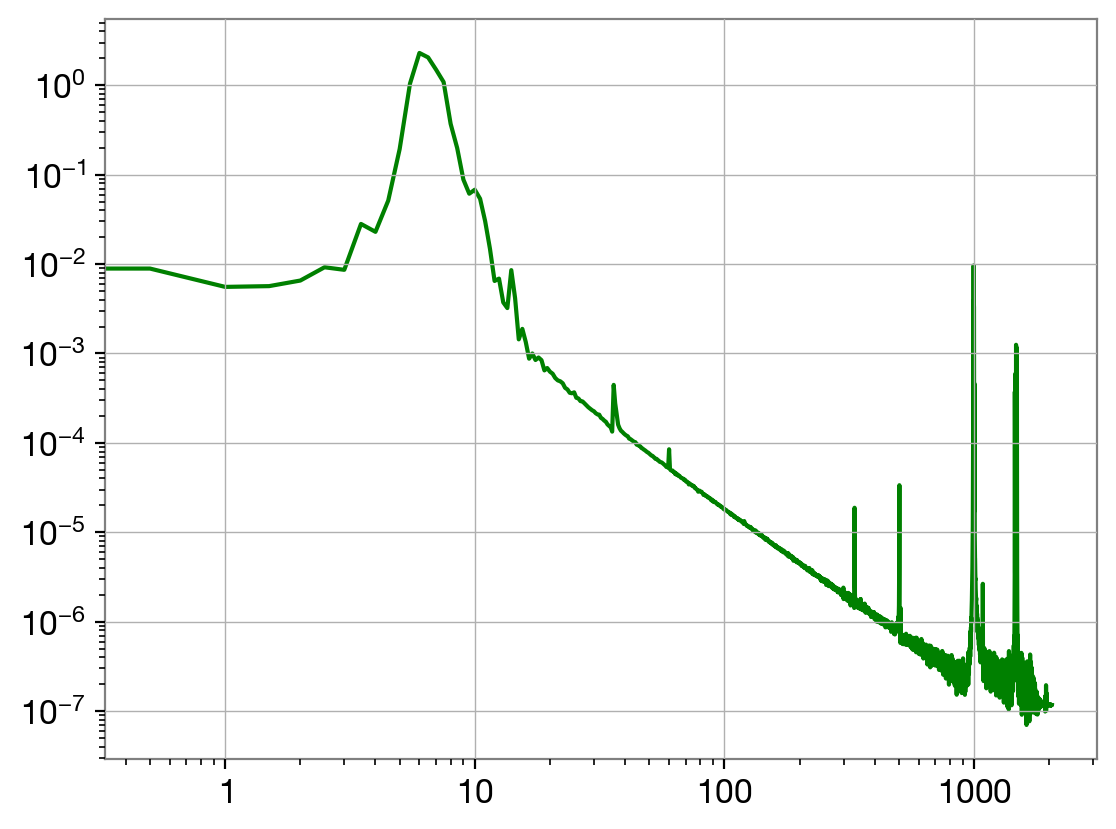

In [67]:
final_mean_ps = np.mean(final_ps, axis=0)
final_mean_ps_field = ift.Field(final_ps_fields[0].domain, val=final_mean_ps)
final_mean_ps_field_sqrt = ift.Field(final_ps_fields[0].domain, val=np.sqrt(final_mean_ps))
plt.plot(final_ks[0], final_mean_ps, "g-")
plt.loglog()

In [68]:

final_mean_ps_czm = np.mean(final_ps, axis=0)

custom_zero_mode = 3
# final_mean_ps_czm[0] = custom_zero_mode

final_mean_ps_field_czm = ift.Field(final_ps_fields[0].domain, val=final_mean_ps_czm)  # custom zero mode
final_mean_ps_field_sqrt_czm = ift.Field(final_ps_fields[0].domain, val=np.sqrt(final_mean_ps_czm))

myN_fourier = ift.create_power_operator(domain=ht3[0].target, power_spectrum=final_mean_ps_field_czm)
myN_fourier_sqrt = ift.create_power_operator(domain=ht3[0].target, power_spectrum=final_mean_ps_field_sqrt_czm)

print("\nNote that the power spectrum is of length ", len(final_mean_ps), ", but the create power operator reconstructs the negative frequencies to get 2*(n-1): ", 2*(len(final_mean_ps)-1), len(myN_fourier_sqrt._ldiag), "\n")

print("myN_fourier_sqrt ", myN_fourier_sqrt._ldiag)
print("vs my original full power spectrum: ", final_mean_ps_czm)
print("myN_fourier ", myN_fourier._ldiag)

N_real = ift.SandwichOperator.make(bun=ht3[0], cheese=myN_fourier, sampling_dtype=np.float64)
N_real_sqrt = ift.SandwichOperator.make(bun=ht3[0], cheese=myN_fourier_sqrt, sampling_dtype=np.float64)

num_of_datapoints = N_real.domain.shape[0]
print("num_of_datapoints from inverse fourier transform : ", num_of_datapoints, " num of actual datapoints: ", df3[0].shape)


Note that the power spectrum is of length  4097 , but the create power operator reconstructs the negative frequencies to get 2*(n-1):  8192 8192 

myN_fourier_sqrt  [0.1810121  0.09437714 0.07454678 ... 0.07527848 0.07454678
 0.09437714]
vs my original full power spectrum:  [3.27653786e-02 8.90704511e-03 5.55722175e-03 ... 1.16856352e-07
 1.16600041e-07 1.16897706e-07]
myN_fourier  [0.03276538 0.00890705 0.00555722 ... 0.00566685 0.00555722
 0.00890705]
num_of_datapoints from inverse fourier transform :  8192  num of actual datapoints:  (8192,)


the zero mode of p_n is 0.03276537856548299  at k lengths  0.0




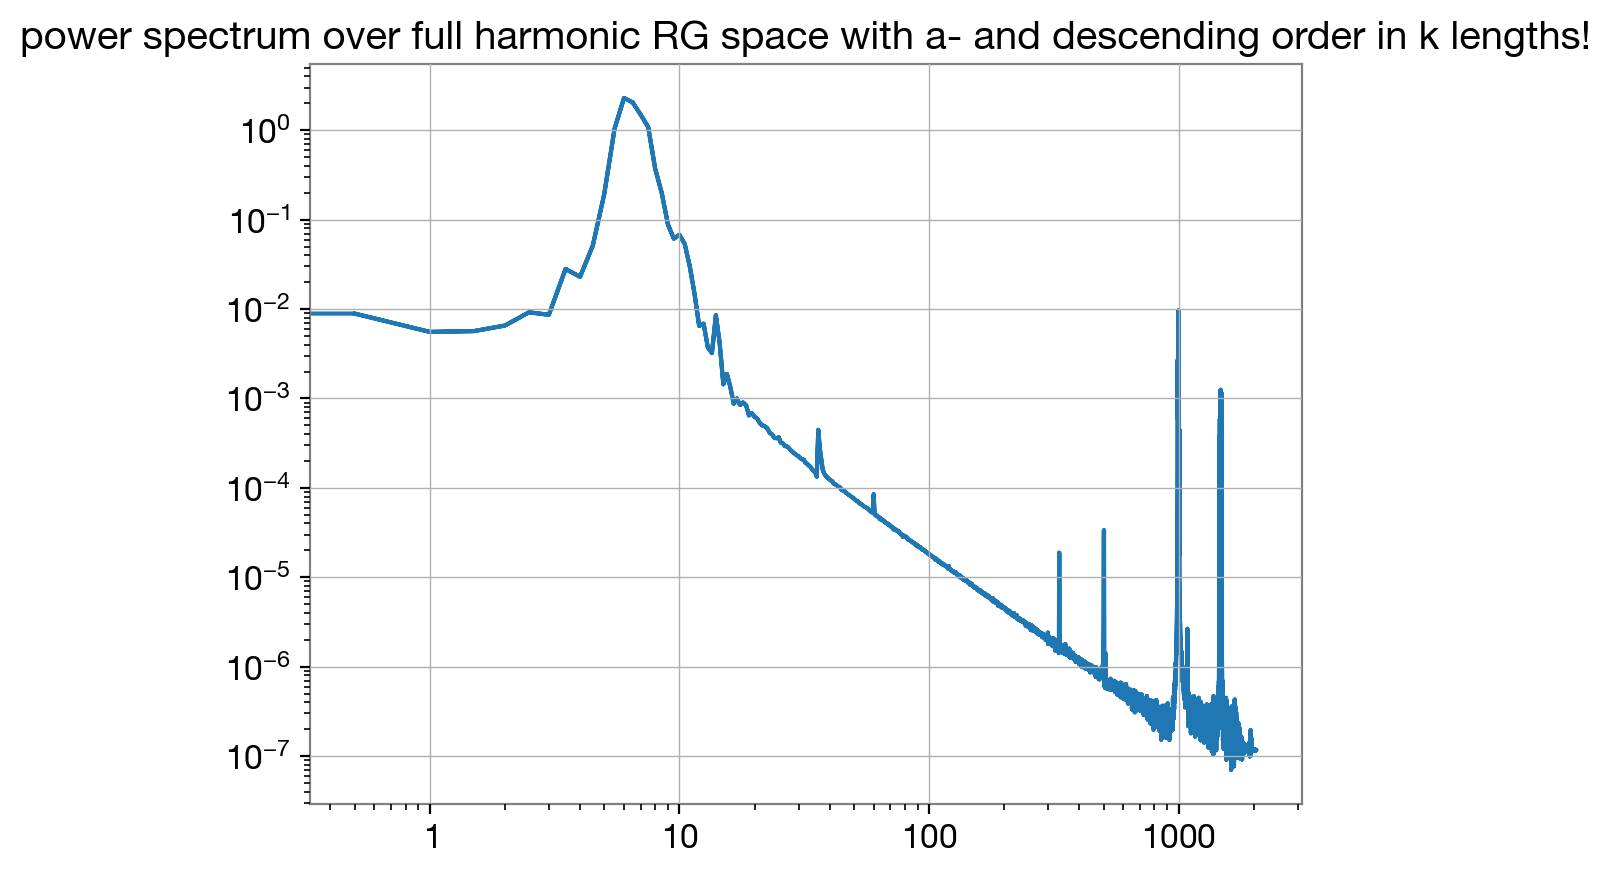

svol  (0.000244140625,)
sqrt(fluctuation variance) from this power spectrum:  170.5594702229367  which is to be expected! So why dont I see these in the samples I'm drawing? 8192
Note that in order to compute fluctuations a reordering of k lengths was necessary.


standard deviation of mean fields of realizations:  0.0


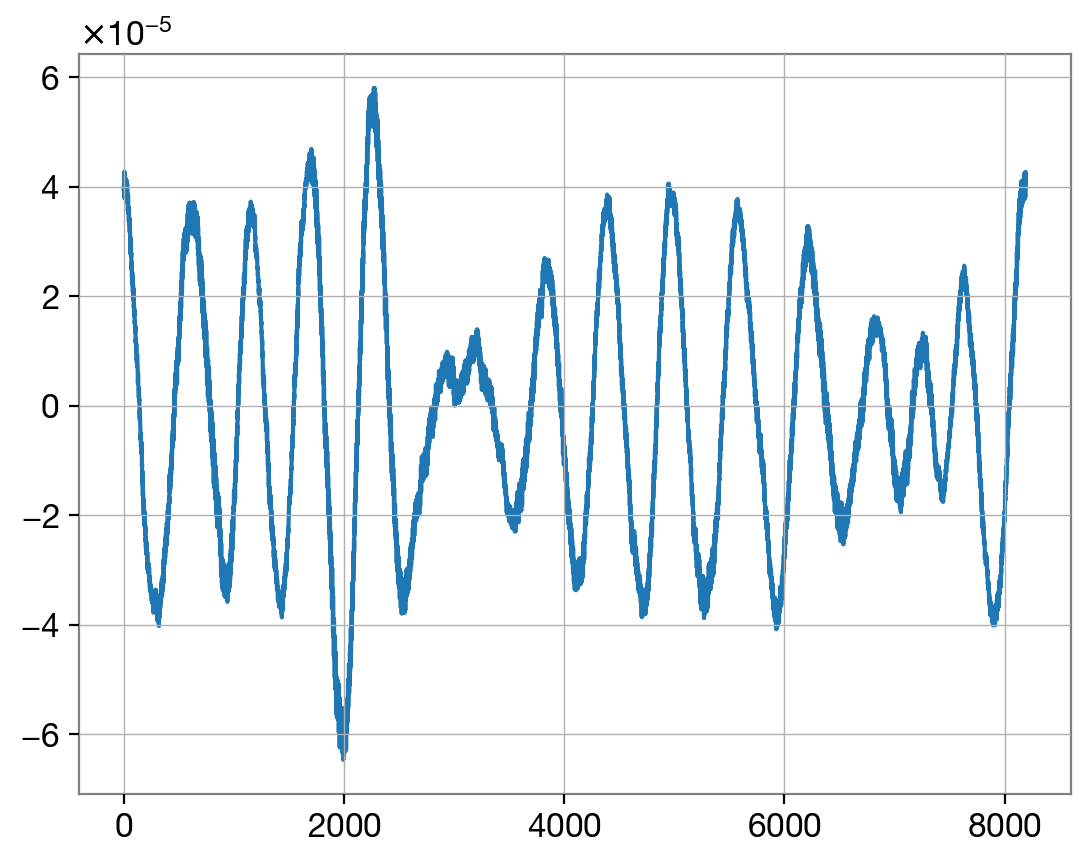

In [69]:

print("the zero mode of p_n is", final_mean_ps_field_czm.val[0], " at k lengths ", final_mean_ps_field_czm.domain[0].k_lengths[0])

print("\n")
k_lengths_3 = myN_fourier.domain[0].get_k_length_array()
plt.plot(k_lengths_3.val, myN_fourier._ldiag)
plt.loglog()
plt.title("power spectrum over full harmonic RG space with a- and descending order in k lengths!")
plt.show()

s_vol = ht3[0].domain[0].distances

print("svol ", s_vol)

sorted_indices = np.argsort(k_lengths_3.val)
x_sorted = k_lengths_3.val[sorted_indices]
y_sorted = myN_fourier._ldiag[sorted_indices]

print("sqrt(fluctuation variance) from this power spectrum: ", np.sqrt(np.trapz(y_sorted**2/s_vol, x_sorted)), " which is to be expected! So why dont I see these in the samples I'm drawing?", len(x_sorted))
print("Note that in order to compute fluctuations a reordering of k lengths was necessary.")
print("\n")

means = []

for _ in range(1):

    random_xi = np.random.normal(size=num_of_datapoints, scale=1, loc=0)
    # sample = N_real_sqrt(ift.Field(N_real_sqrt.domain, val=random_xi))  # same same

    sample = N_real_sqrt(ift.Field.from_random(domain=N_real_sqrt.domain, random_type="normal"))

    means.append(np.mean(sample.val))

    plt.plot(sample.val)

print("standard deviation of mean fields of realizations: ", np.std(means))

plt.show()

In [70]:
# Does the zero mode in fourier space behave as expected?
zm_collection = []

print("myN_fourier_sqrt power spectrum: ", myN_fourier_sqrt._ldiag)

for _ in range(5000):

    xi = np.random.normal(size=myN_fourier_sqrt.domain.shape[0], scale=1, loc=0)
    phi_fourier = myN_fourier_sqrt(ift.Field(myN_fourier_sqrt.domain, val=xi))
    # phi_fourier = myN_fourier_sqrt(ift.Field.from_random(domain=myN_fourier_sqrt.domain, random_type="normal"))  # a variable distributed according to the power spectrum in fourier space; I.e. its first entry should be a random variable of variance P(0)!
    zm = phi_fourier.val[0]
    zm_collection.append(zm)

myN_fourier_sqrt power spectrum:  [0.1810121  0.09437714 0.07454678 ... 0.07527848 0.07454678
 0.09437714]


standard deviation of distribution should actually be  0.18101209508064092  and is  0.18168629770645162


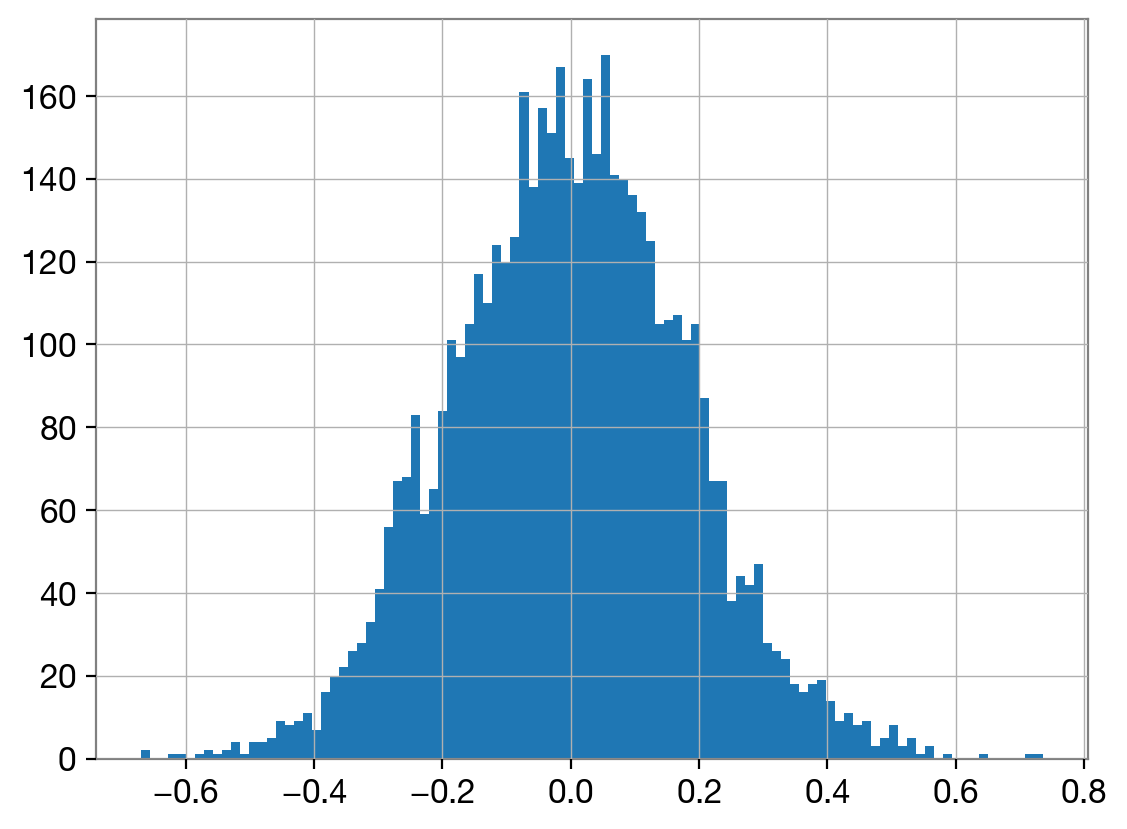

In [71]:
hist = plt.hist(zm_collection, bins=100)
print("standard deviation of distribution should actually be ", np.sqrt(final_mean_ps_field_czm.val[0]), " and is ", np.std(zm_collection))

### Conclusion:

In fourier space, the zero mode behaves as expected! Why is then the scale of my field realizations incorrect?


8192


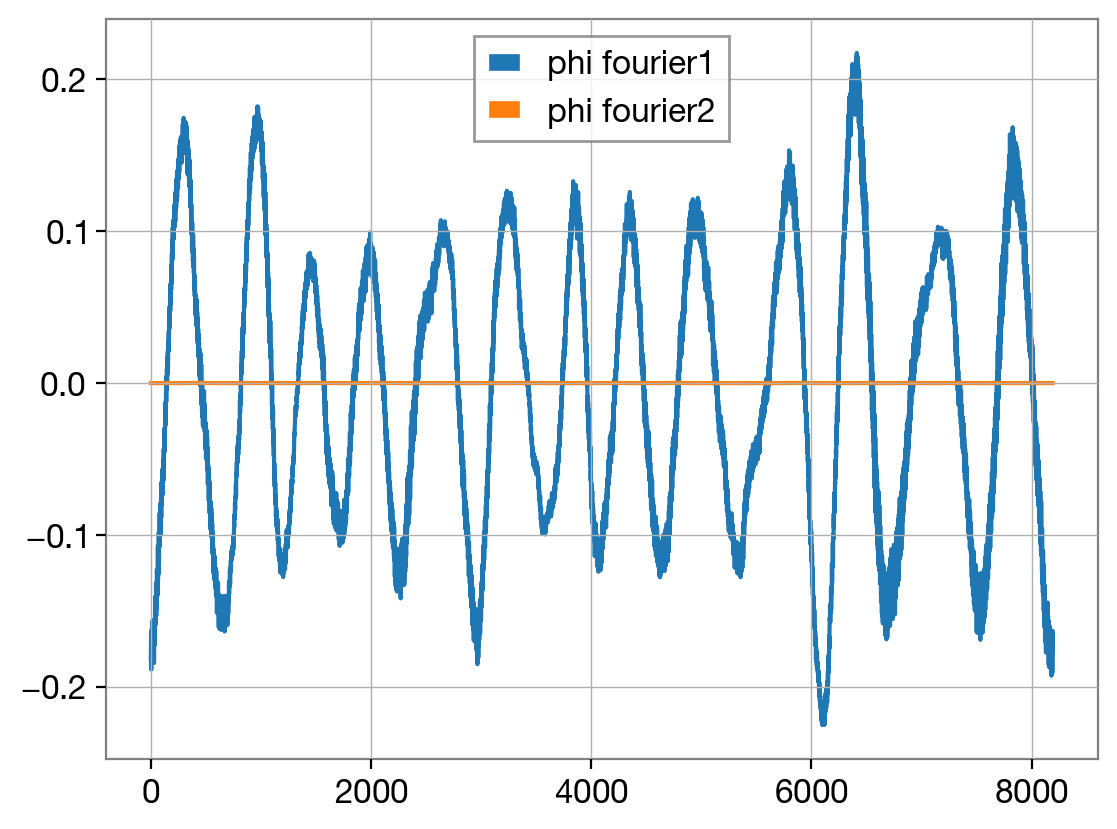

In [72]:

vol_of_real_space = myN_fourier_sqrt.domain.shape[0]
print(vol_of_real_space)

harmonic_transform_normalized = lambda arg: ht3[0](arg) / np.sqrt(vol_of_real_space)
harmonic_transform_normalized_adjoint = lambda arg: ht3[0].adjoint(arg) * np.sqrt(vol_of_real_space)


for _ in range(1):

    xi = np.random.normal(size=myN_fourier_sqrt.domain.shape[0], scale=1, loc=0)

    harmonic_transform = ht3[0]
    harmonic_domain = harmonic_transform.target
    real_domain = harmonic_transform.domain

    xi_fourier1 = ift.Field(harmonic_domain, val=xi)
    xi_fourier2 = harmonic_transform_normalized(ift.Field(real_domain, val=xi))

    phi_fourier1 = myN_fourier_sqrt(xi_fourier1)  # xi lives directly on harmonic space
    phi_fourier2 = myN_fourier_sqrt(xi_fourier2)  # xi lives in real space and is first transformed. Will these two samples have the same scale?

    plt.plot(harmonic_transform_normalized_adjoint(phi_fourier1).val, label="phi fourier1")
    plt.plot(harmonic_transform_normalized_adjoint(phi_fourier2).val, label="phi fourier2")
    plt.legend()


## Normalization of the Hartley-Operator

Generally, HT.adjoint(HT(field)) = field * num of pixels of the field

Furthermore, NIFTy internally applies the distances (RGSpace.scalar_dvol) to each call of HT and HT.adjoint for some reason. So, we should divide by $$norm=s_{vol}^2*N$$ when doing a Sandwhich operation involving harmonic transforms.


volume of harmonic space  0.5
volume of real space  0.000244140625  vs distances:  (0.000244140625,)


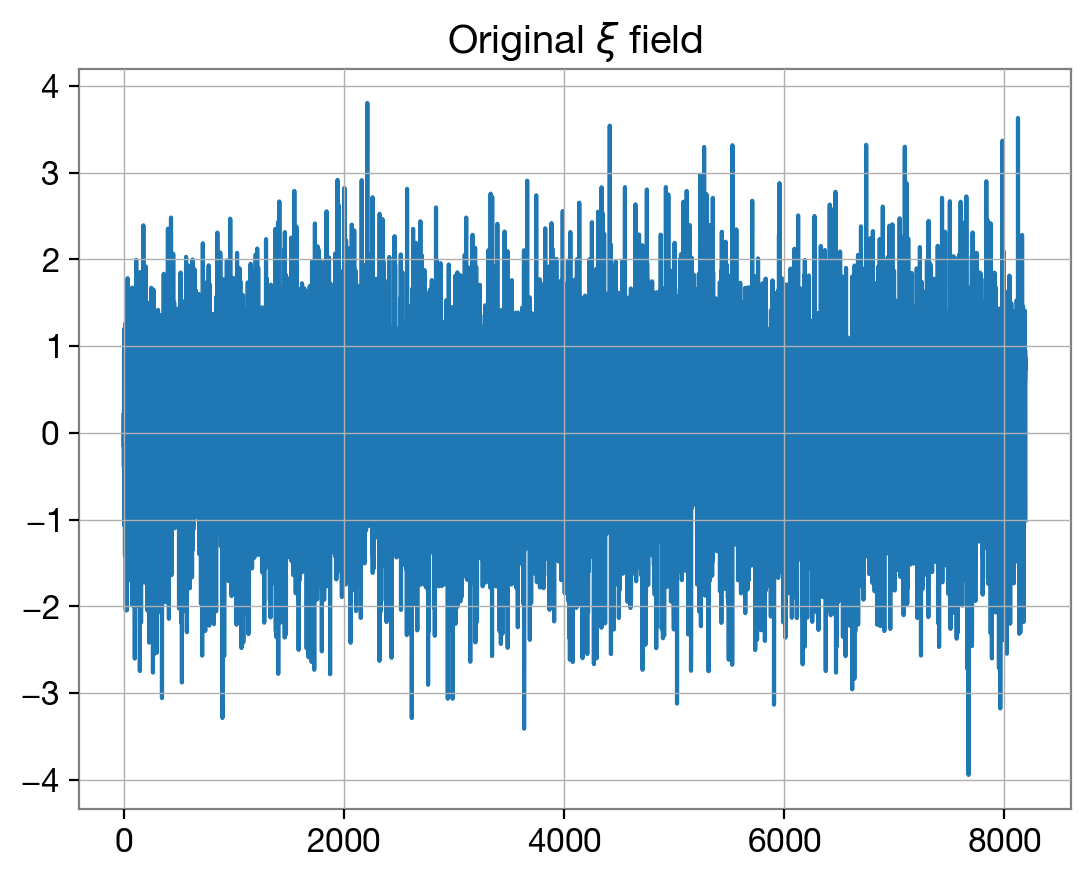

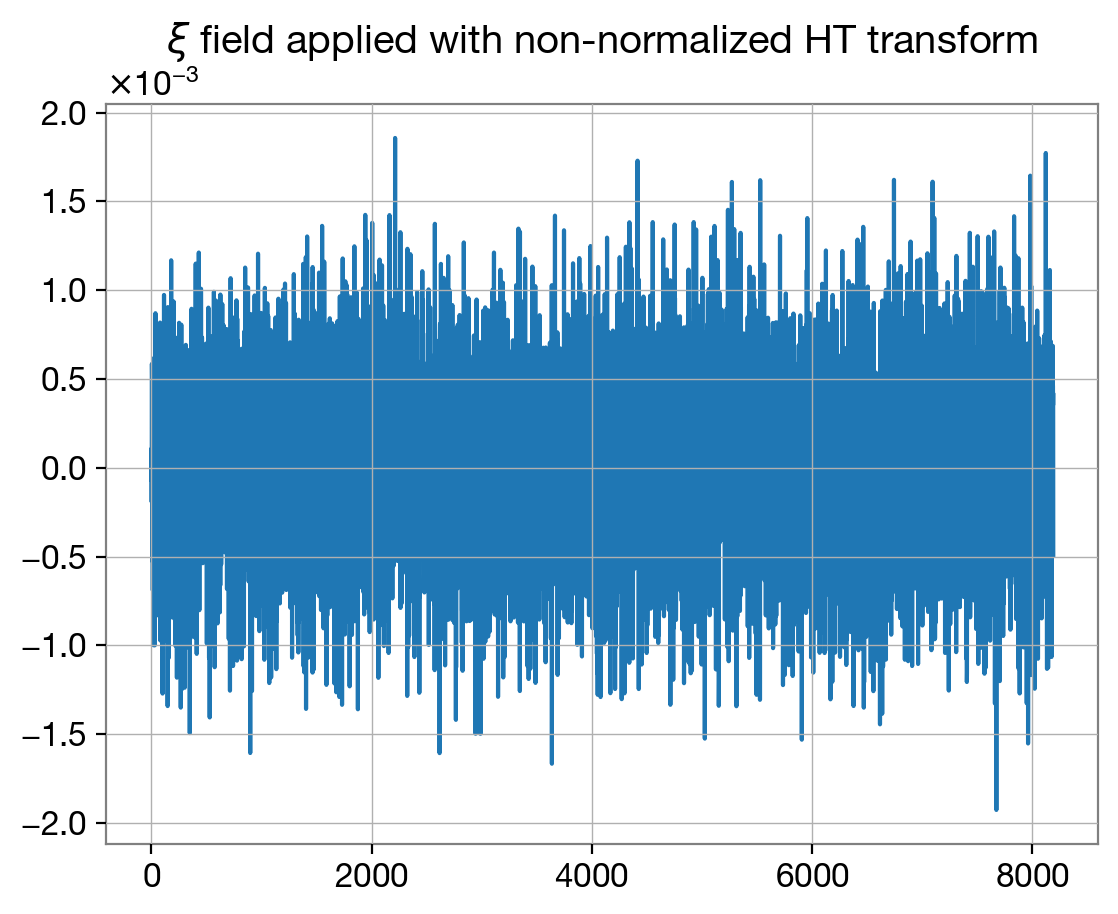

step 1 
step 2 


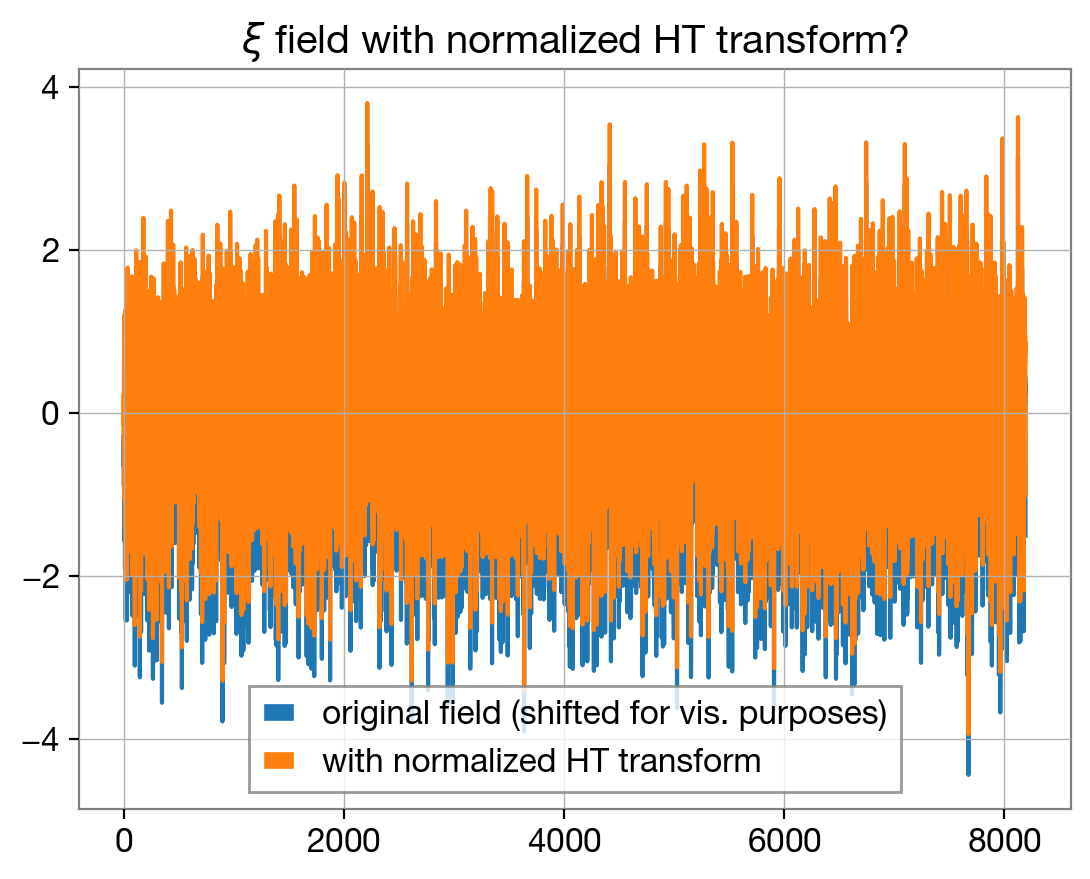

In [73]:
HT = ht3[0]
real_space = HT.domain
harmonic_space = HT.target
xi_field = ift.Field(HT.domain, np.random.normal(loc=0, scale=1, size=real_space.shape[0]))

print("volume of harmonic space ", harmonic_space[0].scalar_dvol)
print("volume of real space ", real_space[0].scalar_dvol, " vs distances: ", real_space[0].distances)

plt.title(r"Original $\xi$ field")
plt.plot(xi_field.val)
plt.show()

should_be_xi_field = HT.adjoint(HT(xi_field))
plt.title(r"$\xi$ field applied with non-normalized HT transform")
plt.plot(should_be_xi_field.val)
plt.show()

svol = real_space[0].scalar_dvol
N = real_space.shape[0]

plt.title(r"$\xi$ field with normalized HT transform?")
print("step 1 ")
step1 = HT(xi_field)
print("step 2 ")
step2 = HT.adjoint(step1)/ svol**2 / N
now_is_xi_field = step2
plt.plot(xi_field.val-0.5, label="original field (shifted for vis. purposes)")
plt.plot(now_is_xi_field.val, label="with normalized HT transform")
plt.legend()
plt.show()


## With this, I present final noise samples

And still it has not got the right scale. But the HT is now properly normalized. Zeromode really doesnt look like its the problem.

In [91]:

L = svol*N
pure_pow_spec = np.mean(final_ps, axis=0)/svol
final_mean_ps_czm = pure_pow_spec/L  # /(svol**2 * N) => \tilde{xi}^2 / Length

final_mean_ps_czm_2 = pure_pow_spec/np.sqrt(L)  # Why? Because if you draw from N\xi instead of N_sqrt and your power spectrum is per L, at the end you will get a scaling
# with per L^2, but you want it to be per L ...


# why this normalization? Because power analyze takes a harmonic Field, HT(field) ~ sqrt(N) * s_vol! and the computes the square: <s^dagger s> ~ N * s_vol**2 !

custom_zero_mode = 1e3
# final_mean_ps_czm[0] = custom_zero_mode

print("Zero mode: ", final_mean_ps_czm[0])

print("POWER SPECTRUM HAS UNITS OF COURSE , ACCOUNT FOR SVOL ")

final_mean_ps_field_czm = ift.Field(final_ps_fields[0].domain, val=final_mean_ps_czm_2)  # custom zero mode
final_mean_ps_field_sqrt_czm = ift.Field(final_ps_fields[0].domain, val=np.sqrt(final_mean_ps_czm))

myN_fourier = ift.create_power_operator(domain=ht3[0].target, power_spectrum=final_mean_ps_field_czm)
myN_fourier_sqrt = ift.create_power_operator(domain=ht3[0].target, power_spectrum=final_mean_ps_field_sqrt_czm)


tziz = ift.DiagonalOperator(ift.Field(HT.target, val=np.ones(N)))

norm = N*svol**2

N_real = ift.SandwichOperator.make(bun=ht3[0], cheese=myN_fourier, sampling_dtype=np.float64) * (1/norm) #  this norm is to normalize the HT transform.
N_real_sqrt = ift.SandwichOperator.make(bun=ht3[0], cheese=myN_fourier_sqrt, sampling_dtype=np.float64) * (1/norm)
# N_real_sqrt = ift.SandwichOperator.make(bun=ht3[0], cheese=tziz, sampling_dtype=np.float64)  # Proof of concept that the HT is properly normalized

collect_variance=[]

for _ in range(10_000):

    random_xi = np.random.normal(size=N, scale=1, loc=0)
    sample = N_real(ift.Field(N_real_sqrt.domain, val=random_xi))  # same same

    # sample = N_real_sqrt(ift.Field.from_random(domain=N_real_sqrt.domain, random_type="normal"))

    collect_variance.append(sample.val)

    # plt.plot(sample.val)

Zero mode:  67.10349530210917
POWER SPECTRUM HAS UNITS OF COURSE , ACCOUNT FOR SVOL 


In [92]:
pixelwise_standard_deviation = np.std(collect_variance, axis=0)
print("is the mean_pixelwise_standard_deviation, ", np.mean(pixelwise_standard_deviation), " , equal to the sqrt of a^2? ", np.sqrt(4.6594769081), " YEP! (if you take 10_000 samples it becomes very close).")


is the mean_pixelwise_standard_deviation,  170.53868855175546  , equal to the sqrt of a^2?  2.158582152270328  YEP! (if you take 10_000 samples it becomes very close).


In [76]:
pickle_me_this("not_welched_average_power_spectrum_estimate_sqrt", N_real_sqrt)
pickle_me_this("not_welched_average_power_spectrum_estimate", N_real)